# Phyloseq analysis
- going to use CCD's 16S data and PS object to compare to my seqs
- CCD workflow here: https://github.com/cdesouza02/BEL_16S_ITS2/blob/main/BEL_16S_outputs/ps_processing.ipynb

In [1]:
getwd()

[1] "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld"

In [2]:
library(tidyverse)
library(vegan)
library(dplyr)
library(phyloseq)
#library(VennDiagram)
library("DESeq2")
library(RColorBrewer)
library(ggplot2)
library(cowplot)
library(lubridate)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   4.0.3     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Loading required package: permute

Loading required package: lattice

This is vegan 2.6-5

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:lubridate’:

    intersect, setdiff, union


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:s

## Upload and Clean Data

In [62]:
# upload CCD's phyloseq object
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_16S_outputs/ps_16S.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 268938 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 268938 taxa by 6 taxonomic ranks ]

In [63]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps) >= 10000, ps)

In [64]:
# which samples were removed?
setdiff(sample_names(ps), sample_names(ps_high))

[1] "122022_BEL_CBC_T3_142_MCAV" "042024_BEL_CBC_T3_960_OFAV"
[3] "Negative"                   "012024_BEL_CBC_T1_561_OANN"
[5] "Negative.4"

In [65]:
#isolate just bacteria
ps_bac=subset_taxa(ps_high, Kingdom=="Bacteria")
#remove chloroplast order
ps_nochlo=subset_taxa(ps_bac, Order!="Chloroplast")
#remove mitochondria family
ps_nomit=subset_taxa(ps_nochlo, Family!="Mitochondria")

#removing any taxa that don't show up in any samples to speed up the process
ps_prune <- prune_taxa(taxa_sums(ps_nomit) > 0, ps_nomit)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 46536 taxa and 474 samples ]
sample_data() Sample Data:       [ 474 samples by 10 sample variables ]
tax_table()   Taxonomy Table:    [ 46536 taxa by 6 taxonomic ranks ]

In [66]:
# subset sctld samples
ps_sctld<-subset_samples(ps_prune, Month_year %in% c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022"))

In [67]:
meta_df<-data.frame(sample_data(ps_sctld))

# add resistant vs susceptible
meta_df<-meta_df %>%
    mutate(RS = case_when(
        Species=="PAST" ~ "Resistant",
        Species=="MMEA" ~ "Susceptible",
        Month_year == "Dec 2022" & Condition=="Healthy" ~ "Resistant",
        Month_year == "May 2022" & Condition=="Diseased" ~ "Susceptible",
        Month_year == "Dec 2022" & Condition=="Diseased" ~ "Susceptible",
        Month_year == "May 2022" & Condition=="Dead" ~ "Susceptible",
        Month_year == "Dec 2022" & Condition=="Dead" ~ "Susceptible"))
# add Year
meta_df<-meta_df %>%
    mutate(year = format(my(Month_year), "%Y"))

In [68]:
meta_df %>%
    filter(Health_status == "Bleached_Tissue")
# i am changing this to healthy for now 
meta_df %>%
    filter(colony == '2_73')
# was healthy the whole time so just calling it all healthy

,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species,RS,year
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>,<chr>,<chr>
122022_BEL_CBC_T2_90_SSID,Bleached_Tissue,2_73,1_9_2026,CLB,SSID,Dec 2022,3,SR30N,2022-12-04,122022_BEL_CBC_T2_90_SSID,NA,2022


,Health_status,colony,Date_16S,Condition,Species,Month_year,Seq_run,Transect,DateFormatted,Tubelabel_species,RS,year
,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,<int>,<chr>,<date>,<chr>,<chr>,<chr>
052022_BEL_CBC_T2_1_SSID,Healthy,2_73,3_4_2025,Healthy,SSID,May 2022,1,SR30N,2022-05-22,052022_BEL_CBC_T2_1_SSID,NA,2022
062019_BEL_CBC_T2_17_SSID,Healthy,2_73,8_8_2025,Healthy,SSID,Jun 2019,2,SR30N,2019-06-25,062019_BEL_CBC_T2_17_SSID,NA,2019
122022_BEL_CBC_T2_90_SSID,Bleached_Tissue,2_73,1_9_2026,CLB,SSID,Dec 2022,3,SR30N,2022-12-04,122022_BEL_CBC_T2_90_SSID,NA,2022


In [69]:
meta_df<-meta_df %>%
    mutate(Condition = if_else(Condition == "CLB","Healthy",Condition)) %>%
    mutate(Health_status = if_else(Health_status == "Bleached_Tissue","Healthy",Health_status))

In [70]:
new_sampledf<-sample_data(meta_df)
sample_data(ps_sctld) <- new_sampledf

In [71]:
# reorder dates
sample_data(ps_sctld)$Month_year<-factor(sample_data(ps_sctld)$Month_year,levels = 
                                        c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022"))

#### Filtering Outliers

In [34]:
# sctld_raw.ord <- ordinate(sctld_raw, "NMDS", "bray", trymax=1000)

In [36]:
# remove MCAV mistake 
# mistake<- c("052022_BEL_CBC_T1_54_MCAV")
# sctld_raw <- prune_samples(!(sample_names(sctld_raw) %in% mistake), sctld_raw)
# # remove outliers for now??
# outlier<- c("122022_BEL_CBC_T2_93_OFAV","102019_BEL_CBC_T1_29_PSTR")
# sctld_raw2 <- prune_samples(!(sample_names(sctld_raw) %in% outlier), sctld_raw)

In [37]:
# and remove human skin microbes - cutibacterium acnes
# keep <- as.vector(tax_table(sctld_raw2)[, "family"] != "Cutibacterium")
# sctld_raw2 <- prune_taxa(keep, sctld_raw2)
# sctld_raw <- prune_taxa(keep, sctld_raw)

## Diversity

In [39]:
library(paletteer)
library(scales)


Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor




In [40]:
custom_list<-c("#7290ba",
"#d77a51",
"#8748c6",
"#759b50",
"#cc5893",
"#b05e3f")

In [43]:
# names(coral_colors) <- unique(metadata$Species)
names(custom_list) <- unique(meta_df$Species)

In [44]:
# coral_colors
custom_list

SSID      PAST      MCAV      OFAV      PSTR      OANN 
"#7290ba" "#d77a51" "#8748c6" "#759b50" "#cc5893" "#b05e3f"

In [73]:
ps_sctld.ord <- ordinate(ps_sctld, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.2082069 
Run 1 stress 0.222115 
Run 2 stress 0.2187485 
Run 3 stress 0.2242641 
Run 4 stress 0.2232393 
Run 5 stress 0.2148782 
Run 6 stress 0.2170708 
Run 7 stress 0.2183559 
Run 8 stress 0.2155929 
Run 9 stress 0.2150702 
Run 10 stress 0.2199406 
Run 11 stress 0.2223648 
Run 12 stress 0.2218454 
Run 13 stress 0.2262209 
Run 14 stress 0.2197237 
Run 15 stress 0.2217113 
Run 16 stress 0.2176071 
Run 17 stress 0.224579 
Run 18 stress 0.2203963 
Run 19 stress 0.2224563 
Run 20 stress 0.2172584 
Run 21 stress 0.2234644 
Run 22 stress 0.2240245 
Run 23 stress 0.2134778 
Run 24 stress 0.2220635 
Run 25 stress 0.2186097 
Run 26 stress 0.2189343 
Run 27 stress 0.21852 
Run 28 stress 0.2160406 
Run 29 stress 0.2165139 
Run 30 stress 0.2175737 
Run 31 stress 0.2231381 
Run 32 stress 0.2260324 
Run 33 stress 0.2252914 
Run 34 stress 0.2111856 
Run 35 stress 0.2200085 
Run 36 stress 0.225416 
Run 37 stress 0.2102752 
Run 3

In [46]:
options(repr.plot.width=15, repr.plot.height=10)

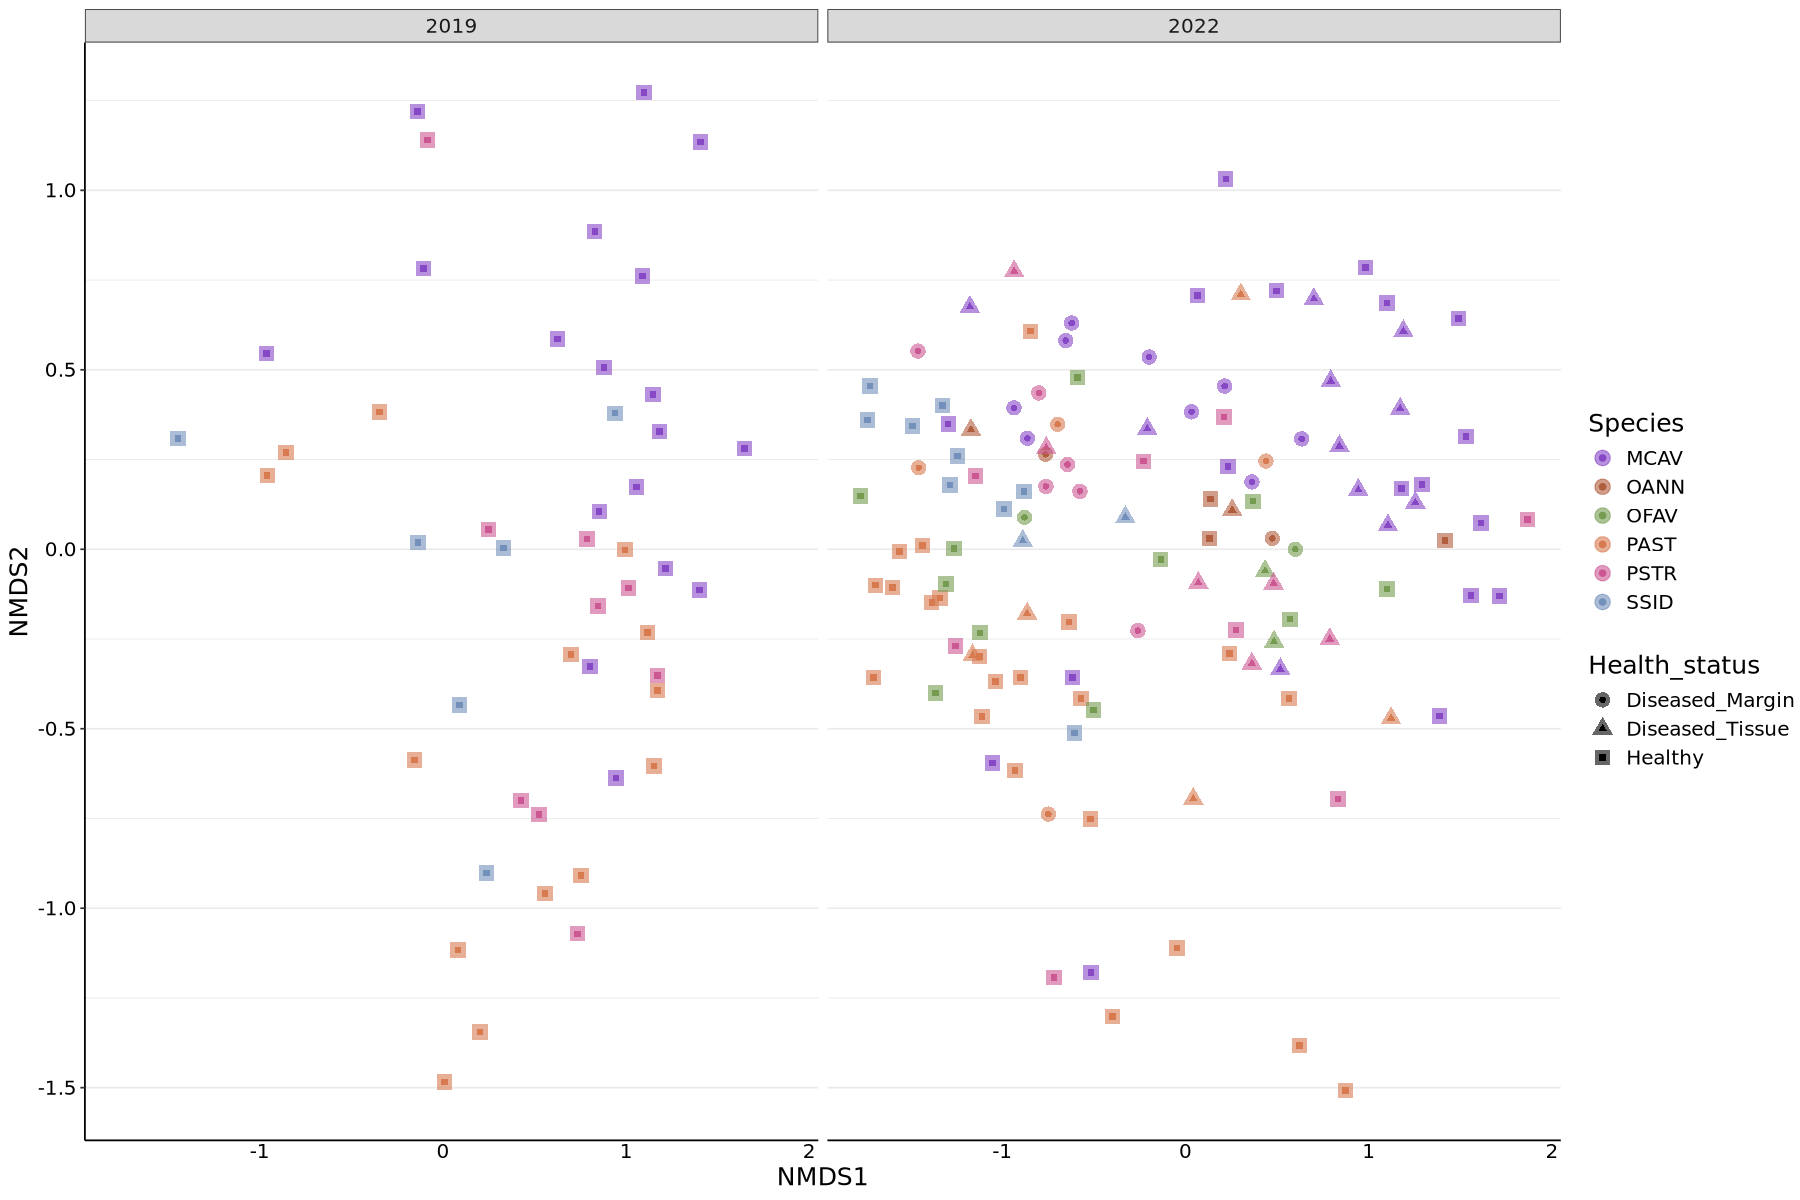

In [74]:
# facet by year
sctld_raw_plot <- plot_ordination(ps_sctld, ps_sctld.ord, type="samples", color="Species", shape="Health_status")+
geom_point(size=4, alpha = 0.6) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
sctld_raw_plot

# all samples - separated by 2019 and 2022

In [46]:
# 2019 only - RS
RS_ps <- subset_samples(sctld_raw2, year == "2019")
RS.ord <- ordinate(RS_ps, "NMDS", "bray", trymax=1000)

Square root transformation
Wisconsin double standardization
Run 0 stress 0.1105056 
Run 1 stress 0.1937167 
Run 2 stress 0.1632686 
Run 3 stress 0.1105585 
... Procrustes: rmse 0.001846531  max resid 0.01393394 
Run 4 stress 0.1875601 
Run 5 stress 0.1105056 
... New best solution
... Procrustes: rmse 9.428519e-06  max resid 5.75331e-05 
... Similar to previous best
Run 6 stress 0.1105056 
... Procrustes: rmse 1.546587e-05  max resid 6.901492e-05 
... Similar to previous best
Run 7 stress 0.1105585 
... Procrustes: rmse 0.001846483  max resid 0.01393544 
Run 8 stress 0.1105056 
... Procrustes: rmse 1.018446e-05  max resid 4.780708e-05 
... Similar to previous best
Run 9 stress 0.2103806 
Run 10 stress 0.1105056 
... Procrustes: rmse 6.882852e-06  max resid 4.482559e-05 
... Similar to previous best
Run 11 stress 0.1989048 
Run 12 stress 0.1105056 
... Procrustes: rmse 1.059095e-05  max resid 5.171723e-05 
... Similar to previous best
Run 13 stress 0.1105585 
... Procrustes: rmse 0.0018

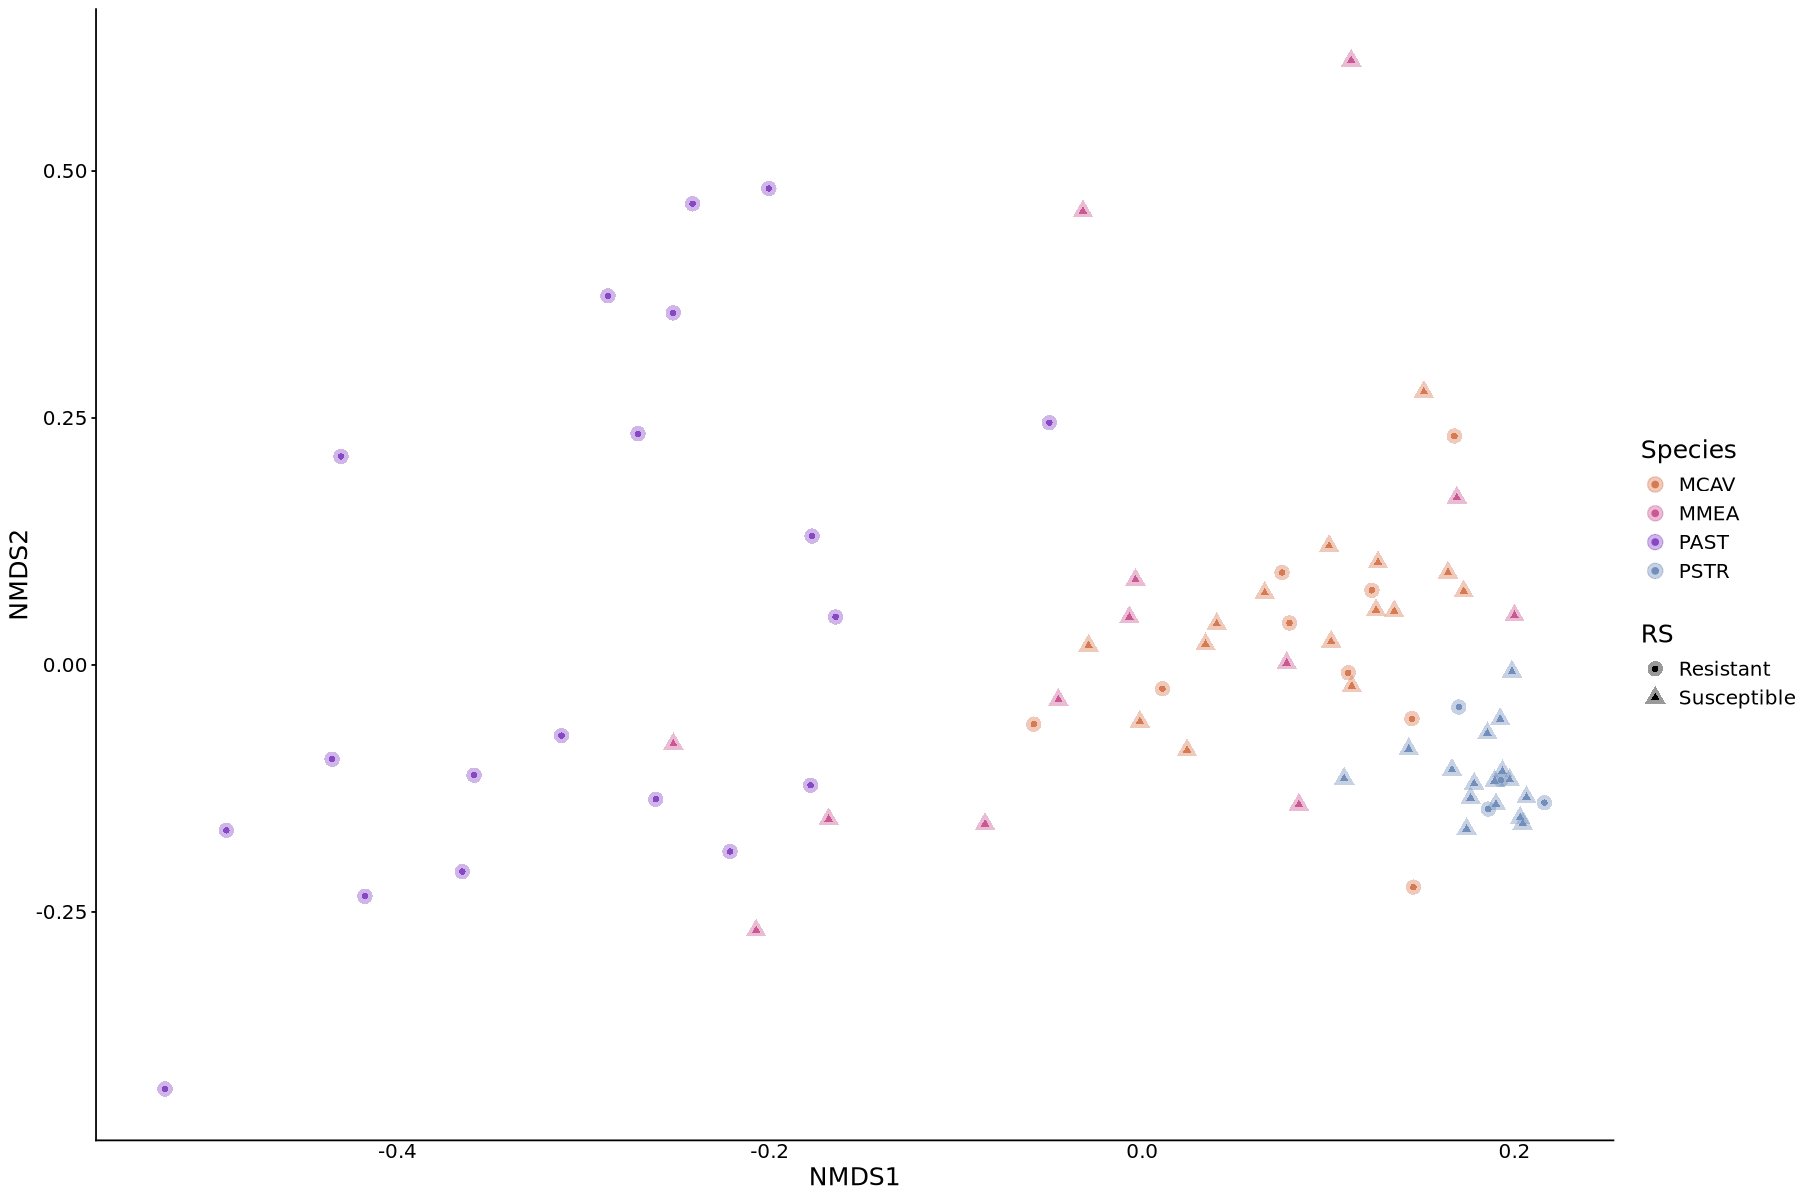

In [47]:
nmds_2019<-plot_ordination(RS_ps, RS.ord, type="samples", color="Species", shape="RS")+
geom_point(size=4, alpha = 0.4) + 
# scale_color_brewer(palette = "Dark2")+
scale_color_manual(values = custom_list)+
# facet_wrap(~year)+
# geom_label(aes(label = sample_data(sctld_raw2)$sampleid), vjust = -1, color = "black") +
theme_classic()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
nmds_2019


# 2019 only 

In [48]:
# ggsave(filename = "/project/pi_sarah_gignouxwolfsohn_uml_edu/brooke/CBC_metagenomics/all_sctld/plots/RS_2019_nmds.png", plot = nmds_2019, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

In [49]:
RS.ord
# Stress: 0.108


Call:
metaMDS(comm = veganifyOTU(physeq), distance = distance, trymax = 1000) 

global Multidimensional Scaling using monoMDS

Data:     wisconsin(sqrt(veganifyOTU(physeq))) 
Distance: bray 

Dimensions: 2 
Stress:     0.1105056 
Stress type 1, weak ties
Best solution was repeated 9 times in 20 tries
The best solution was from try 5 (random start)
Scaling: centring, PC rotation, halfchange scaling 
Species: expanded scores based on ‘wisconsin(sqrt(veganifyOTU(physeq)))’ 


Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


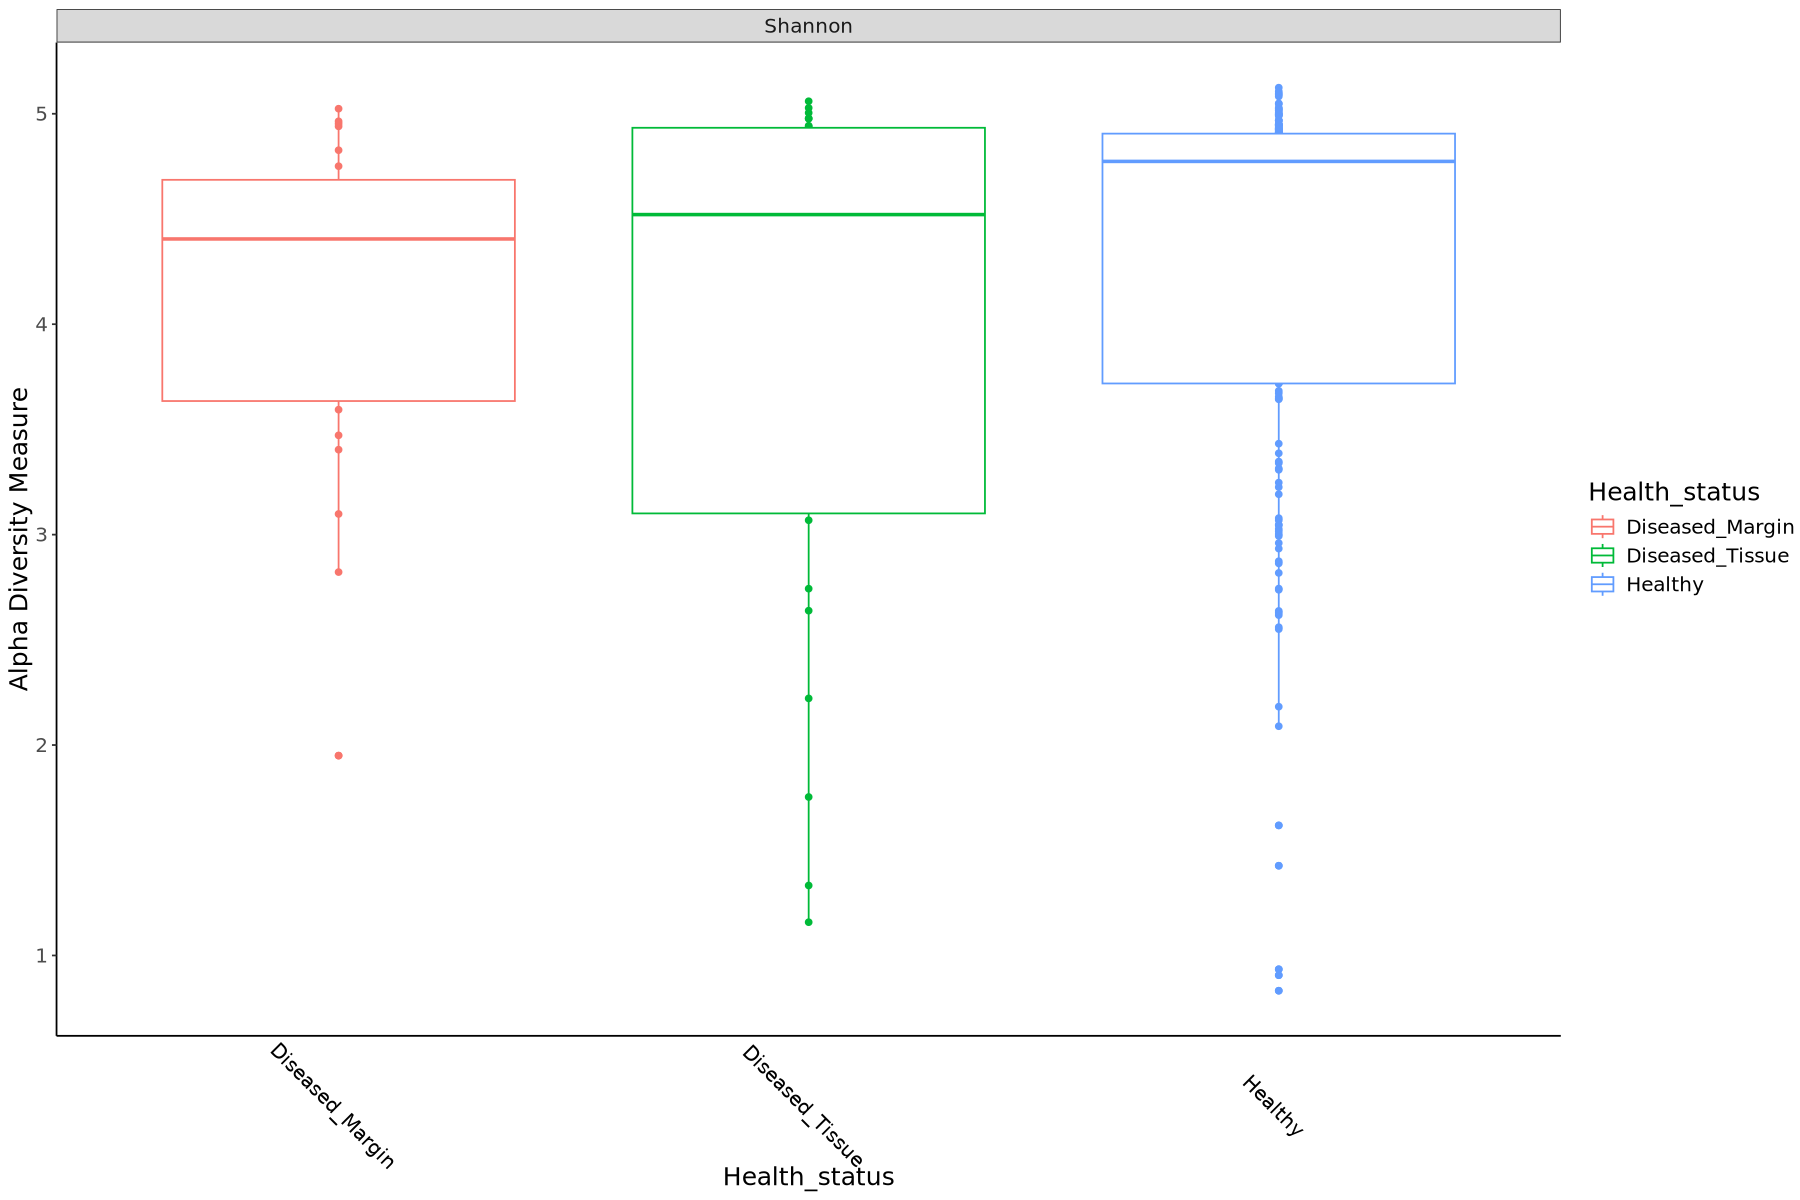

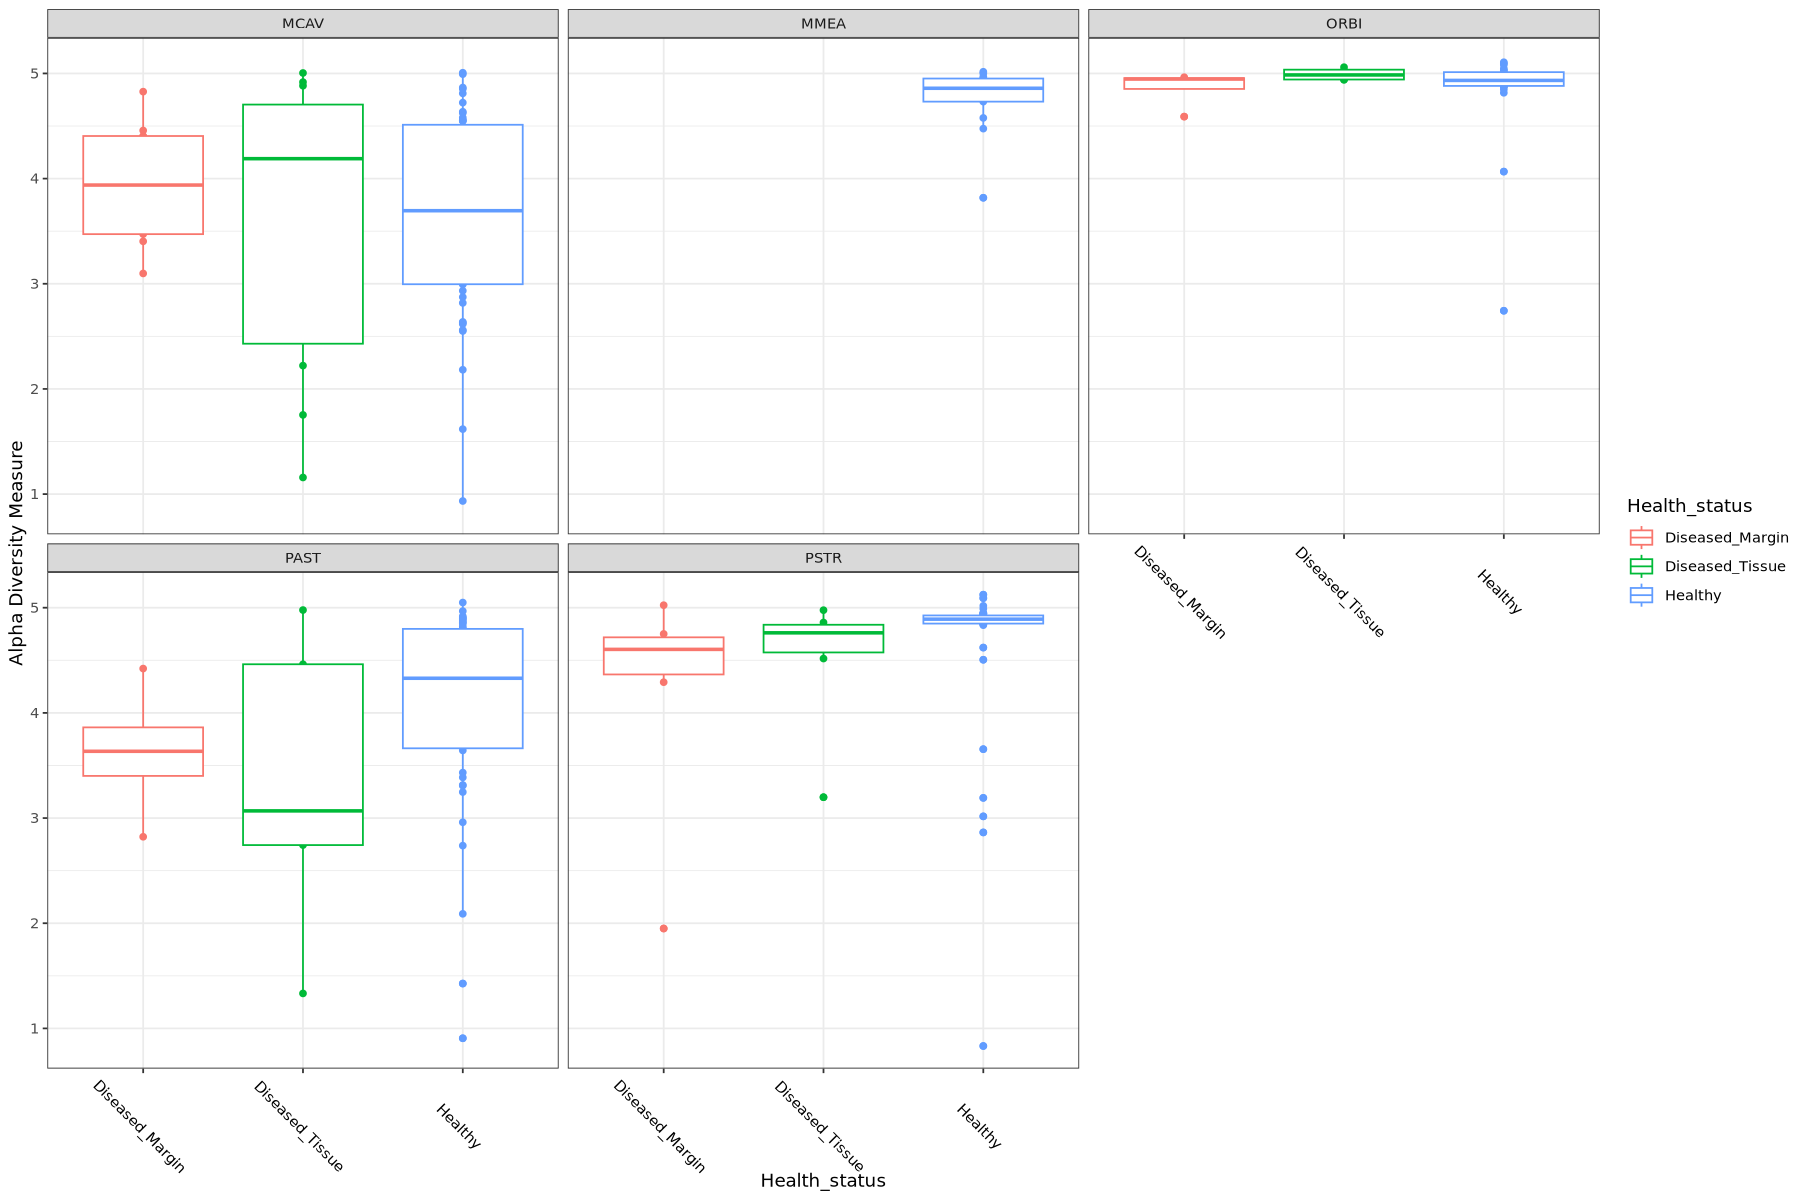

In [50]:
rich_status <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + 
    geom_boxplot() +
    # facet_wrap(~Species)+
    theme_bw()+
     theme(legend.position = "right",
        panel.border = element_blank(),
        panel.grid.major.x = element_blank(),
        panel.grid.minor.x = element_blank(),
        panel.grid.major.y = element_blank(),
        panel.grid.minor.y = element_blank(),
        axis.ticks.x = element_blank(),
        axis.line = element_line(color = "black"),
        axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5),
        text = element_text(size = 15))
rich_status

plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + 
geom_boxplot() +
facet_wrap(~Species)+
theme_bw()+
theme(axis.text.x = element_text(color = "black", angle = -45, hjust = 0.5))

# all samples - spp x disease status

In [51]:
# ggsave(filename = "shannon_richness_sample_type.png", plot = rich_status, 
#       width = 10,
#       height = 10,
#       units = "in",
#       dpi = 300)

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


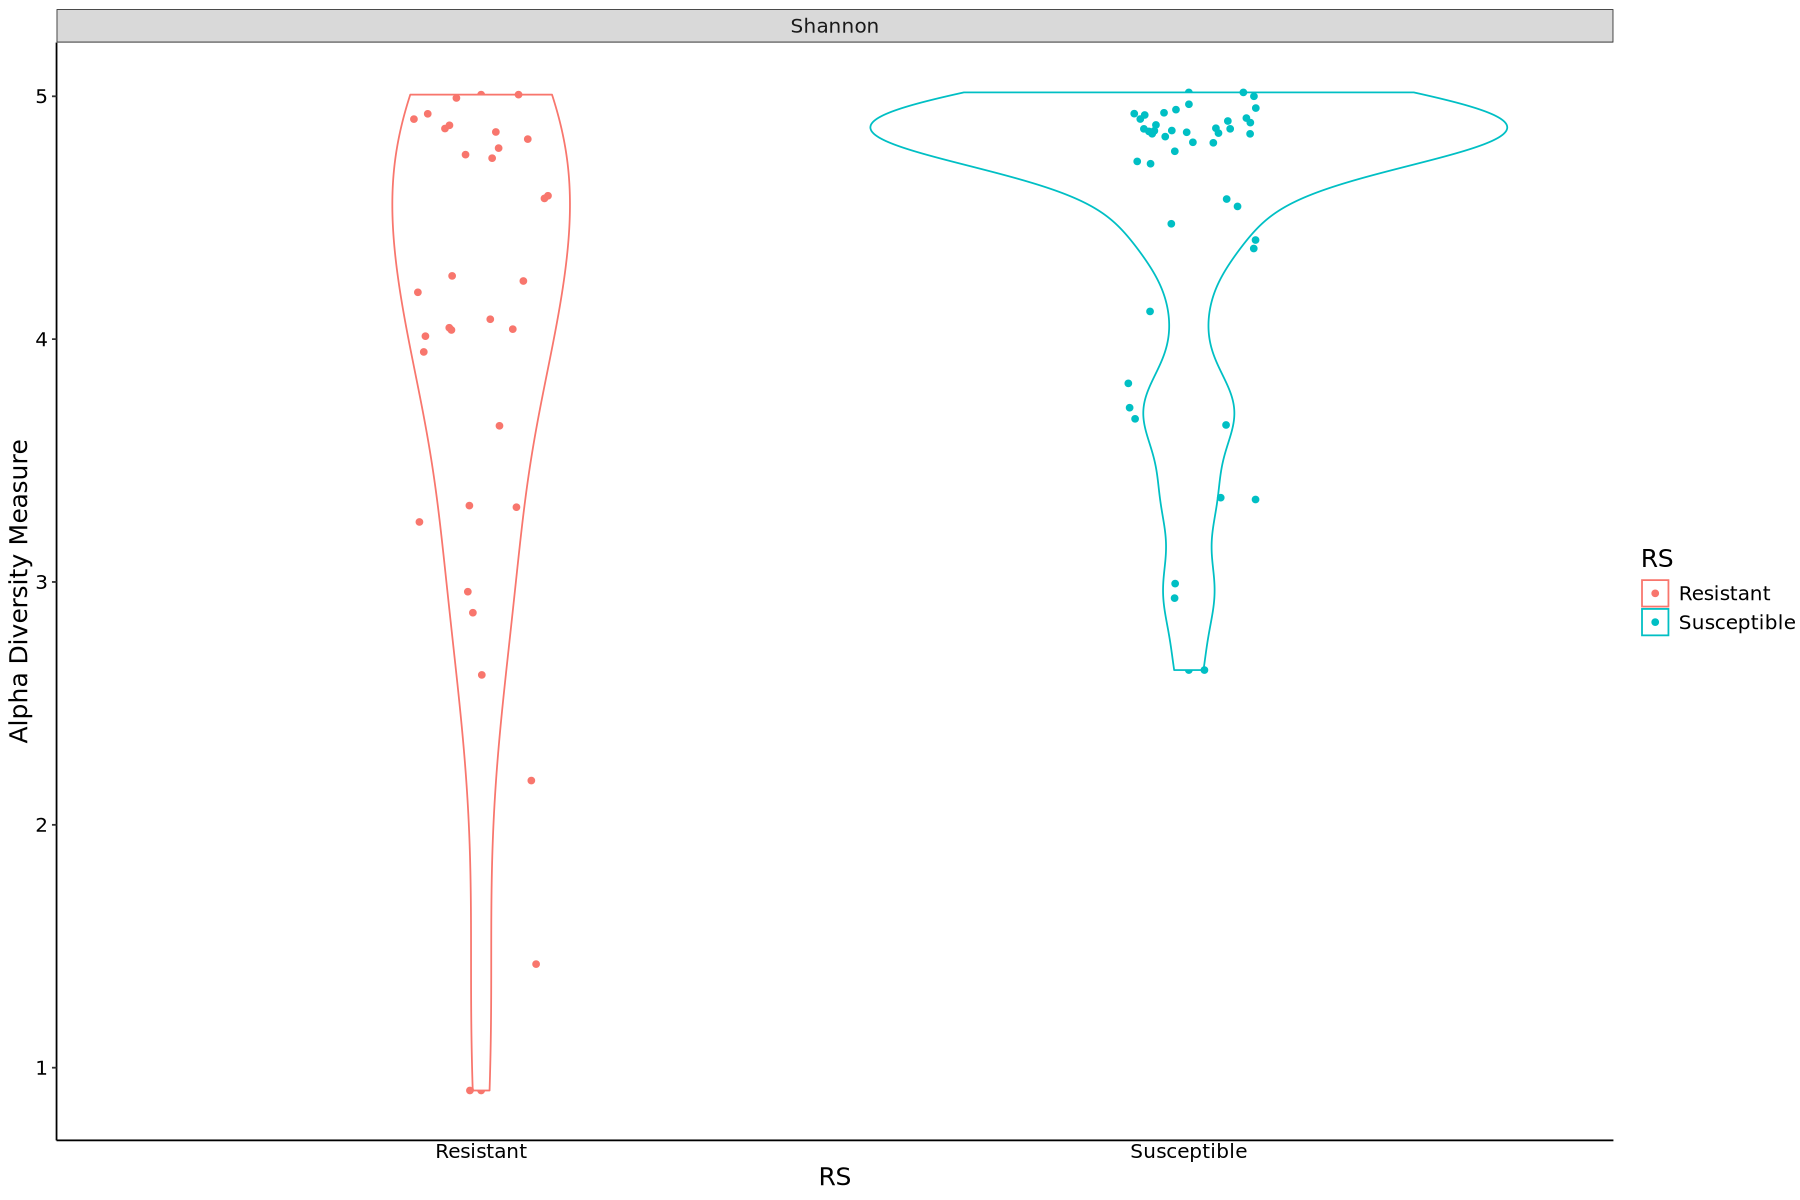

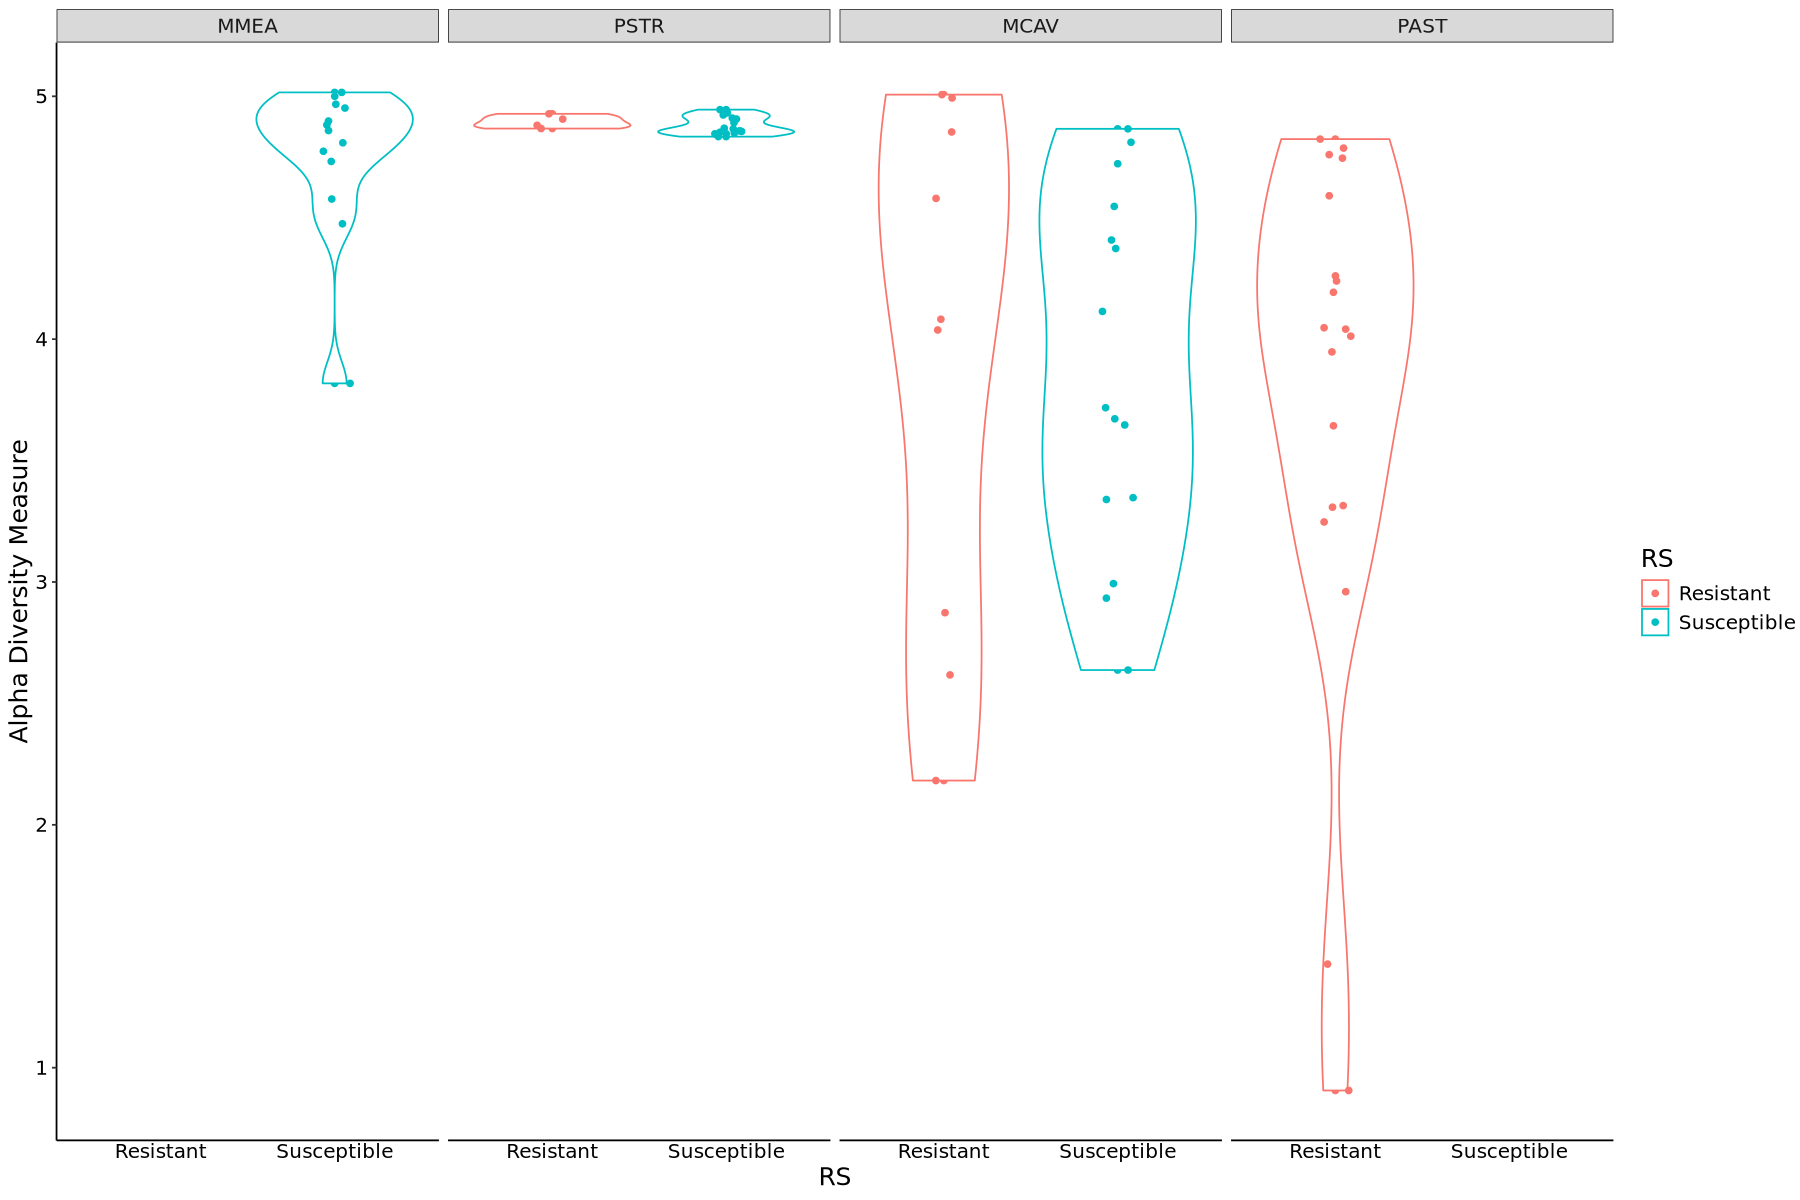

In [52]:
# order of species susceptibility 
# reorder colonies most -> least sus
spp_order<-c("MMEA",'PSTR','MCAV','PAST')
df_meta<-data.frame(sample_data(RS_ps))
sample_data(RS_ps)$Species <-
  factor(sample_data(RS_ps)$Species, levels = spp_order)

rich_status1 <- plot_richness(RS_ps, x="RS", color="RS", measures=c("Shannon")) + geom_violin() +
geom_jitter(height = 0, width = 0.1)+
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    panel.grid.major.y = element_blank(),
    panel.grid.minor.y = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))
rich_status1

rich_status1+
    facet_grid(~Species)

# R vs S - 2019 only 

In [53]:
# most susceptible species are more diverse

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


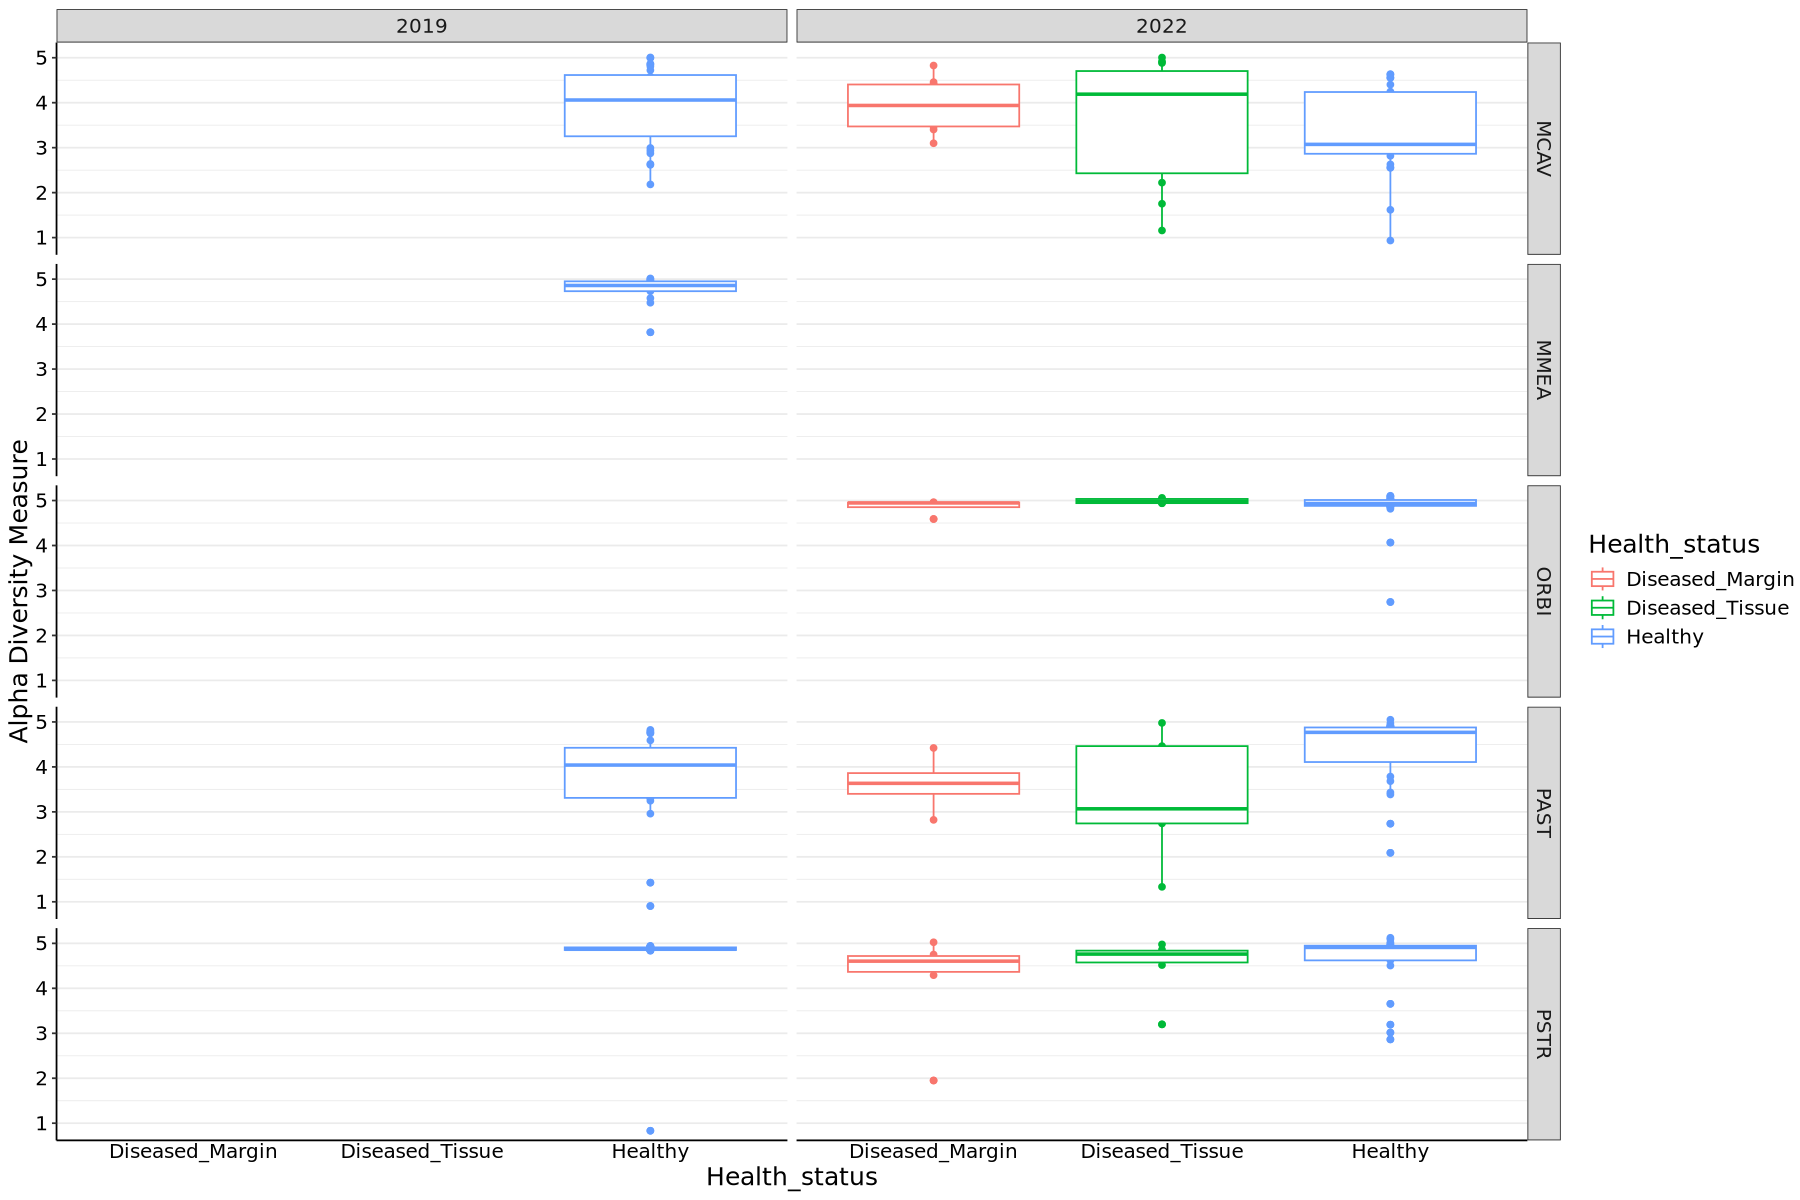

In [54]:
rich_species <- plot_richness(sctld_raw, x="Health_status", color="Health_status", measures=c("Shannon")) + geom_boxplot() +
theme_bw()+
 theme(legend.position = "right",
    panel.border = element_blank(),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text = element_text(color = "black"),
    text = element_text(size = 15))

rich_species+
    facet_grid(Species~year)

# all samples - year x spp x health status

In [55]:
# Calculate the Bray-Curtis distance matrix
bray_dist <- phyloseq::distance(sctld_raw2, method = "bray")
metadata2 <- as(phyloseq::sample_data(sctld_raw2), "data.frame")

In [56]:
permanova <- vegan::adonis2(bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
print(permanova)
# all samples

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * year, data = metadata2, permutations = 999)
                 Df SumOfSqs      R2       F Pr(>F)    
RS                1    1.352 0.03024  8.3573  0.001 ***
Species           4    8.227 0.18401 12.7124  0.001 ***
year              1    1.477 0.03303  9.1290  0.001 ***
RS:Species        2    0.224 0.00501  0.6917  0.792    
RS:year           1    0.116 0.00260  0.7187  0.626    
Species:year      2    0.678 0.01517  2.0964  0.020 *  
RS:Species:year   1    0.116 0.00258  0.7141  0.615    
Residual        201   32.519 0.72735                   
Total           213   44.709 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [57]:
permanova2 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
print(permanova2)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year, data = metadata2, permutations = 999)
                       Df SumOfSqs      R2       F Pr(>F)    
Health_status           2    0.683 0.01528  2.1442  0.018 *  
RS                      1    1.747 0.03909 10.9679  0.001 ***
Species                 4    8.093 0.18103 12.6998  0.001 ***
year                    1    1.091 0.02441  6.8488  0.001 ***
Health_status:RS        2    0.294 0.00658  0.9234  0.479    
Health_status:Species   4    0.590 0.01319  0.9255  0.538    
RS:Species              2    0.239 0.00536  0.7516  0.708    
RS:year                 1    0.172 0.00385  1.0793  0.337    
Species:year            2    0.641 0.01434  2.0114  0.028 *  
RS:Species:year         1    0.408 0.00912  2.5588  0.027 *  
Residual              193   30.749 0.68777                   
Total   

In [58]:
permanova3 <- vegan::adonis2(bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
print(permanova3)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Species * year * Transect, data = metadata2, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2    0.683 0.01528  2.1559  0.022 *  
RS                               1    1.747 0.03909 11.0279  0.001 ***
Species                          4    8.093 0.18103 12.7692  0.001 ***
year                             1    1.091 0.02441  6.8862  0.001 ***
Transect                         3    1.042 0.02330  2.1918  0.005 ** 
Health_status:RS                 2    0.305 0.00683  0.9636  0.433    
Health_status:Species            4    0.553 0.01237  0.8724  0.611    
RS:Species                       2    0.228 0.00510  0.7194  0.715    
RS:year                          1    0.122 0.00273  0.7715  0.595    
Species:year                   

In [59]:
# location is more important than health status?

In [60]:
# look at 2022 subset - how much does health status vary
dis_ps<- subset_samples(sctld_raw2, year == '2022')
bray_dist <- phyloseq::distance(dis_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(dis_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * Species * Transect, data = dis_meta, permutations = 999)
                                Df SumOfSqs      R2       F Pr(>F)    
Health_status                    2   0.6193 0.02030  1.7709  0.051 .  
Species                          3   6.0124 0.19707 11.4625  0.001 ***
Transect                         3   1.1970 0.03923  2.2820  0.004 ** 
Health_status:Species            6   1.0060 0.03298  0.9590  0.512    
Health_status:Transect           6   0.9868 0.03234  0.9406  0.563    
Species:Transect                 8   1.9310 0.06330  1.3806  0.038 *  
Health_status:Species:Transect  10   1.4465 0.04741  0.8273  0.819    
Residual                        99  17.3094 0.56736                   
Total                          137  30.5085 1.00000                   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 

In [61]:
# species is more important than health status - same as from prelim results

In [62]:
#mcav only
# look at 2022 subset - how much does health status vary
mcav_ps<- subset_samples(sctld_raw2, Species == "MCAV" & year == '2022')
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = mcav_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2   0.5824 0.06586 1.4835  0.118  
RS                      1   0.4471 0.05055 2.2774  0.046 *
Transect                3   0.7972 0.09015 1.3537  0.149  
Health_status:Transect  4   0.9312 0.10530 1.1860  0.253  
Residual               31   6.0854 0.68813                
Total                  41   8.8434 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [63]:
orbi_ps<- subset_samples(sctld_raw2, Species == "ORBI")
bray_dist <- phyloseq::distance(orbi_ps, method = "bray")
orbi_meta <- as(phyloseq::sample_data(orbi_ps), "data.frame")
orbi_perma <- vegan::adonis2(bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
print(orbi_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ Health_status * RS * Transect, data = orbi_meta, permutations = 999)
                       Df SumOfSqs      R2      F Pr(>F)  
Health_status           2  0.24200 0.07737 1.1694  0.295  
RS                      1  0.08077 0.02582 0.7806  0.469  
Transect                3  0.59436 0.19002 1.9148  0.053 .
Health_status:Transect  4  0.25989 0.08309 0.6279  0.779  
RS:Transect             1  0.08850 0.02829 0.8553  0.407  
Residual               18  1.86245 0.59542                
Total                  29  3.12798 1.00000                
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [64]:
# maybe we do need to separate out orbi species...

In [65]:
# 2019 only 

In [66]:
bray_dist <- phyloseq::distance(RS_ps, method = "bray")
dis_meta <- as(phyloseq::sample_data(RS_ps), "data.frame")
dis_perma <- vegan::adonis2(bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
print(dis_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Species * Transect, data = dis_meta, permutations = 999)
                    Df SumOfSqs      R2      F Pr(>F)    
RS                   1   0.7277 0.05726 5.7360  0.001 ***
Species              3   3.2591 0.25644 8.5631  0.001 ***
Transect             2   0.1900 0.01495 0.7489  0.715    
RS:Species           1   0.0594 0.00468 0.4685  0.834    
RS:Transect          2   0.1720 0.01353 0.6778  0.768    
Species:Transect     6   0.7174 0.05645 0.9425  0.591    
RS:Species:Transect  1   0.0985 0.00775 0.7761  0.565    
Residual            59   7.4851 0.58895                  
Total               75  12.7092 1.00000                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


In [67]:
# within species, how much does RS explain difference

In [68]:
mcav_ps<- subset_samples(RS_ps, Species == "MCAV")
bray_dist <- phyloseq::distance(mcav_ps, method = "bray")
mcav_meta <- as(phyloseq::sample_data(mcav_ps), "data.frame")
mcav_perma <- vegan::adonis2(bray_dist ~  RS * Transect, data = mcav_meta, permutations = 999)
print(mcav_perma)

Permutation test for adonis under reduced model
Terms added sequentially (first to last)
Permutation: free
Number of permutations: 999

vegan::adonis2(formula = bray_dist ~ RS * Transect, data = mcav_meta, permutations = 999)
            Df SumOfSqs      R2      F Pr(>F)
RS           1  0.12215 0.04344 1.0389  0.357
Transect     2  0.22433 0.07978 0.9540  0.456
RS:Transect  2  0.34928 0.12421 1.4854  0.185
Residual    18  2.11632 0.75258              
Total       23  2.81209 1.00000              


### Taxa Bar Plots

In [69]:
# subset taxa and normalzie out of 100 - family level
sctld_raw_10 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:10]), sctld_raw)
sctld_raw_10_norm <- transform_sample_counts(sctld_raw_10, function(x) x / sum(x))
     
sctld_raw_30 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:30]), sctld_raw)
sctld_raw_30_norm <- transform_sample_counts(sctld_raw_30, function(x) x / sum(x))

sctld_raw_100 = prune_taxa(names(sort(taxa_sums(sctld_raw),TRUE)[1:100]), sctld_raw)
sctld_raw_100_norm <- transform_sample_counts(sctld_raw_100, function(x) x / sum(x))

In [70]:
g_colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors <- c( "#b73962", "#e994a6", "#be6b7c", "#944557", "#ea2c68", "#e65e74", "#b33841", "#dd3640", "#dd7267", "#de2b1c", "#a46452", "#c04926", "#9b4426", "#ec5825", "#e6a485", "#c2744d", "#e77d46", "#a3601b", "#845526", "#e28c23", "#d79651", "#a4844d", "#aa8523", "#d2b067", "#d3b135", "#726520", "#81871c", "#b4b75d", "#a5c030", "#829055", "#7a9a3c", "#566935", "#a7bc85", "#4e7023", "#64a422", "#89c45e", "#57ce3c", "#2f7f2d", "#3aa83a", "#5d9b58", "#7ec485", "#47cc7a", "#2c6f47", "#32a064", "#2f8970", "#53ae93", "#3fc9a6", "#64d3c2", "#41bbc8", "#3da5c4", "#4b8ebf", "#72b3e8", "#3270a7", "#2e5b88", "#4795e0", "#5790ed", "#2b6abe", "#2580fe", "#415691", "#6274b2", "#4b80ec", "#95a0e6", "#4362c2", "#7c89e9", "#5166ec", "#3c4dbb", "#5756a0", "#695dbf", "#8476c6", "#675cd3", "#4e45a3", "#4d4adc", "#8f76e8", "#72619d", "#9b87be", "#6b4fa0", "#7048b1", "#7532e8", "#b58aea", "#9655e8", "#cda8e4", "#7c608c", "#8a52ae", "#634872", "#bc6aea", "#b436e6", "#9235b6", "#7e4990", "#b175b9", "#9b43a1", "#dd7adc", "#e635ea", "#d043cc", "#915882", "#d78bbb", "#ba3291", "#ea3db5", "#a24680", "#e670af", "#e3418b" )
colors_30 <- c( "#e28d99", "#ee7473", "#f2703f", "#dc966f", "#de9435", "#d6b36e", "#dbbf37", "#abb160", "#bdd630", "#bade6b", "#7ead3b", "#bcdc9c", "#66d34d", "#65d77c", "#66af7a", "#5ae5ac", "#77e3c6", "#47b1a5", "#5ae4e5", "#41aec3", "#5eceed", "#3ba1d2", "#78b0e7", "#7796ed", "#b5a5dd", "#aa7df5", "#c891e3", "#e66dd5", "#de95c9", "#f2699f" )

In [71]:
# map list of 100 genera to same color
top100_names <- as.character(tax_table(sctld_raw_100)[, "family"])
names(g_colors) <- top100_names
head(g_colors)

Nitrobacteraceae Propionibacteriaceae    Streptomycetaceae 
           "#b73962"            "#e994a6"            "#be6b7c" 
      Reyranellaceae     Roseobacteraceae        Paracoccaceae 
           "#944557"            "#ea2c68"            "#e65e74"

In [72]:
options(repr.plot.height = 15, repr.plot.width = 30)

In [73]:
sctld_raw
25486 # taxa at species level from pstr and mcav prelim...
15891 # taxa at species level 
3655 # taxa at family level 

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 915 taxa and 216 samples ]
sample_data() Sample Data:       [ 216 samples by 22 sample variables ]
tax_table()   Taxonomy Table:    [ 915 taxa by 1 taxonomic ranks ]

[1] 25486

[1] 15891

[1] 3655

#### All Spp

In [74]:
# try just each spp R vs S in 2019
sctld_100_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:100]), RS_ps)
sctld_100_2019_norm <- transform_sample_counts(sctld_100_2019, function(x) x / sum(x))

sctld_50_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:50]), RS_ps)
sctld_50_2019_norm <- transform_sample_counts(sctld_50_2019, function(x) x / sum(x))

sctld_30_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:30]), RS_ps)
sctld_30_2019_norm <- transform_sample_counts(sctld_30_2019, function(x) x / sum(x))
                                              
sctld_10_2019 = prune_taxa(names(sort(taxa_sums(RS_ps),TRUE)[1:10]), RS_ps)
sctld_10_2019_norm <- transform_sample_counts(sctld_10_2019, function(x) x / sum(x))

In [75]:
options(repr.plot.height = 15, repr.plot.width = 18)

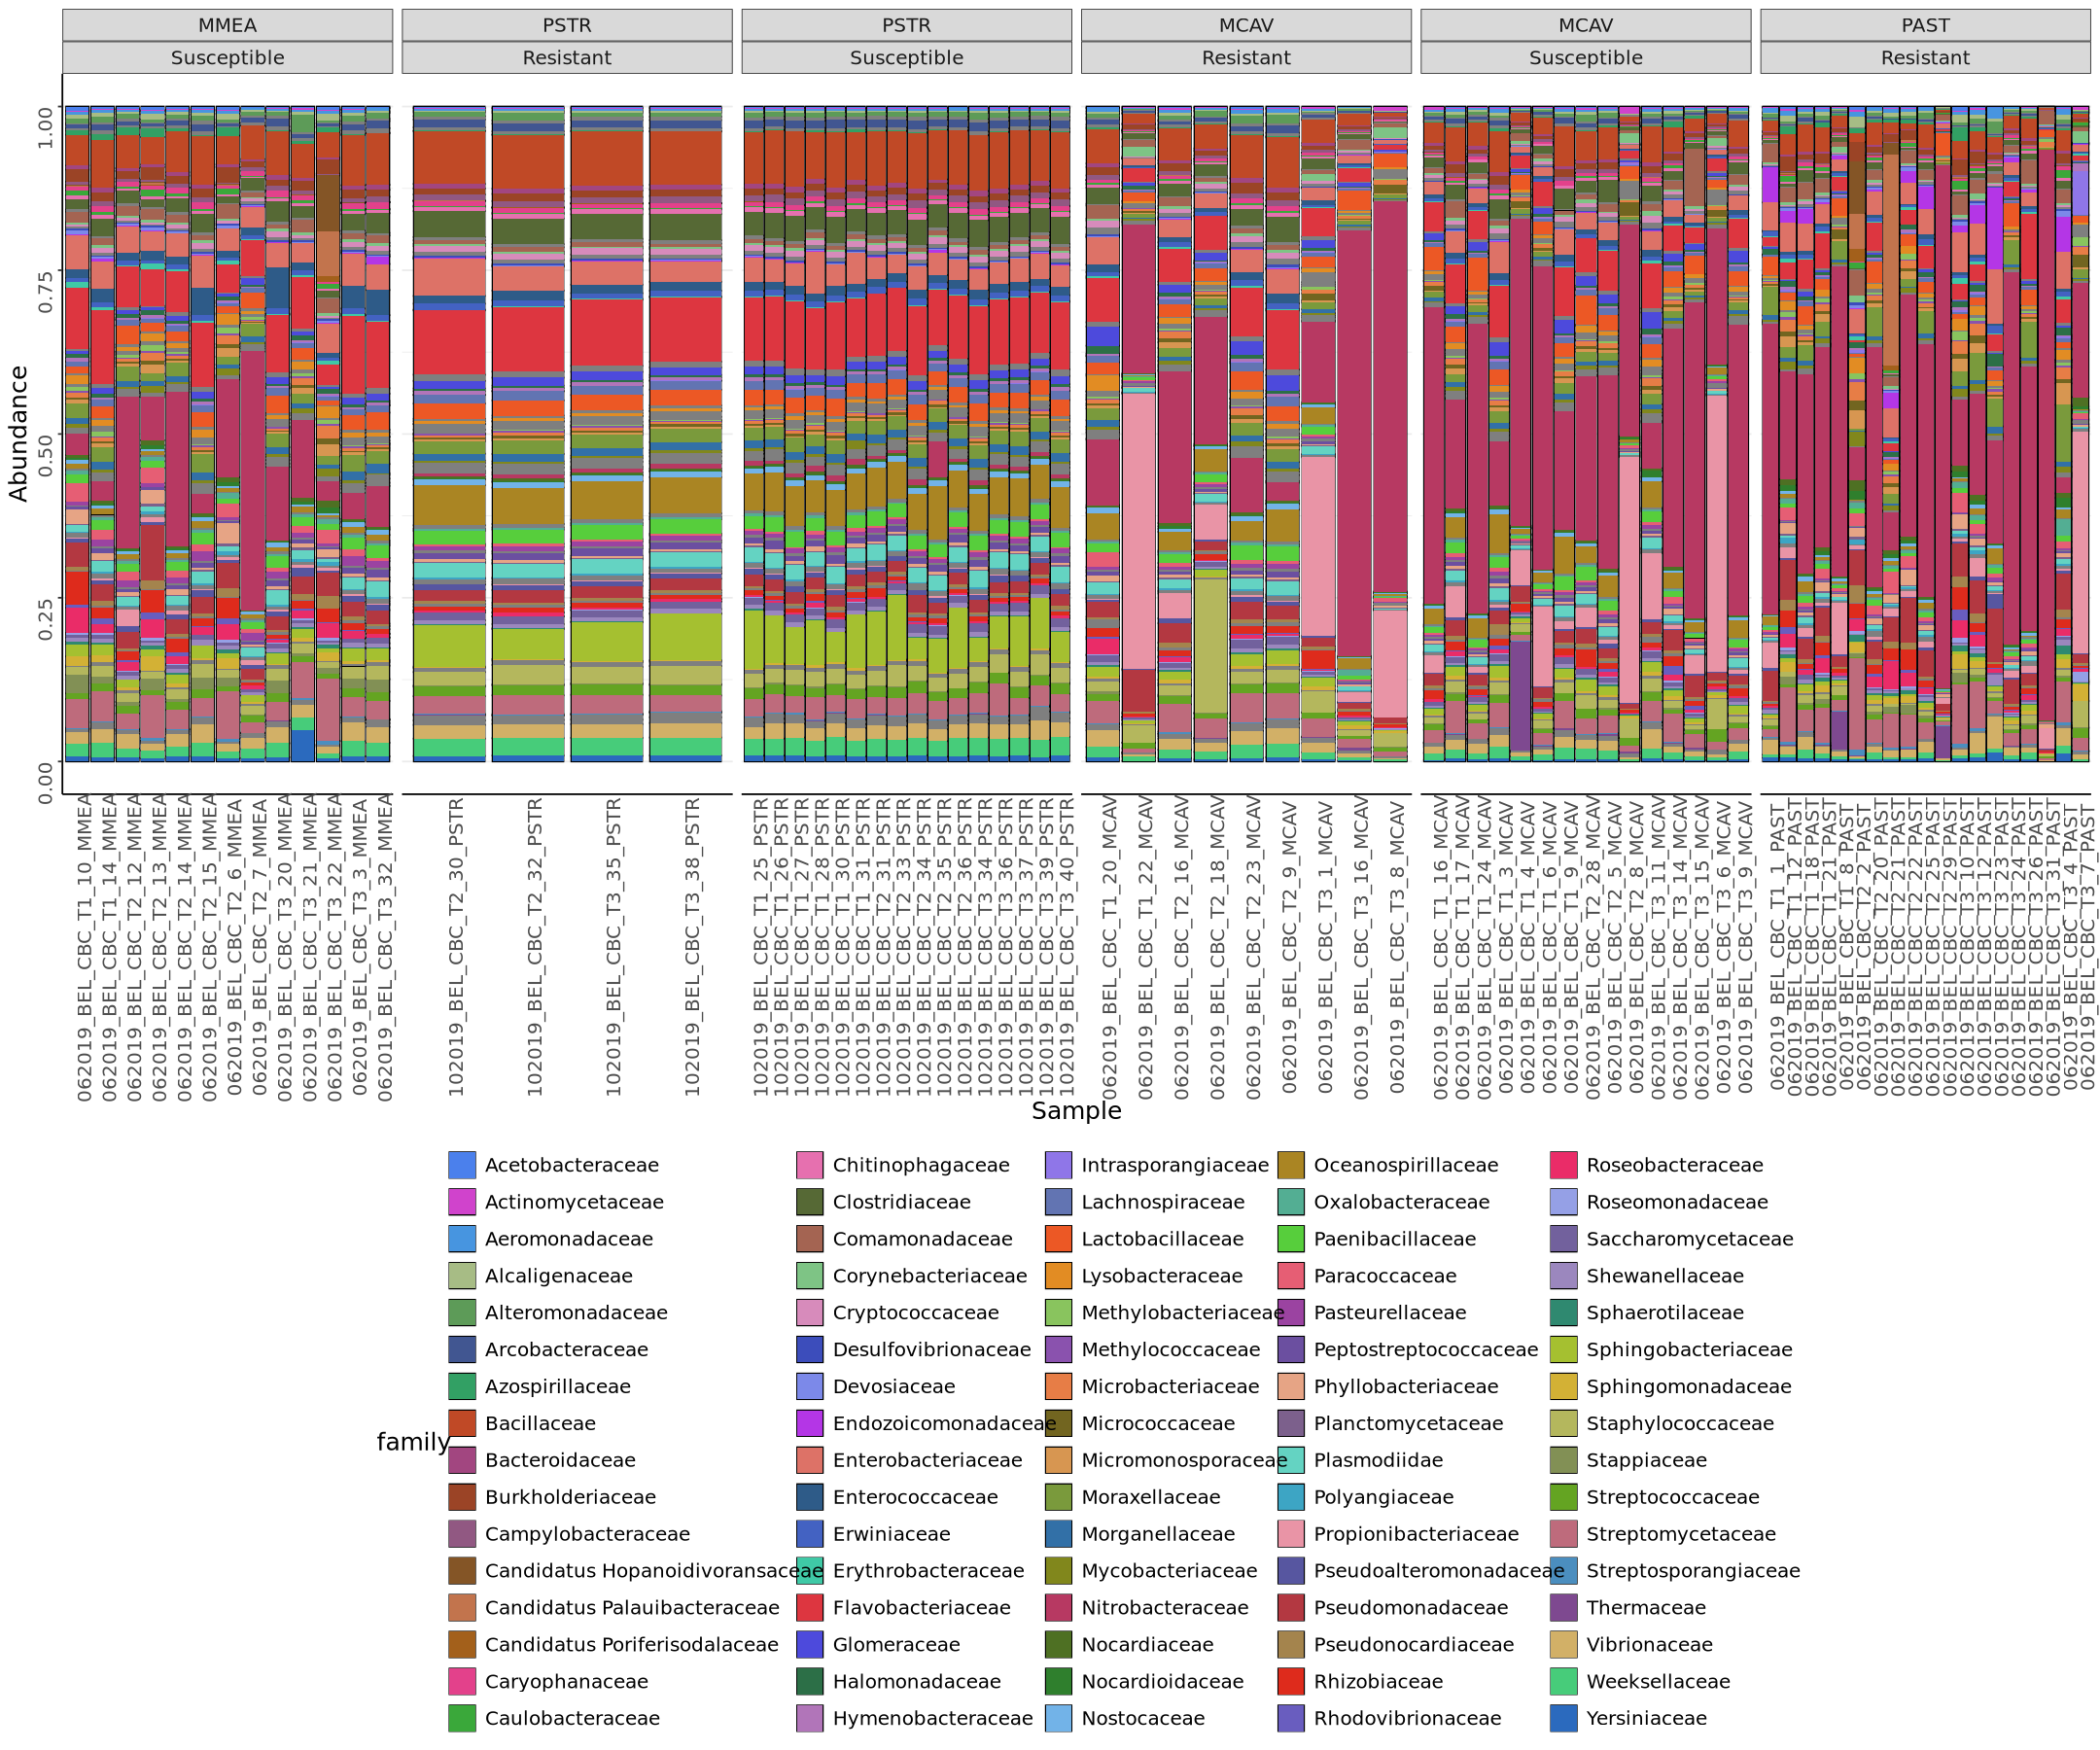

In [76]:
plot_bar(sctld_100_2019_norm,x = "Sample",fill='family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# 2019: Top 100 OTUs (family)

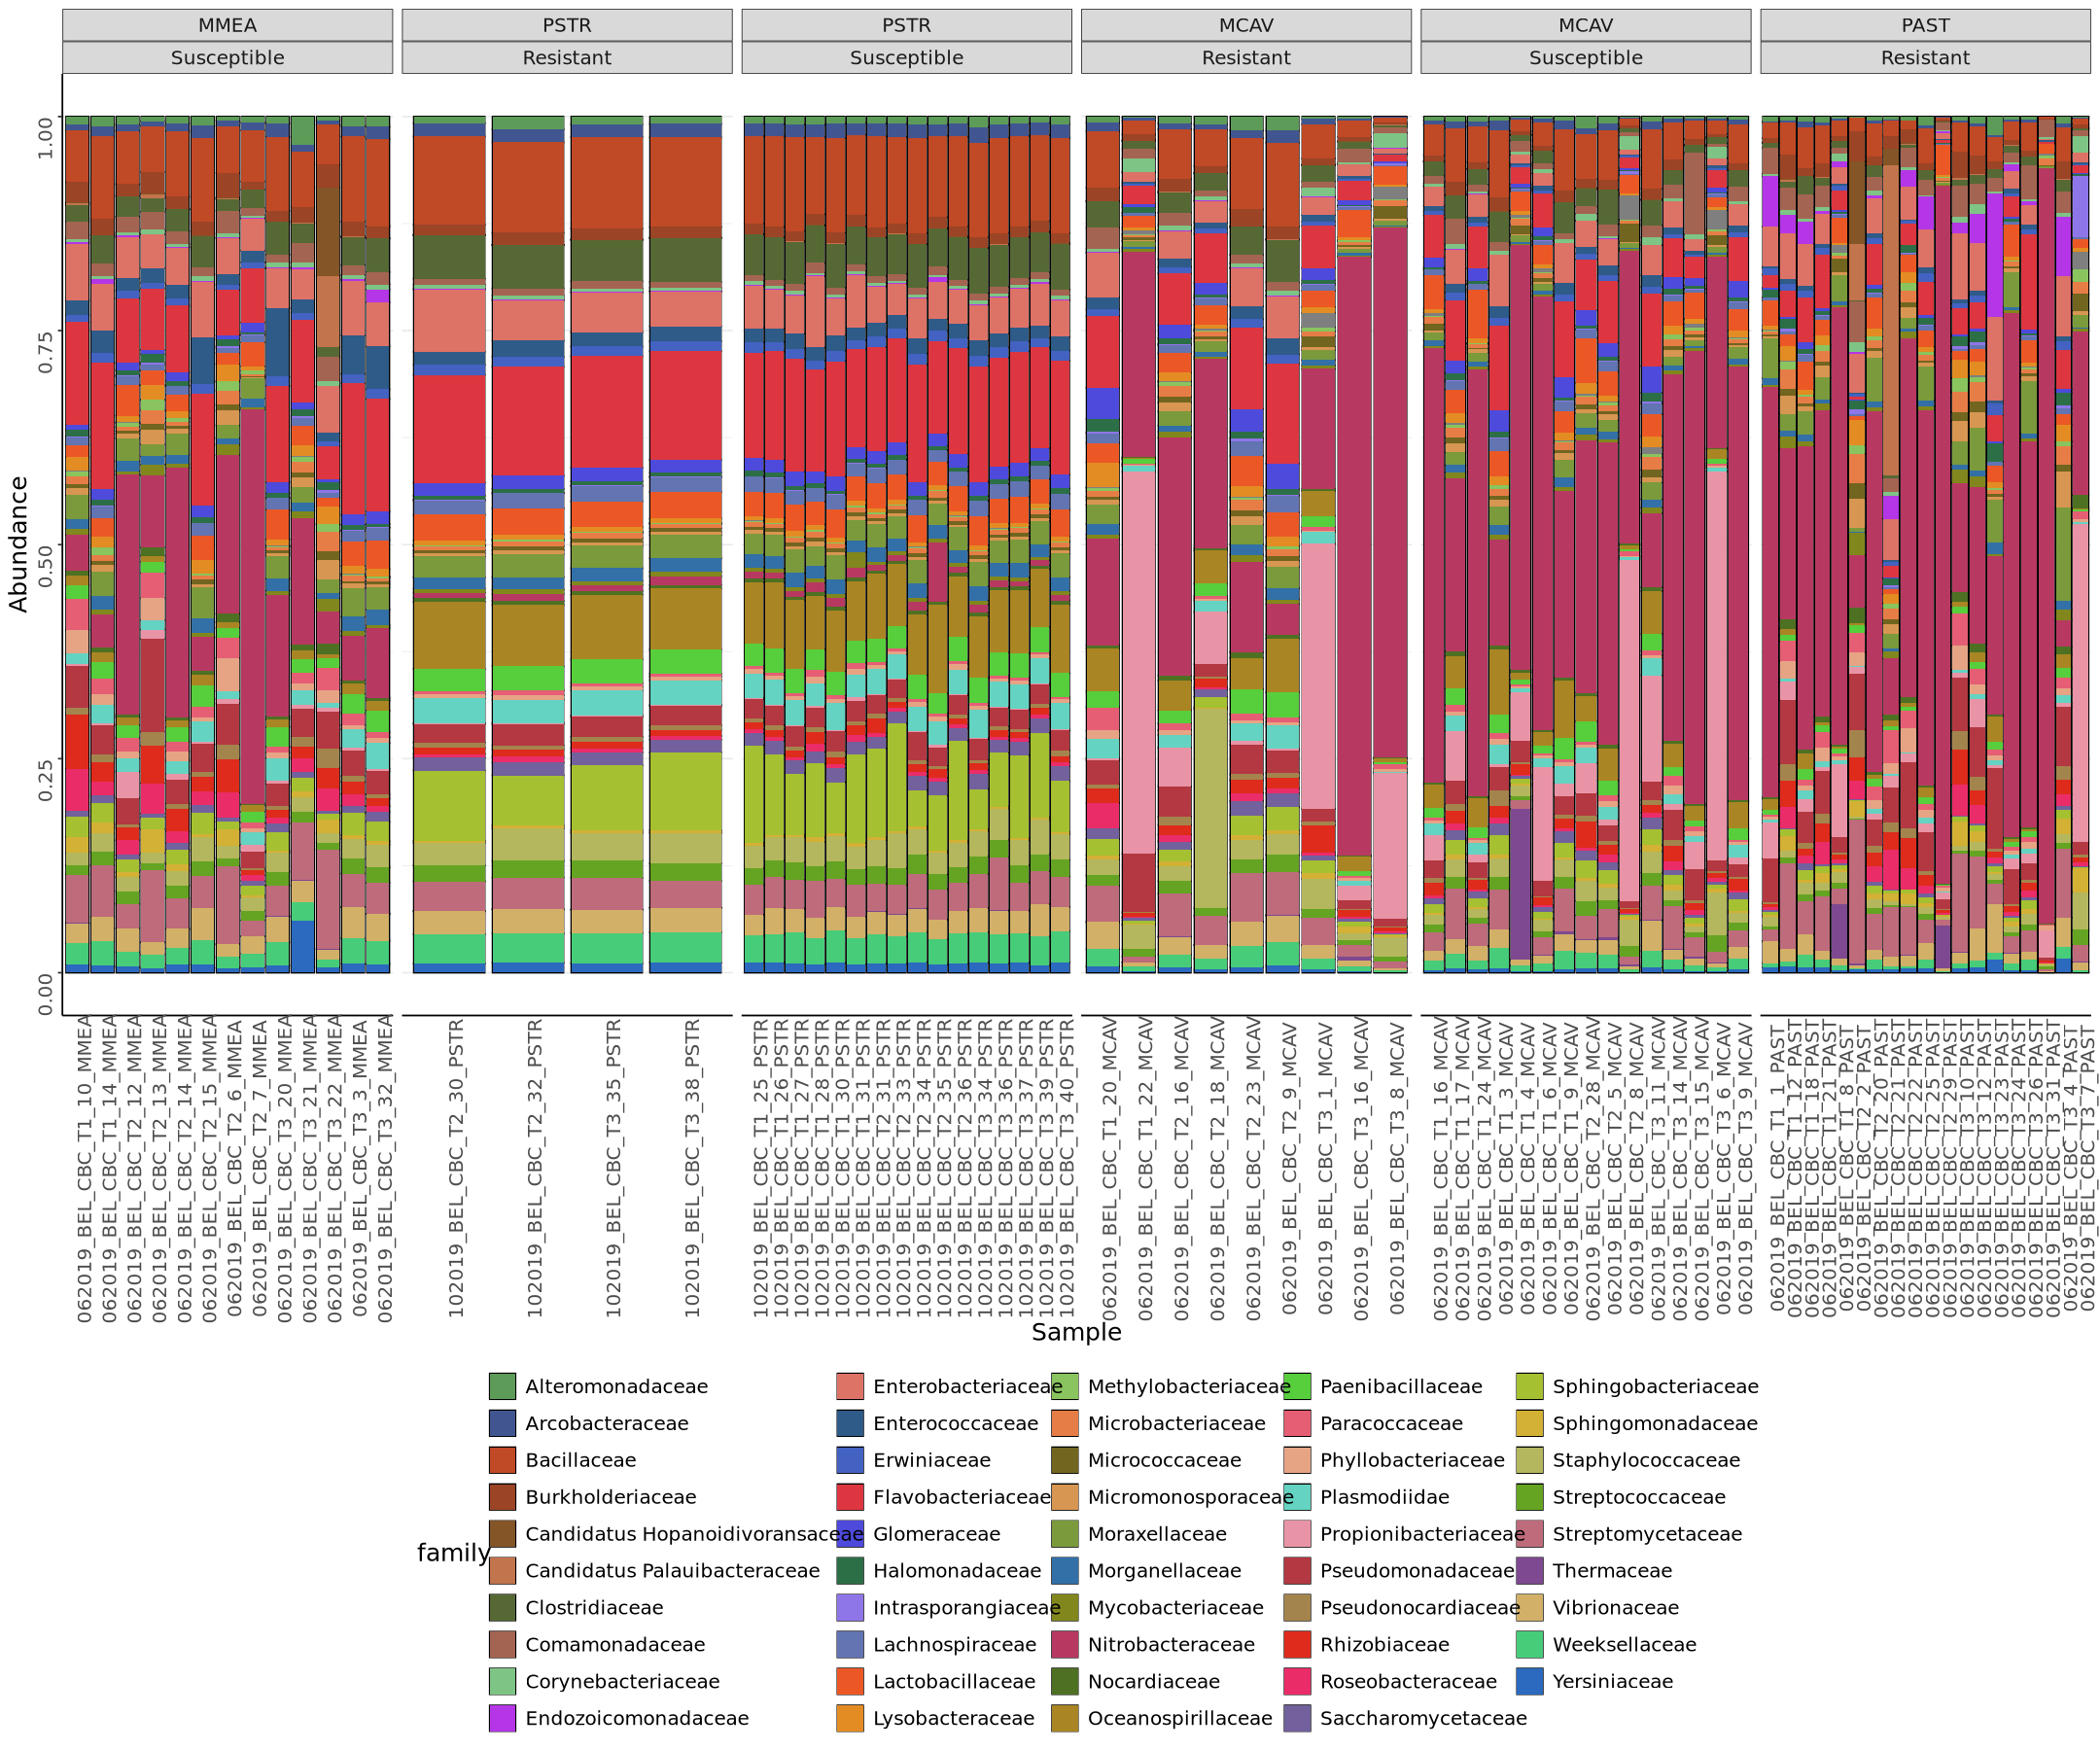

In [77]:
plot_bar(sctld_50_2019_norm,x = "Sample",fill='family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 50 genera 2019 only 

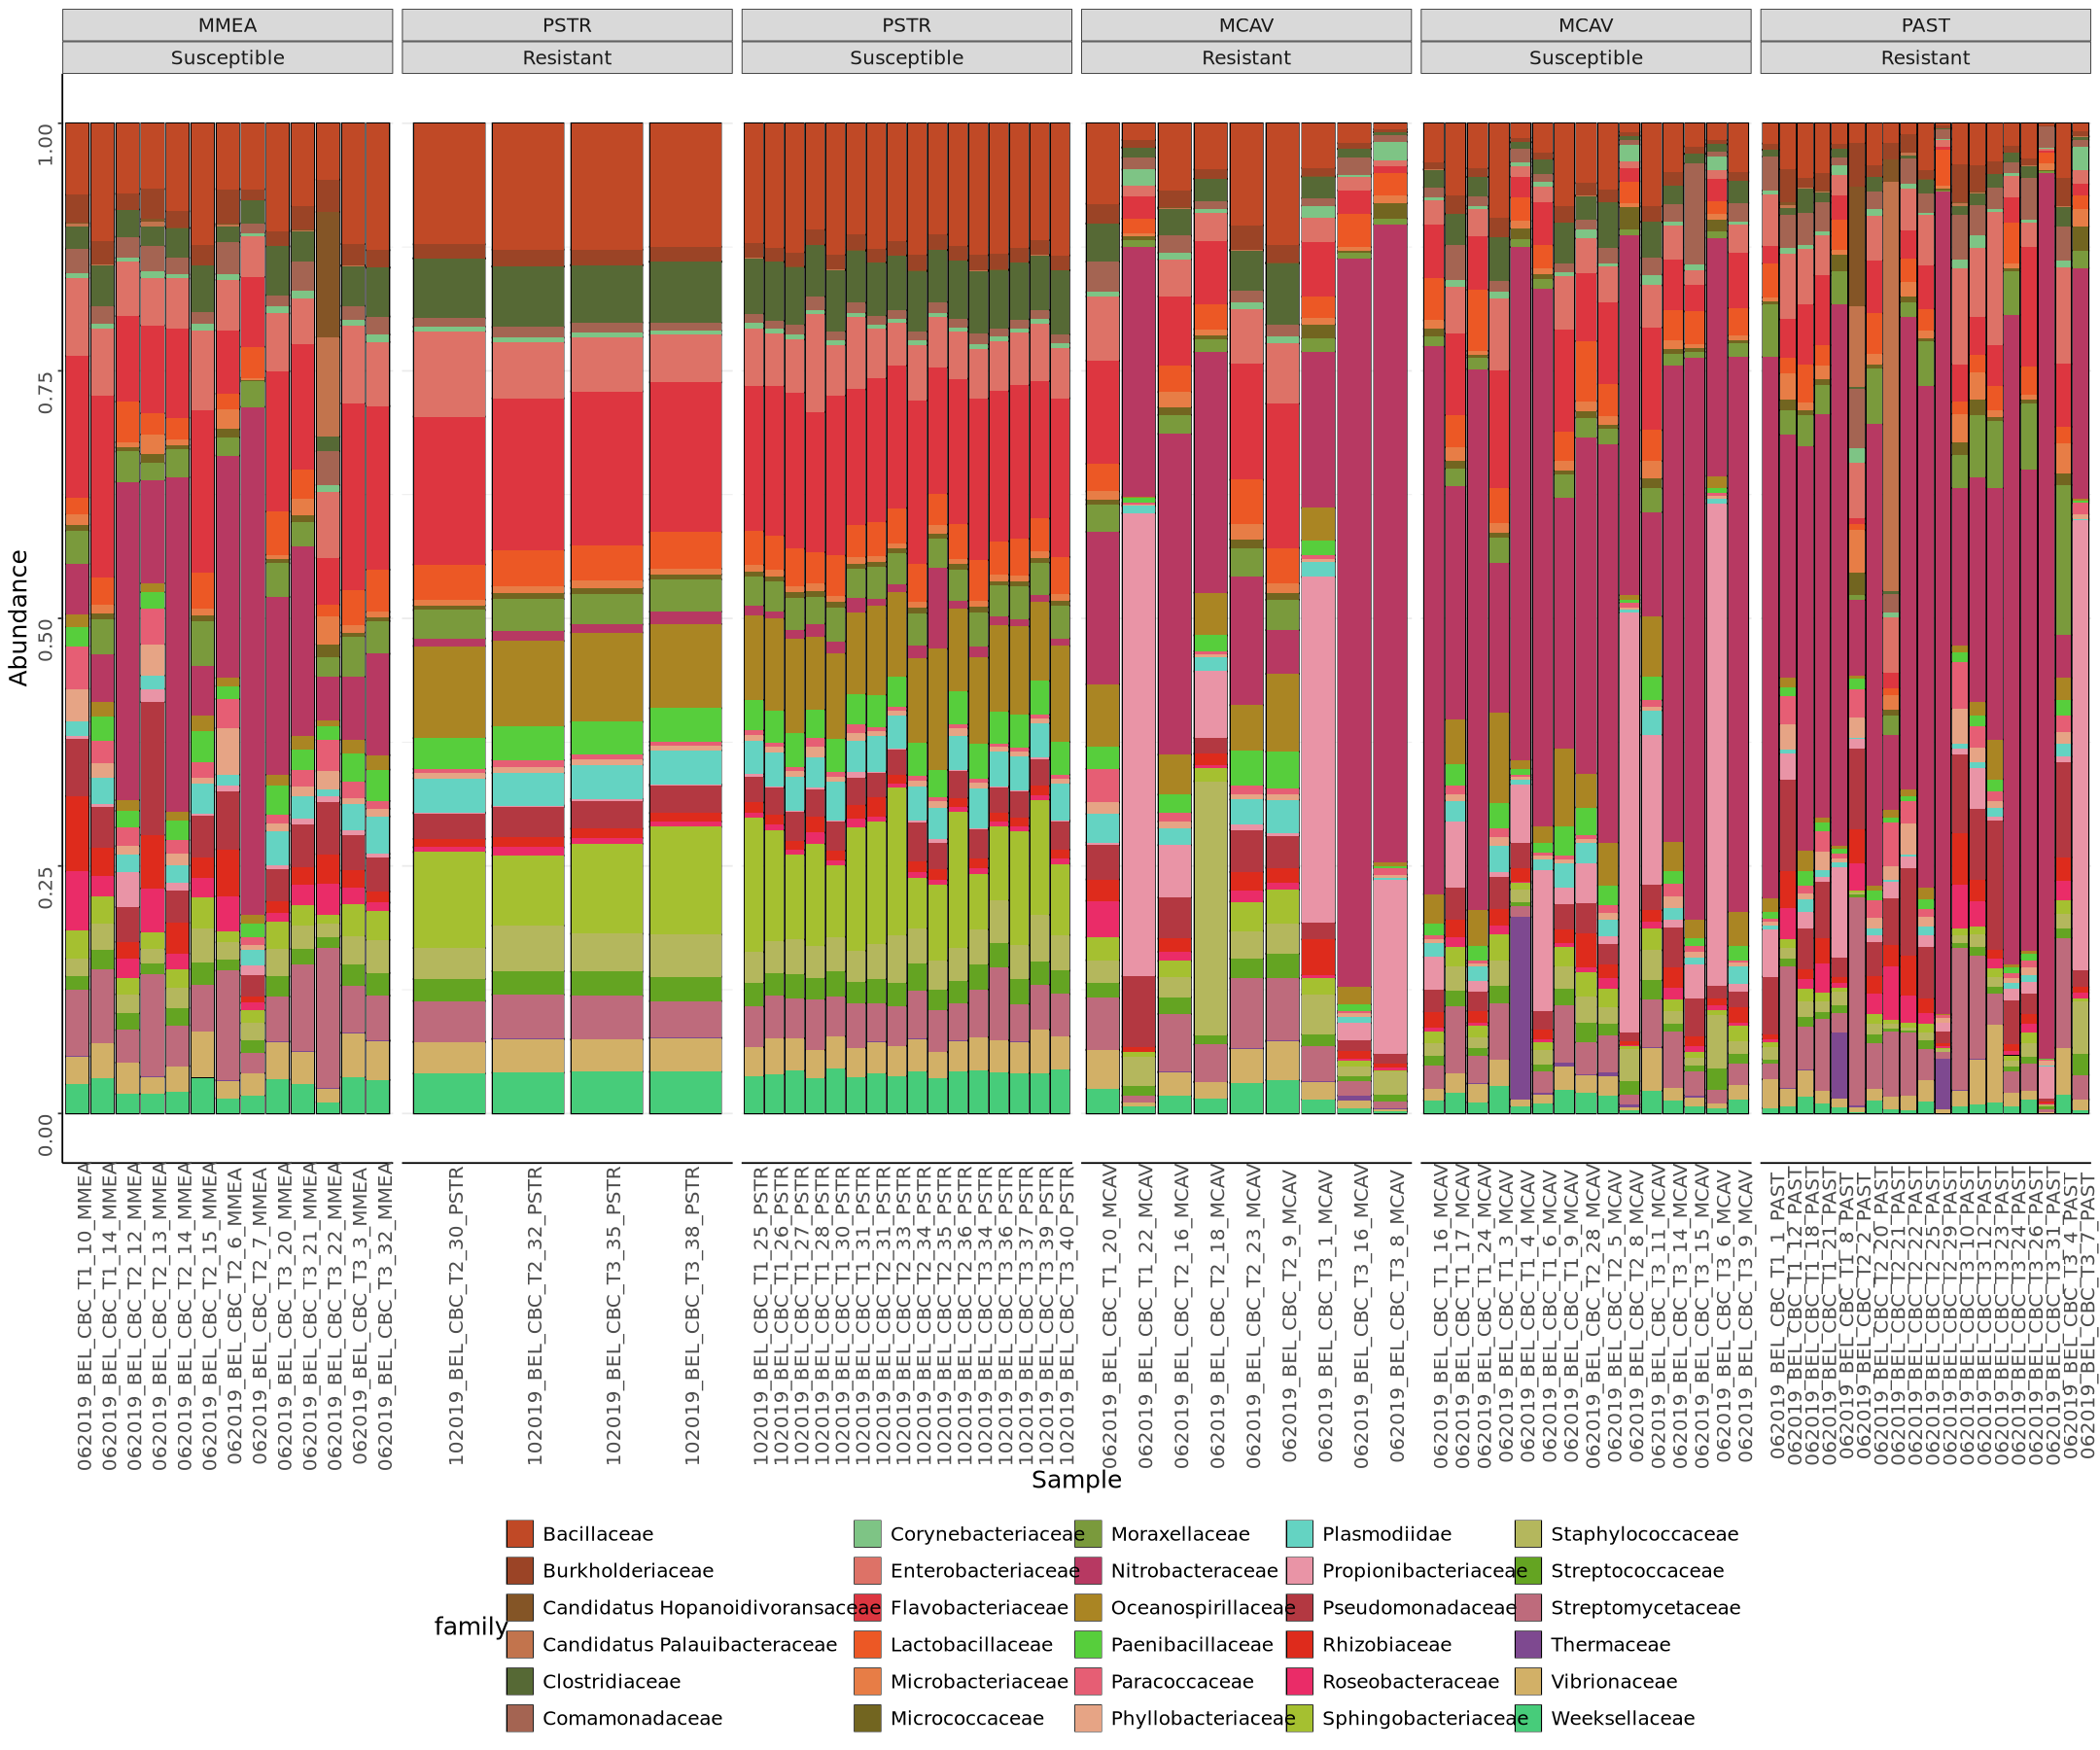

In [78]:
plot_bar(sctld_30_2019_norm,x = "Sample",fill='family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 30 genera 2019 only 

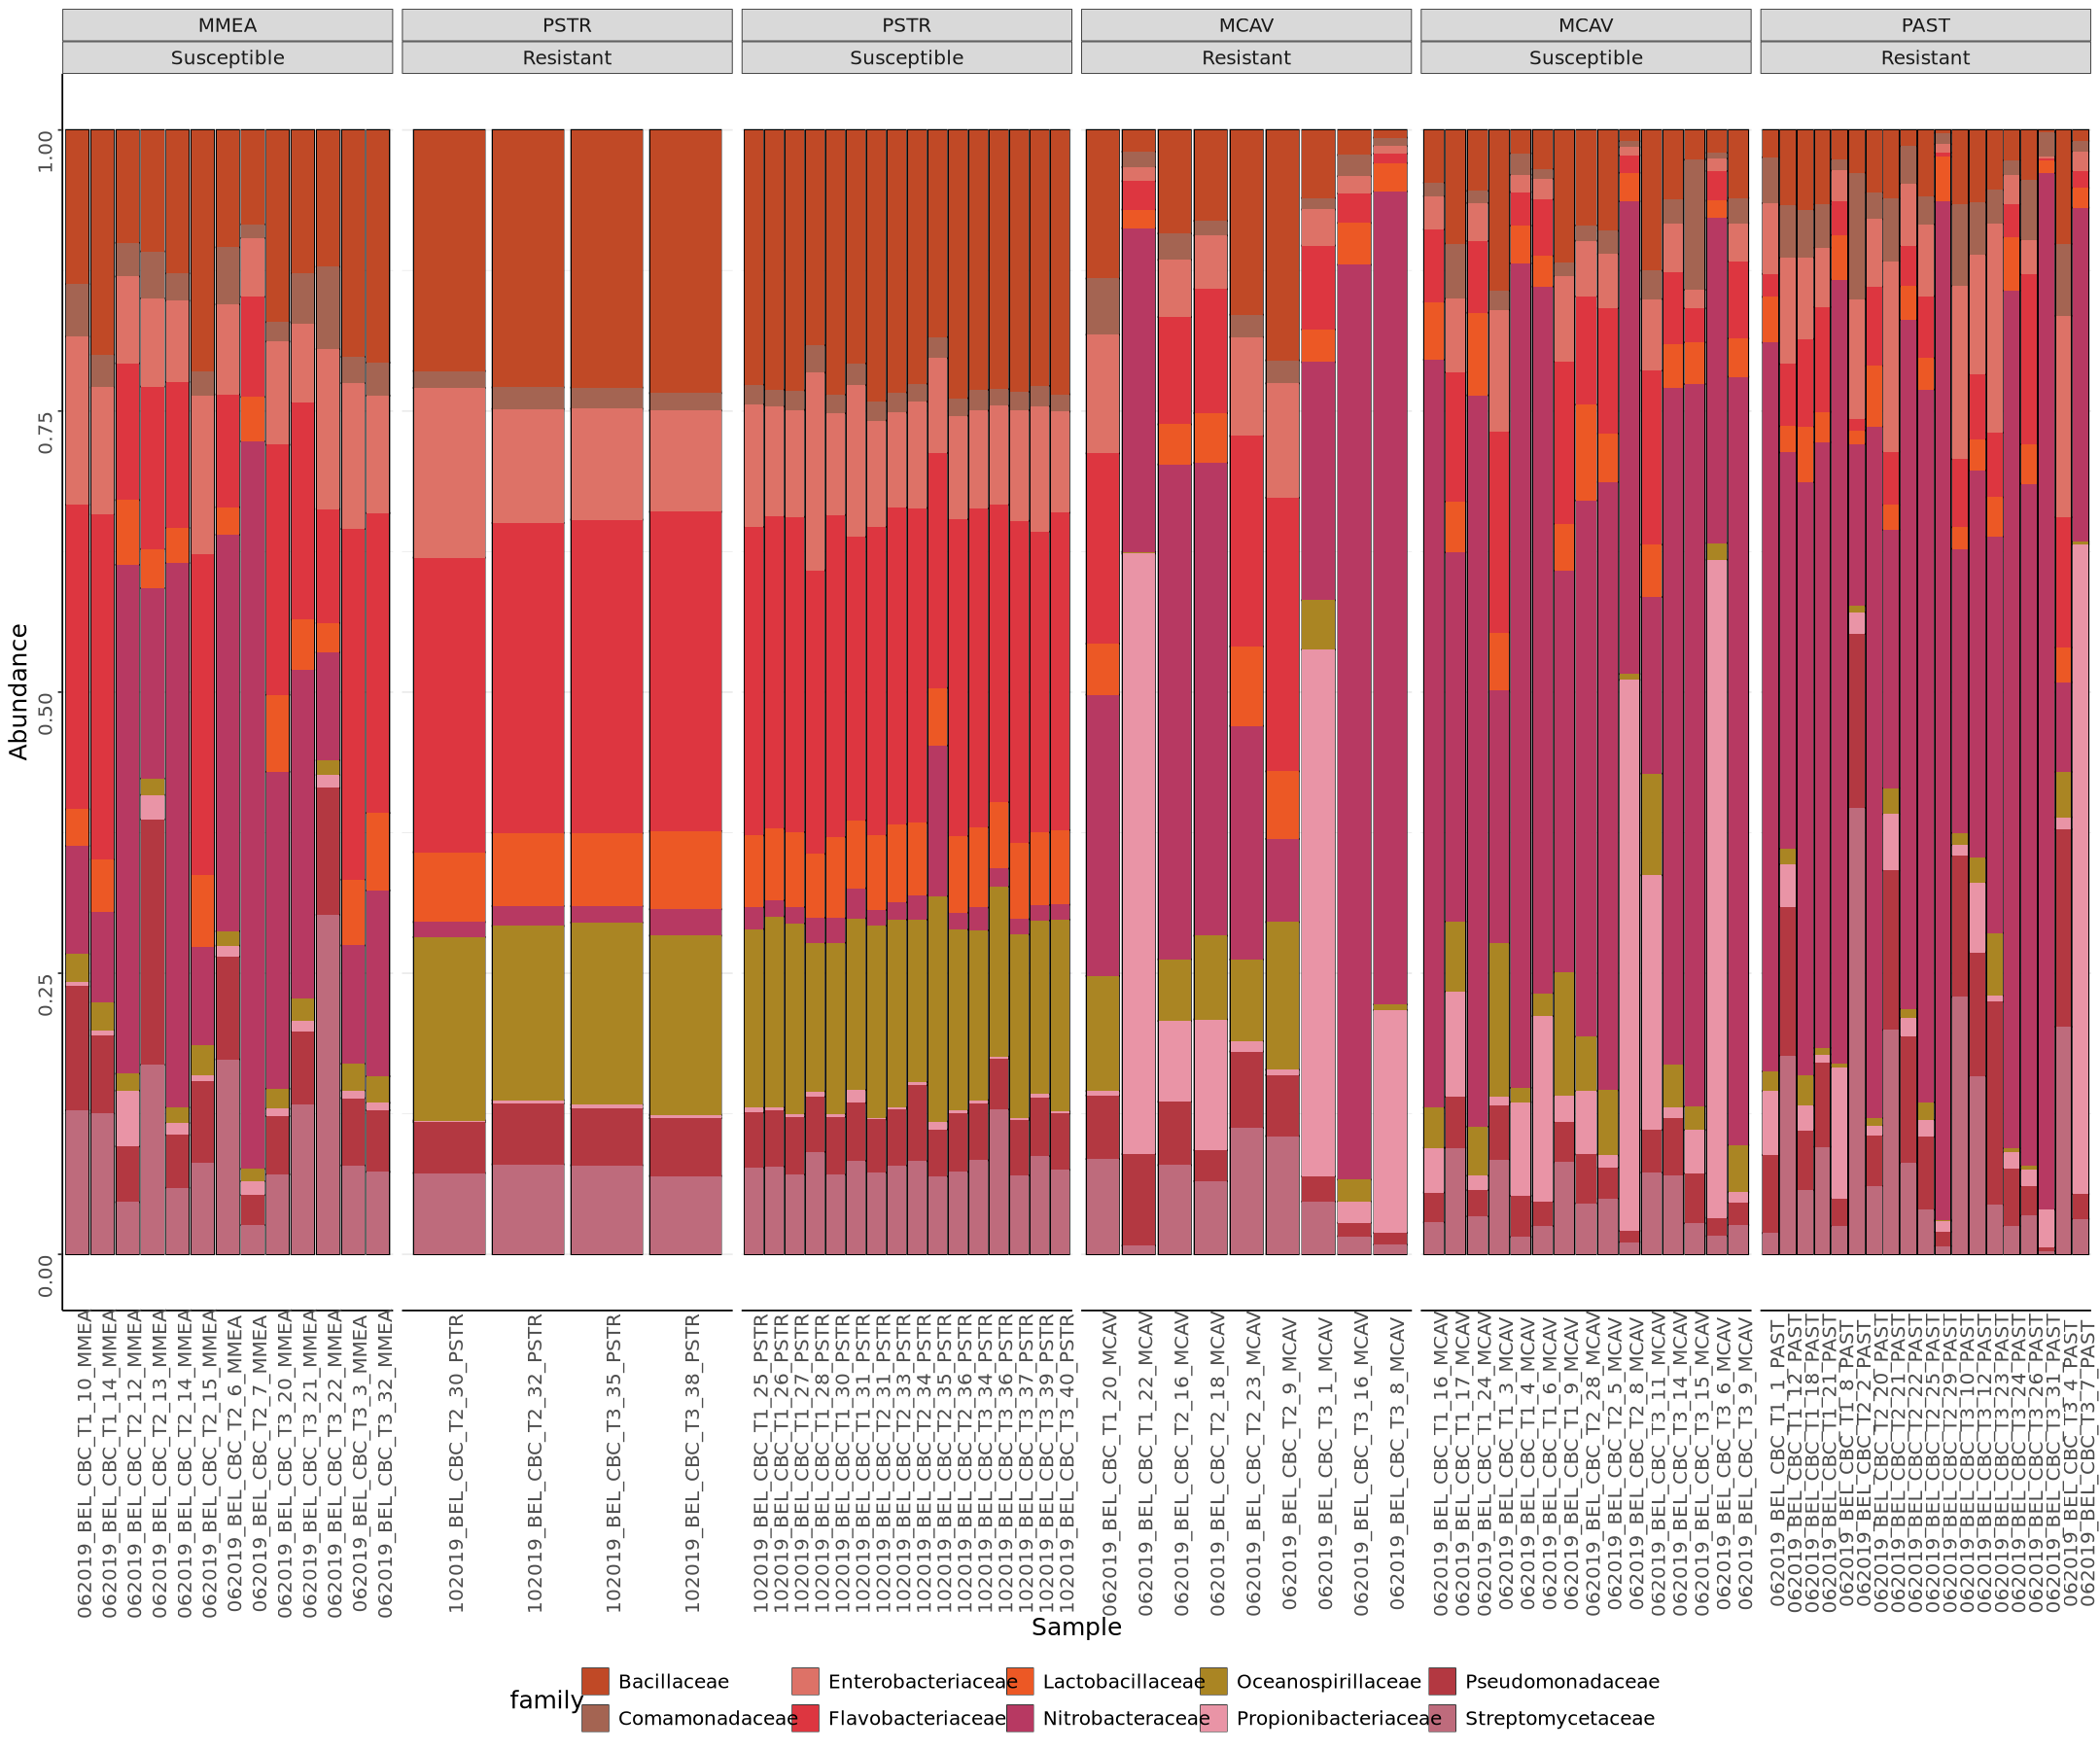

In [79]:
plot_bar(sctld_10_2019_norm,x = "Sample",fill='family')+
    facet_grid(~ Species + RS, scales = "free_x") +
    geom_bar(aes(x = fct_reorder(Sample, Month_year), fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# top 10 genera 2019 only 

In [80]:
# plot each spp individually...

#### MCAV --------------------------------------------------------------------------------

In [81]:
library(ggh4x)


Attaching package: ‘ggh4x’


The following object is masked from ‘package:cowplot’:

    save_plot




In [82]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [83]:
# looking just at mcav, remove disease margin

subset_mcav<- subset_samples(sctld_raw, (Species == "MCAV" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_mcav<- subset_samples(subset_mcav, (!(Date_InitialTag %in% dec_tags)))

# top 100 family
mcav_100 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:100]), subset_mcav)
mcav_100_norm <- transform_sample_counts(mcav_100, function(x) x / sum(x))

# top 50 family
mcav_50 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:50]), subset_mcav)
mcav_50_norm <- transform_sample_counts(mcav_50, function(x) x / sum(x))

# top 30 family
mcav_30 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:30]), subset_mcav)
mcav_30_norm <- transform_sample_counts(mcav_30, function(x) x / sum(x))

# top 10 family
mcav_10 = prune_taxa(names(sort(taxa_sums(subset_mcav),TRUE)[1:10]), subset_mcav)
mcav_10_norm <- transform_sample_counts(mcav_10, function(x) x / sum(x))

In [84]:
df_meta <- data.frame(sample_data(subset_mcav))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_mcav) <- sample_data(df_meta)

In [85]:
library(patchwork)


Attaching package: ‘patchwork’


The following object is masked from ‘package:cowplot’:

    align_plots




In [86]:
# reorder colonies
mcav_g_S<-subset_samples(subset_mcav, RS == "Susceptible")
df_meta<-data.frame(sample_data(mcav_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(mcav_g_S)$colony_id <-
  factor(sample_data(mcav_g_S)$colony_id, levels = col_order)

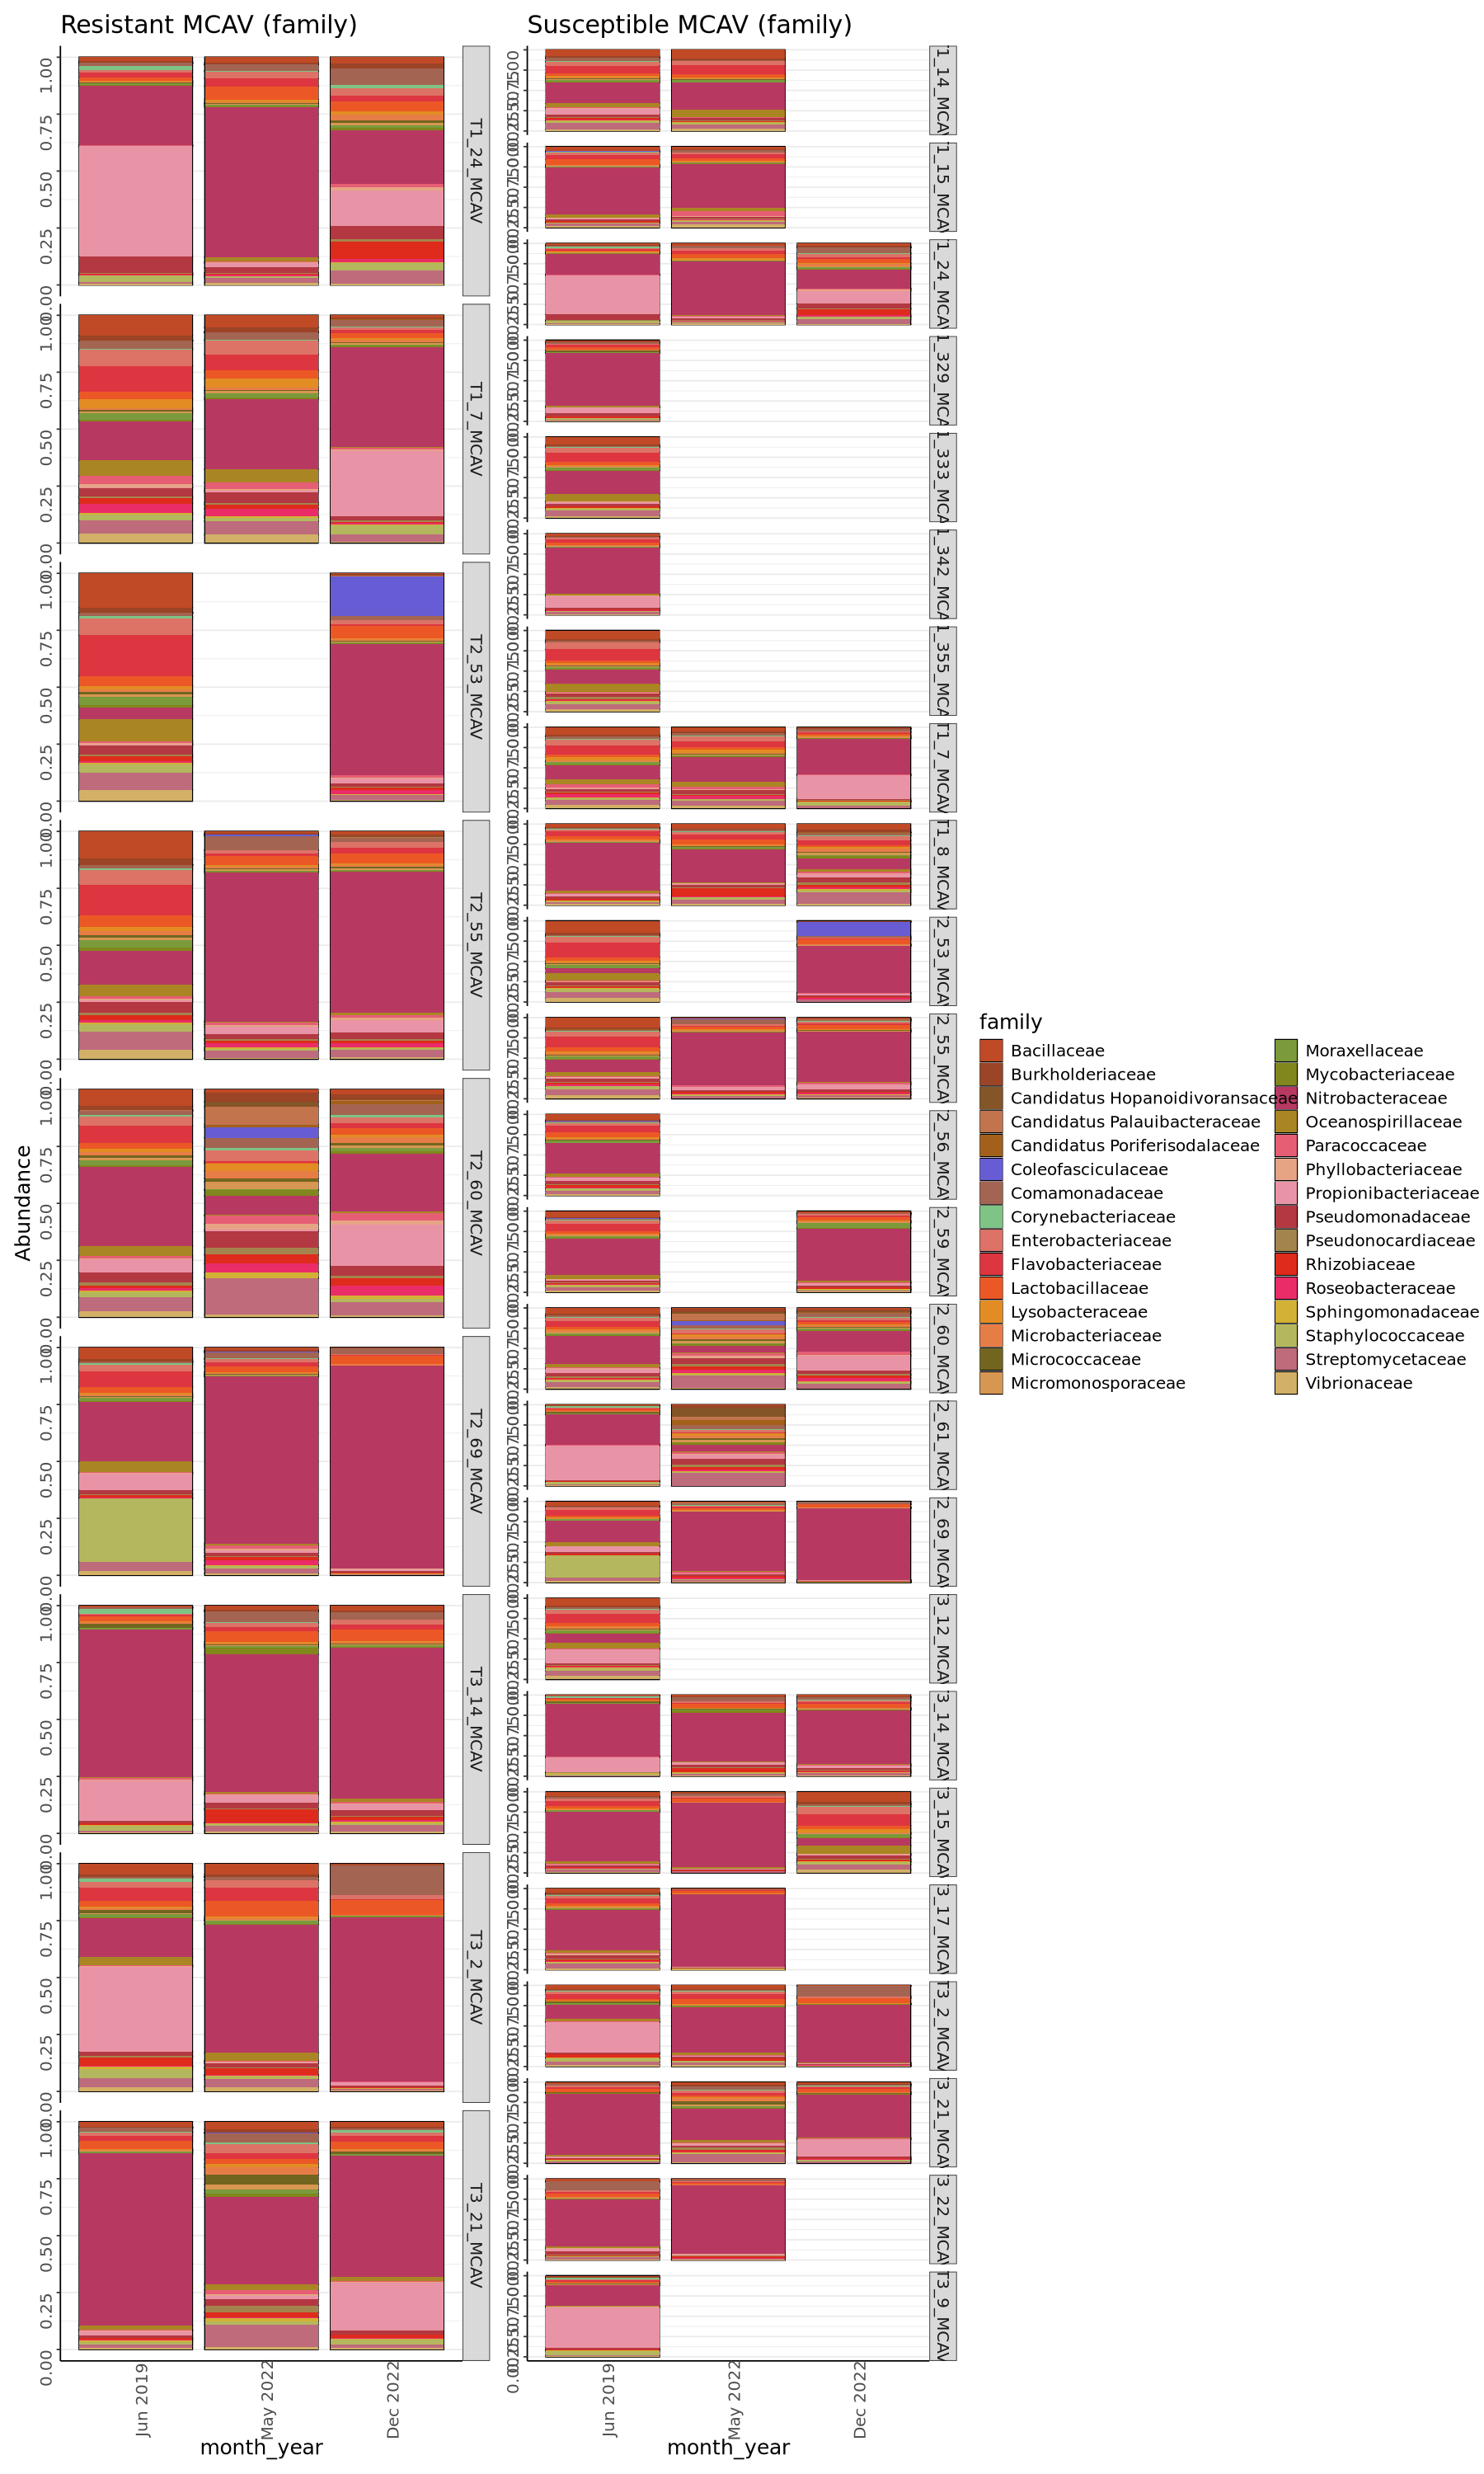

In [87]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(mcav_30_norm, RS == "Resistant"),x = "month_year", fill = "family")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant MCAV (family)")

p_S <- plot_bar(mcav_30_norm,x = "month_year", fill = "family") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible MCAV (family)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "MCAV colonies") &
  theme(legend.position = "right")

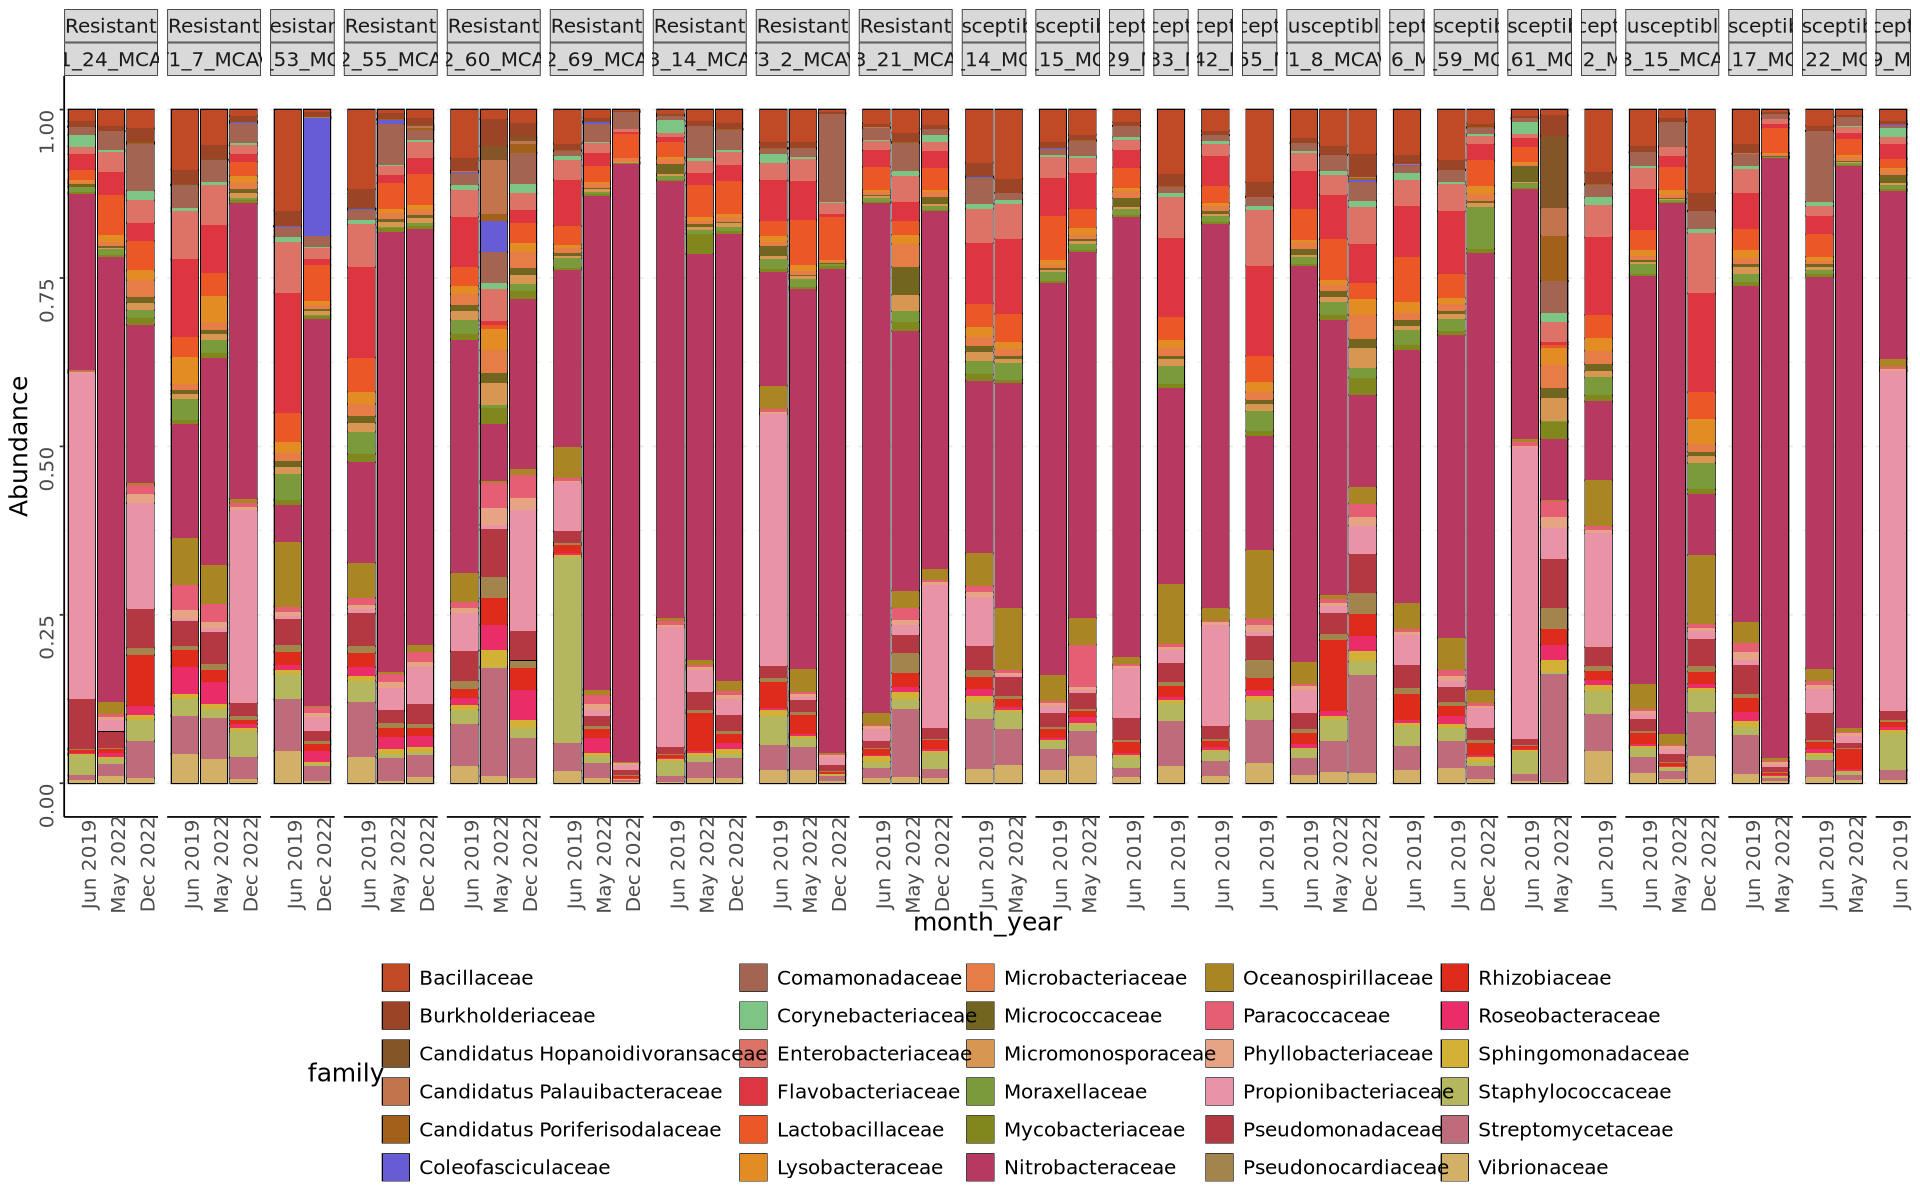

In [88]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_30_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 family - R vs S. individuals over time 

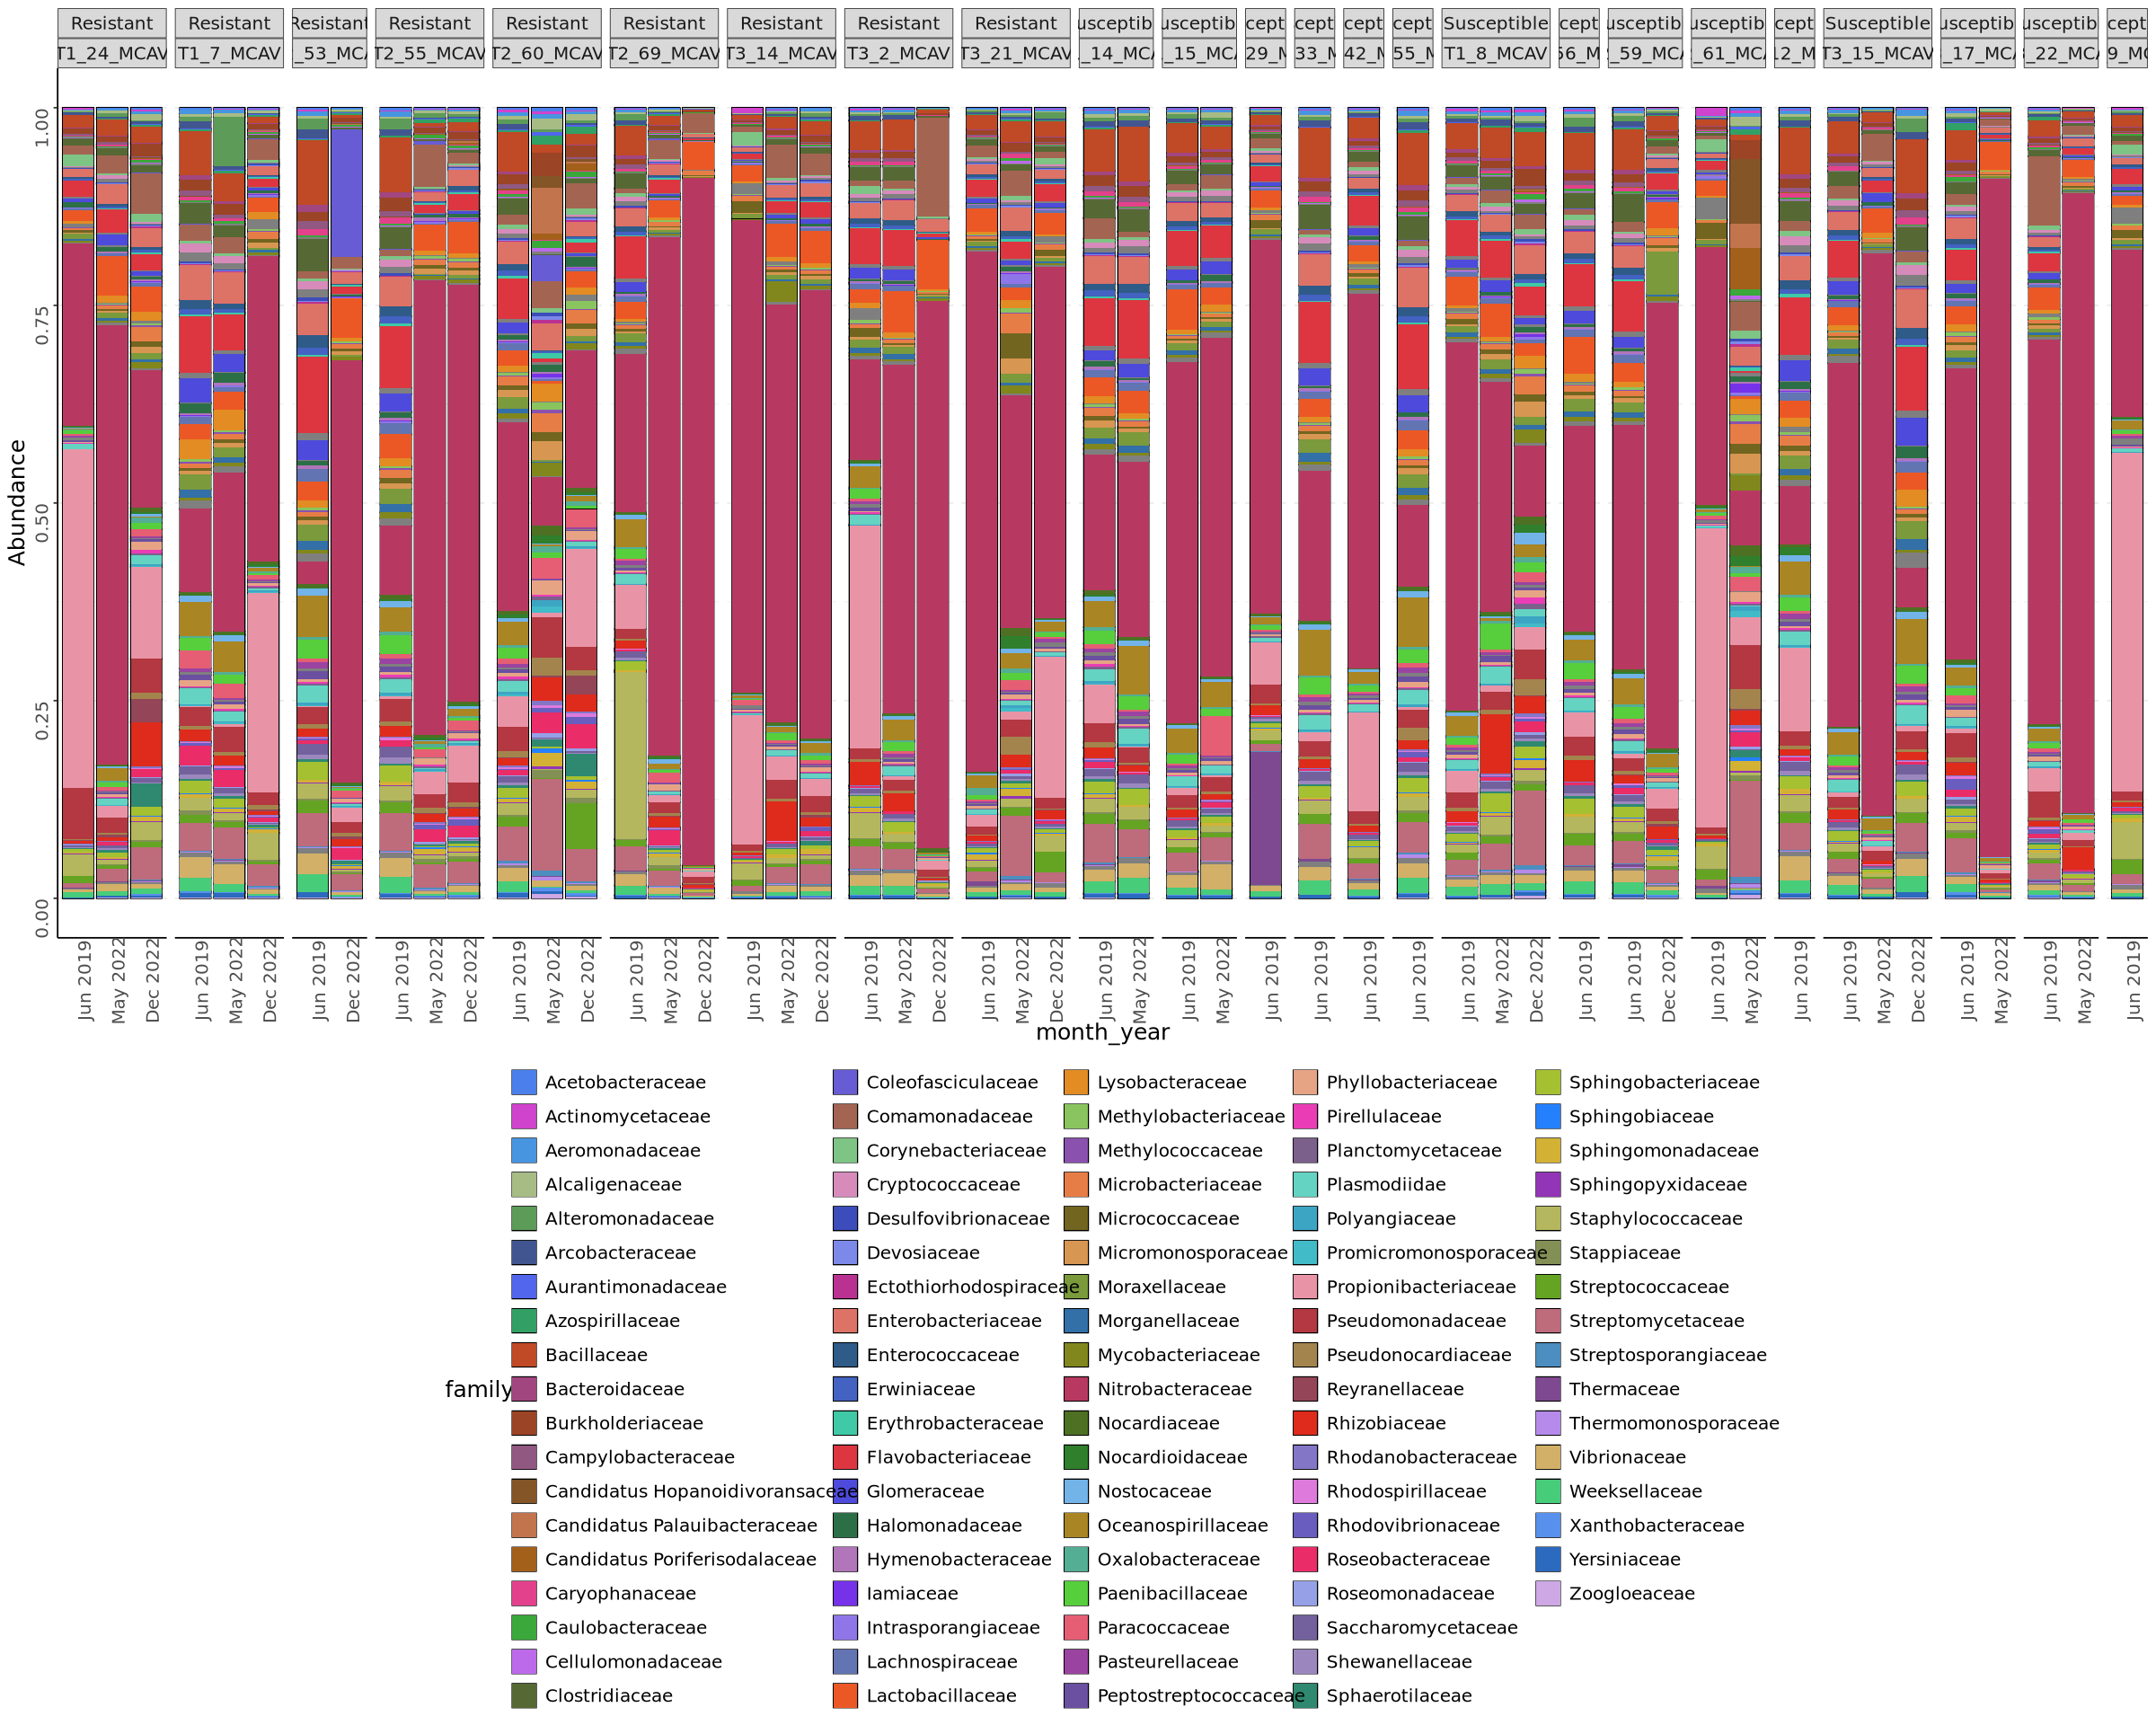

In [89]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_100_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (family)

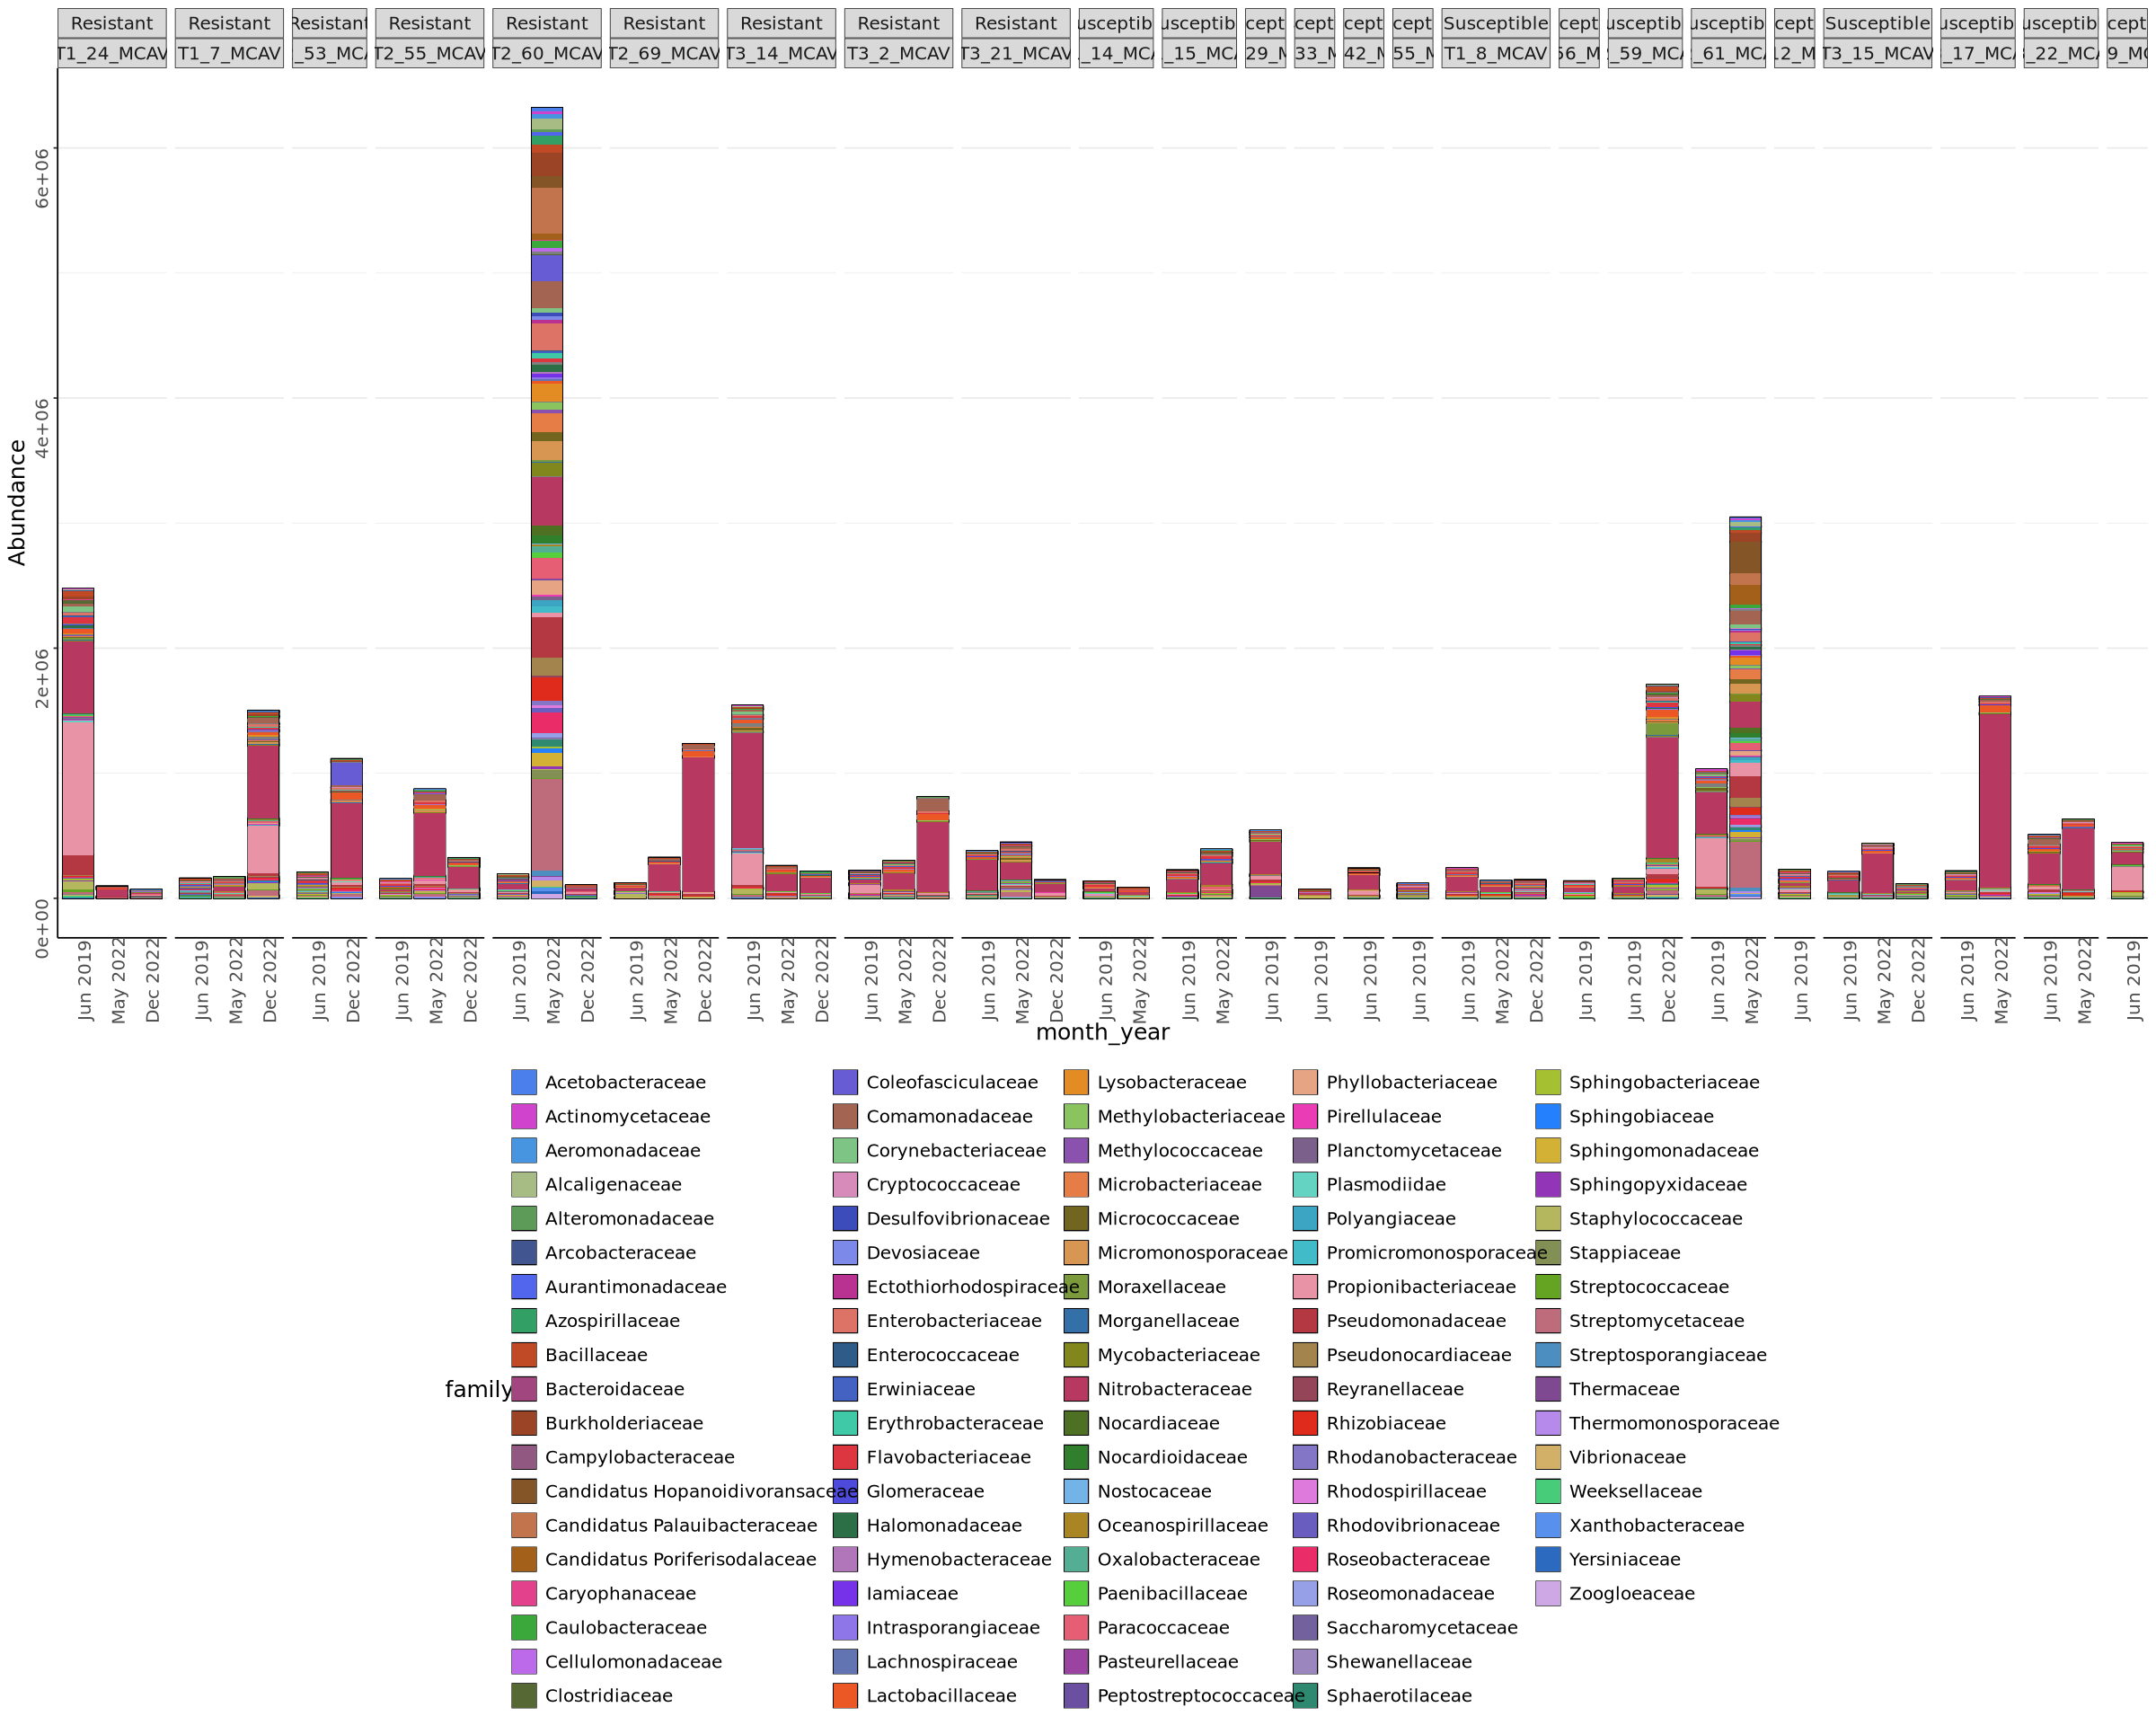

In [90]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_100,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 100 family

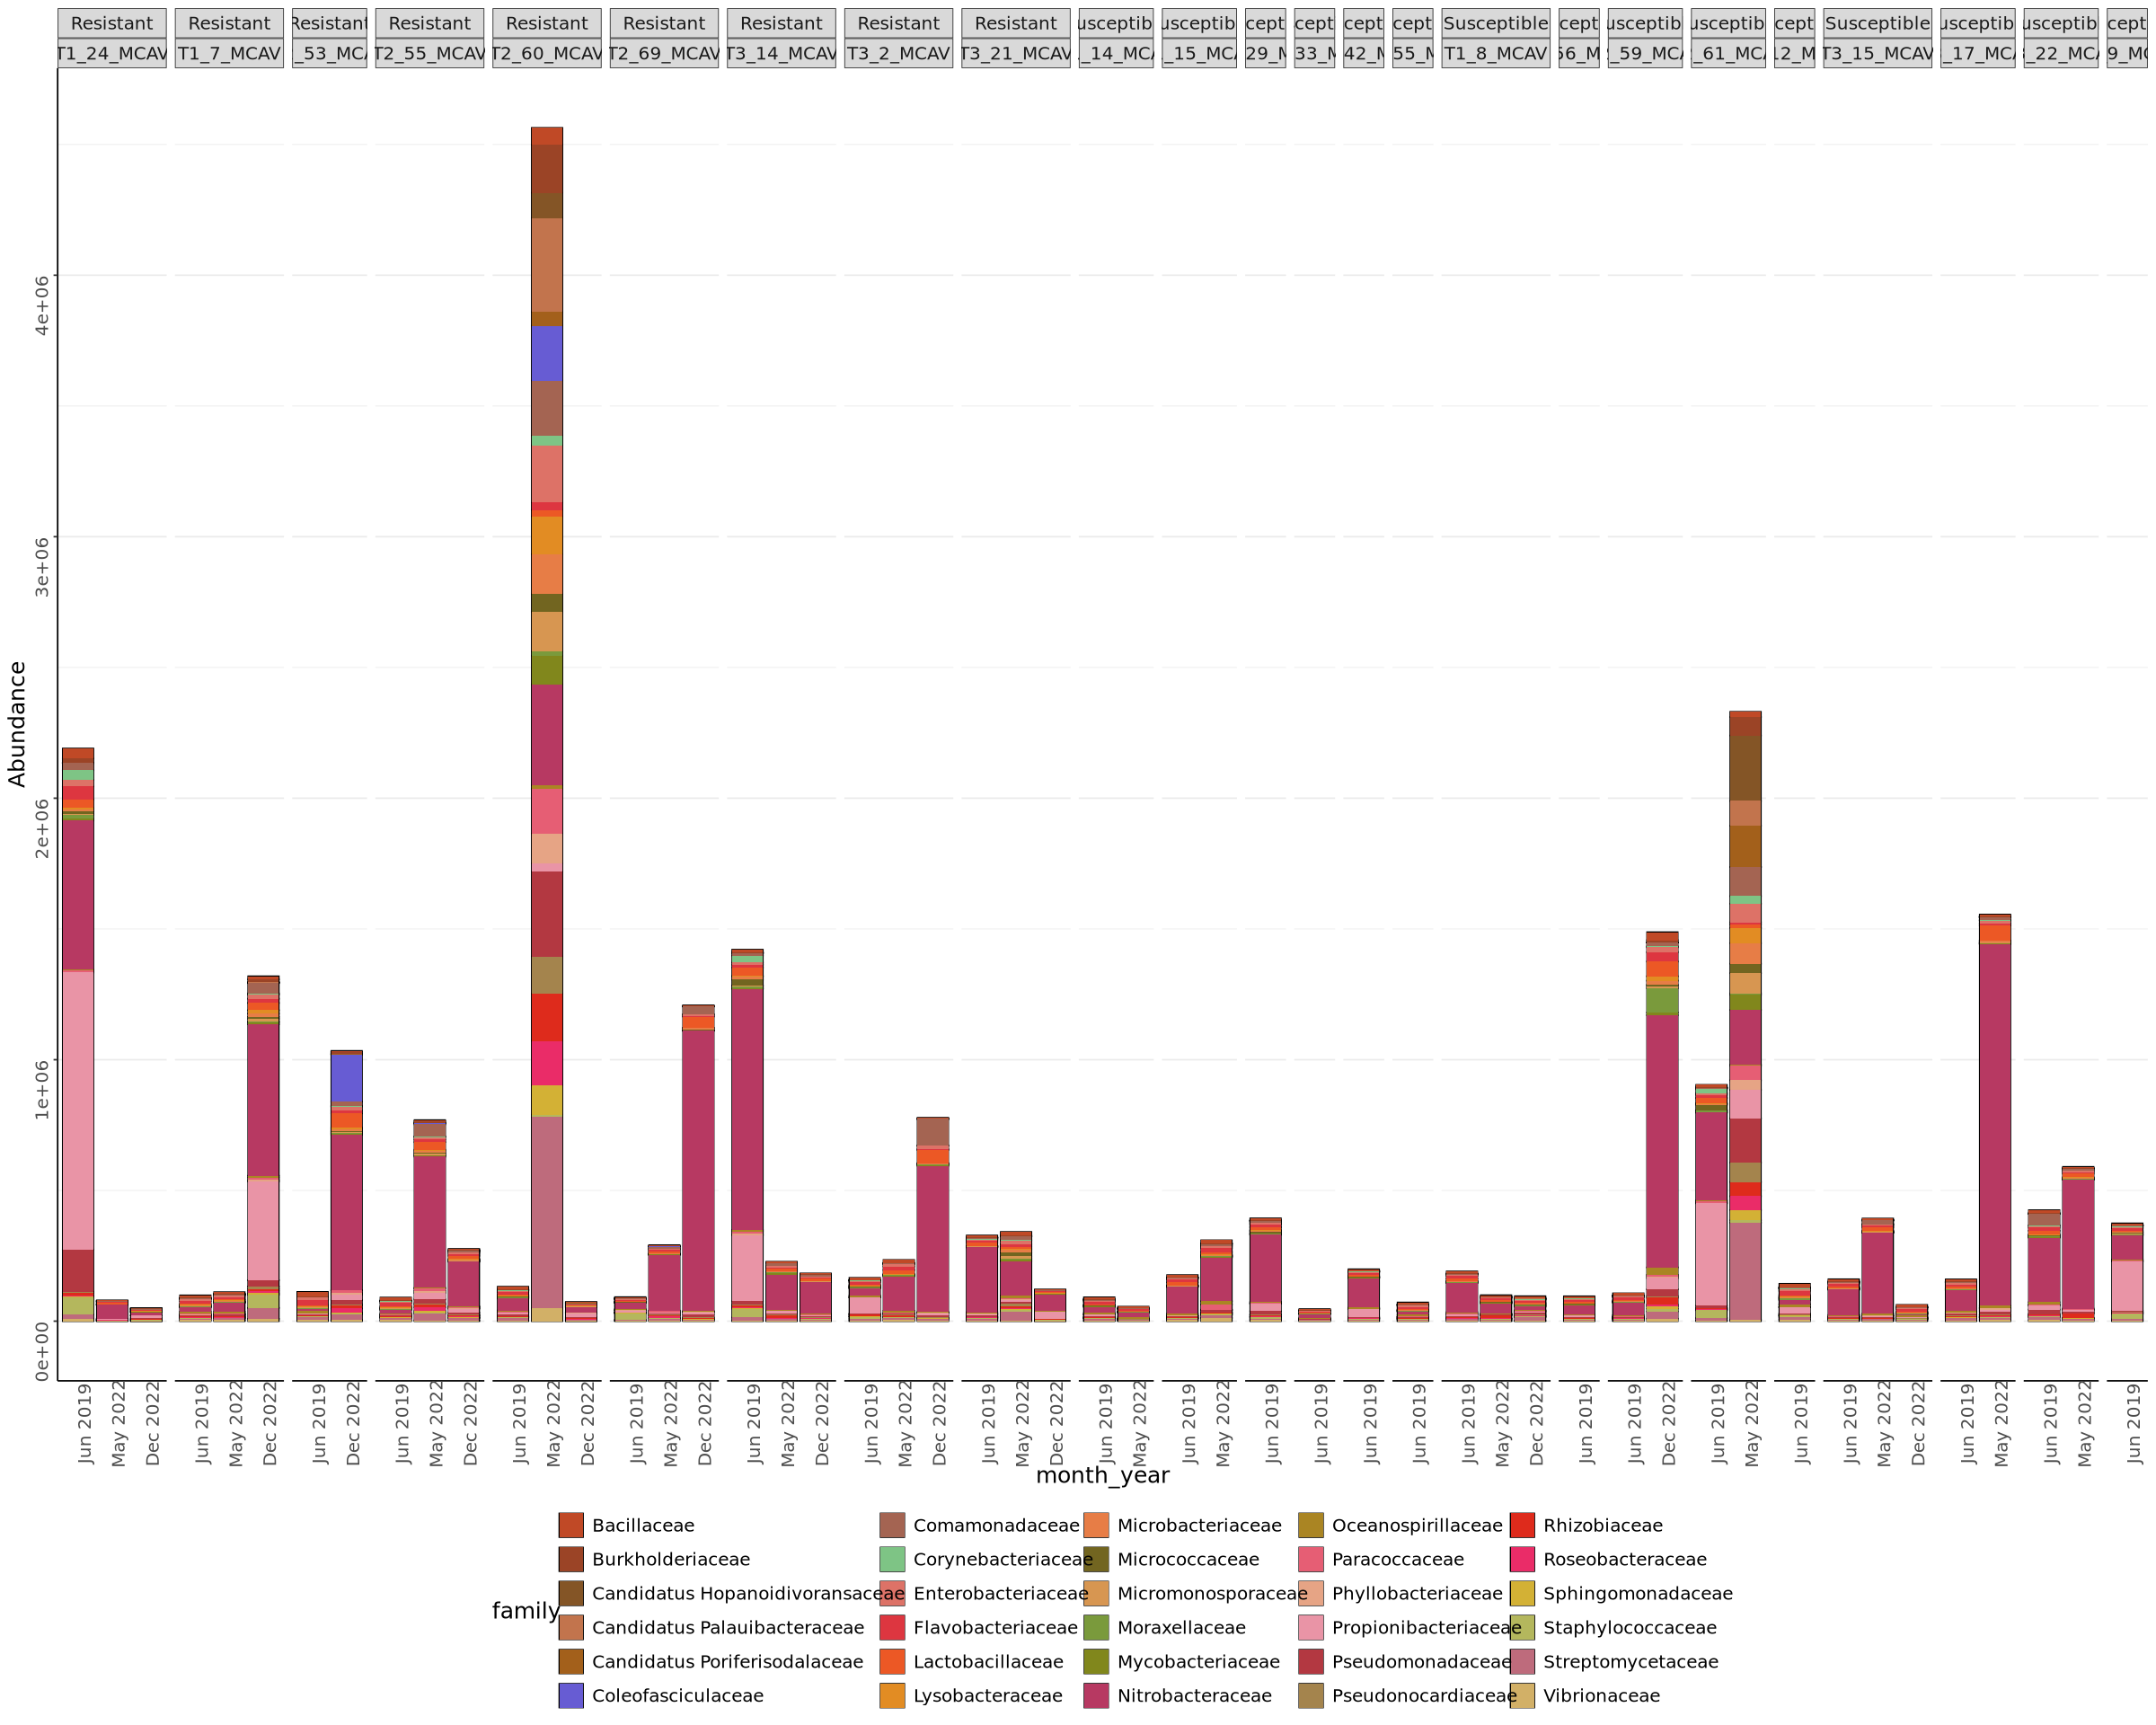

In [91]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(mcav_30,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))
# abundances - top 30 family

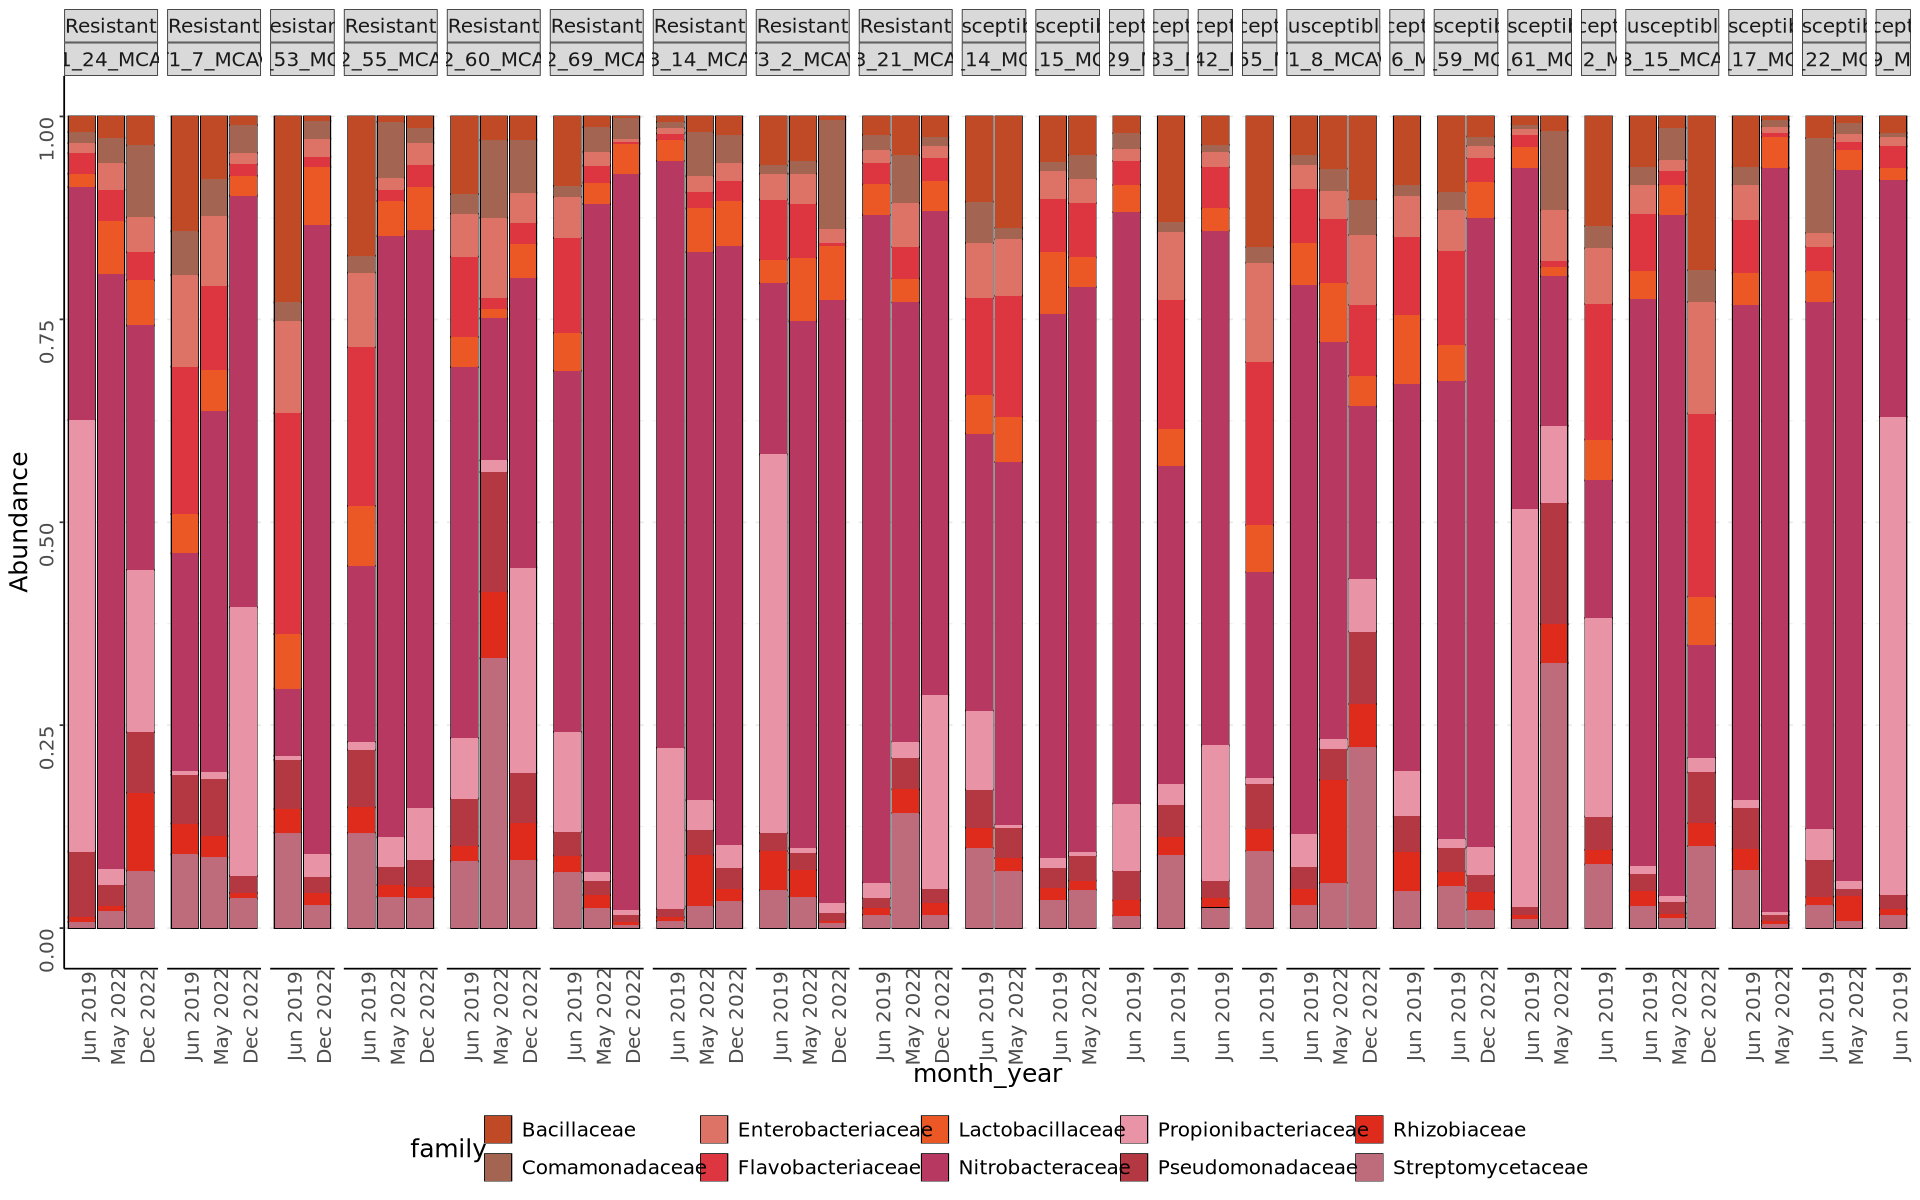

In [92]:
# top 10 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(mcav_10_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (family)

In [93]:
# repeat other spp 

#### PSTR --------------------------------------------------------------------------------

In [94]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [95]:
# looking just at PSTR, remove disease margin

subset_PSTR<- subset_samples(sctld_raw, (Species == "PSTR" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_PSTR<- subset_samples(subset_PSTR, (!(Date_InitialTag %in% dec_tags)))

# top 100 family
PSTR_100 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:100]), subset_PSTR)
PSTR_100_norm <- transform_sample_counts(PSTR_100, function(x) x / sum(x))
# top 30 family
PSTR_30 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:30]), subset_PSTR)
PSTR_30_norm <- transform_sample_counts(PSTR_30, function(x) x / sum(x))
# top 10 family
PSTR_10 = prune_taxa(names(sort(taxa_sums(subset_PSTR),TRUE)[1:10]), subset_PSTR)
PSTR_10_norm <- transform_sample_counts(PSTR_10, function(x) x / sum(x))

In [96]:
df_meta <- data.frame(sample_data(subset_PSTR))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PSTR) <- sample_data(df_meta)

In [97]:
# reorder colonies
PSTR_g_S<-subset_samples(subset_PSTR, RS == "Susceptible")
df_meta<-data.frame(sample_data(PSTR_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(PSTR_g_S)$colony_id <-
  factor(sample_data(PSTR_g_S)$colony_id, levels = col_order)

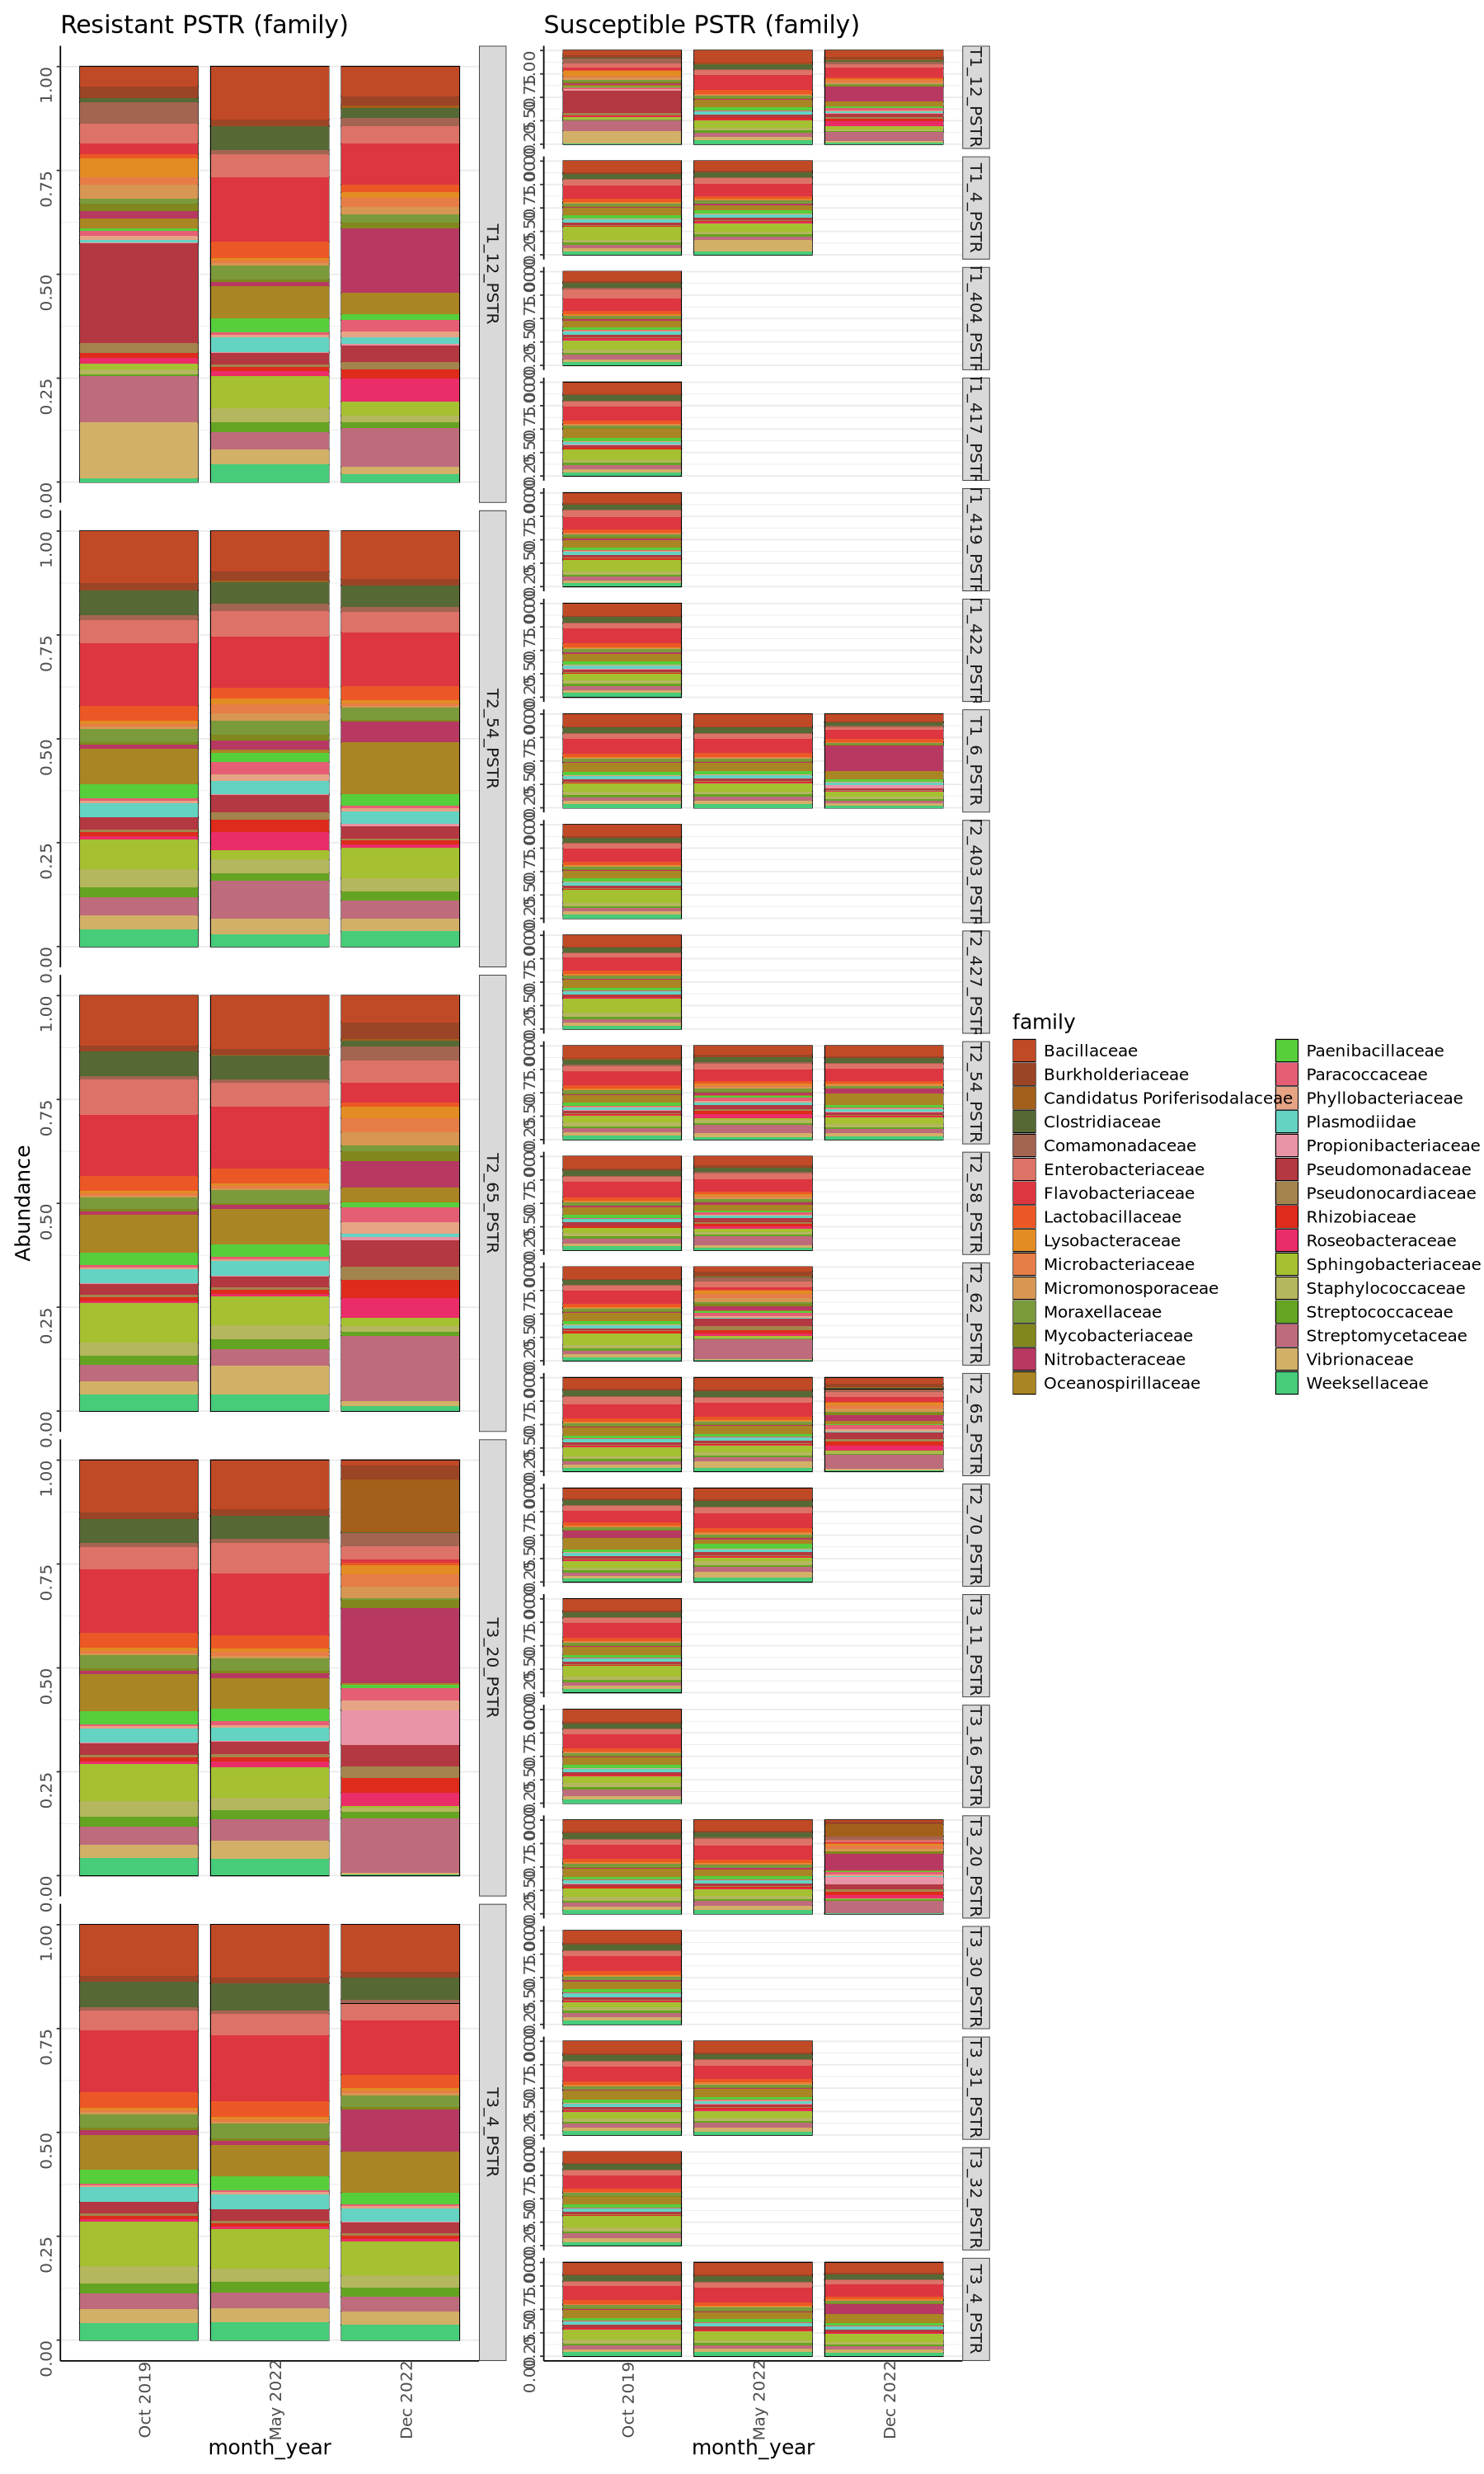

In [98]:
options(repr.plot.height = 25, repr.plot.width = 15)
p_R <- plot_bar(subset_samples(PSTR_30_norm, RS == "Resistant"),x = "month_year", fill = "family")+
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Resistant PSTR (family)")
p_S <- plot_bar(PSTR_30_norm,x = "month_year", fill = "family") +
    facet_grid(colony_id ~ .)+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position = "none",panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))+
    labs(title = "Susceptible PSTR (family)", y = NULL)
p_R | p_S +
  plot_layout(guides = "collect") +
  # plot_annotation(title = "Microbiome composition through time",subtitle = "PSTR colonies") &
  theme(legend.position = "right")
# top 30 family

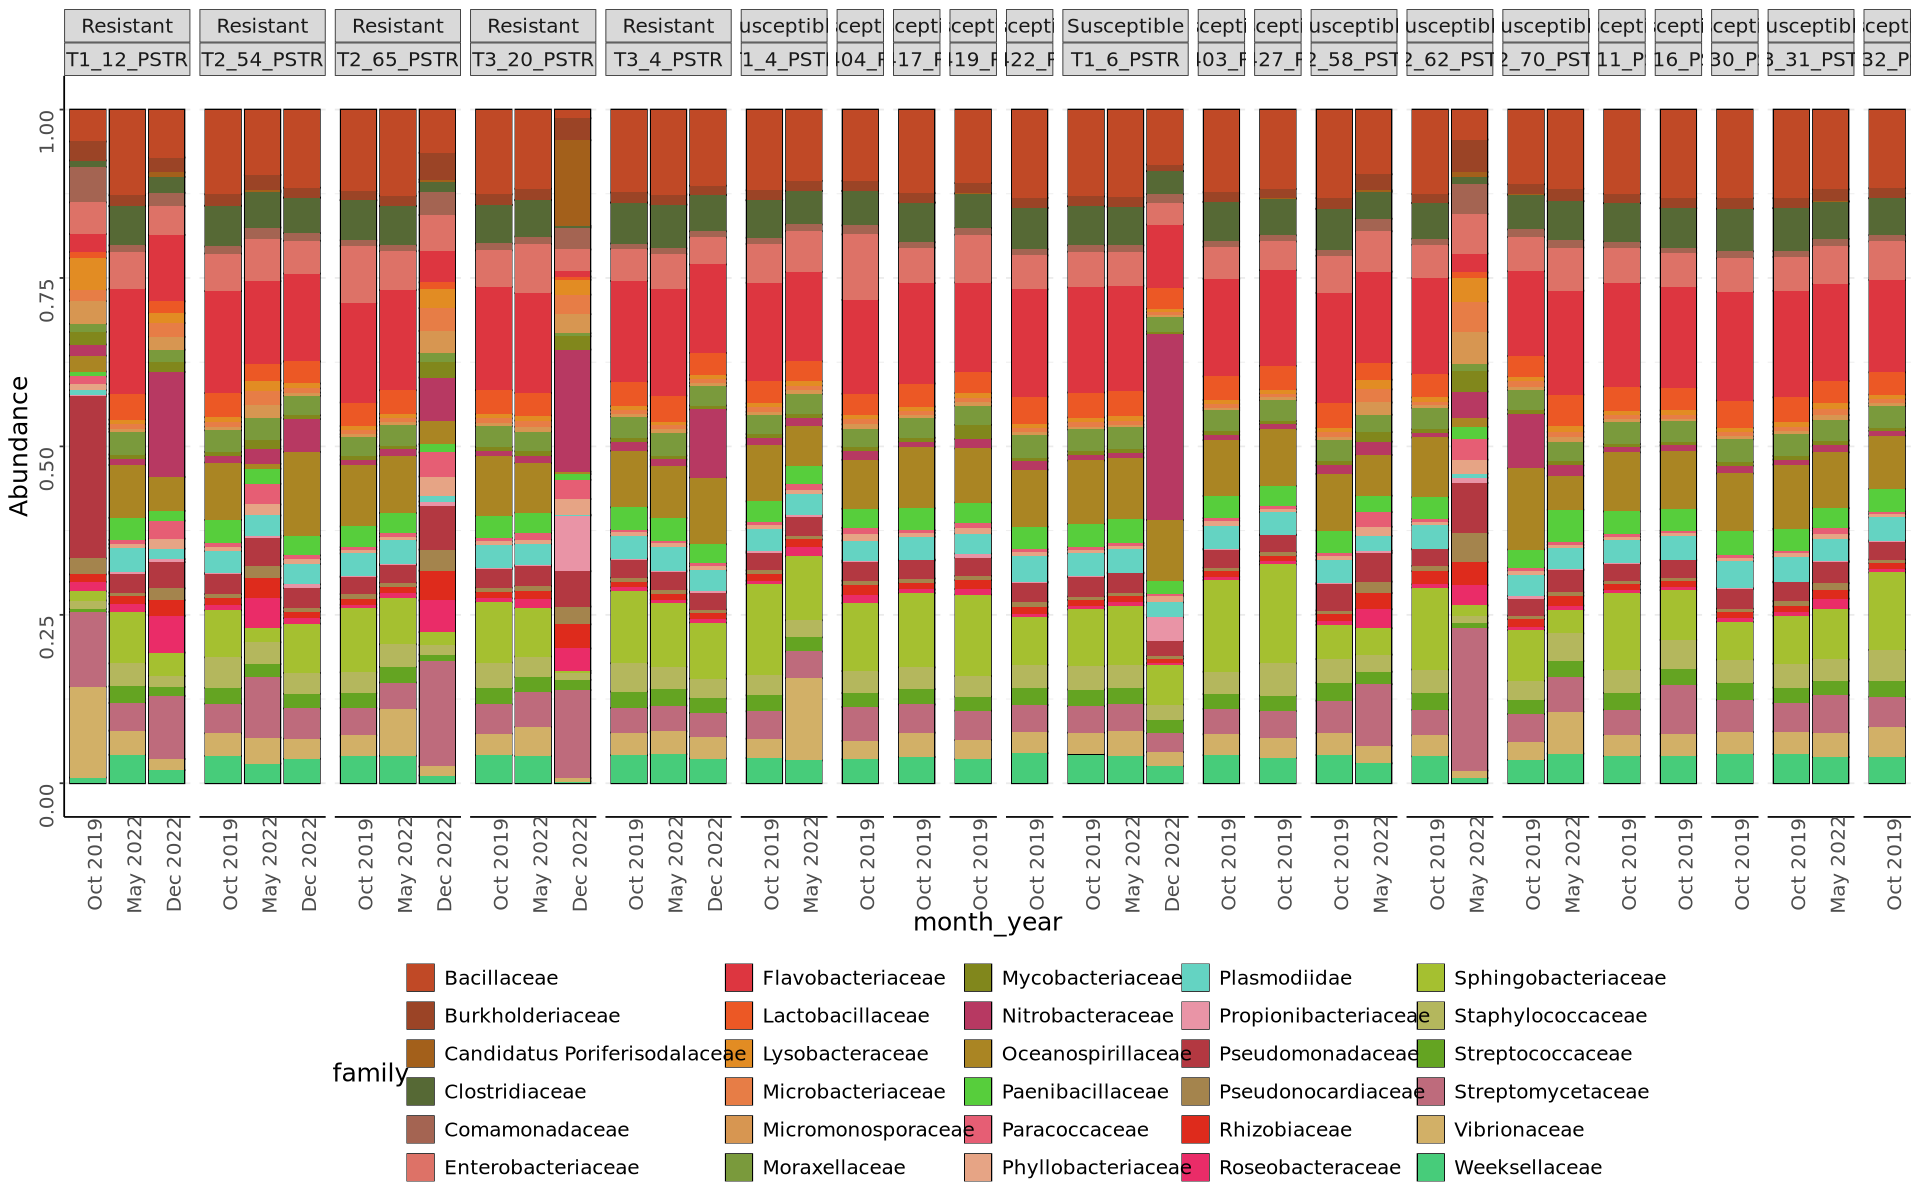

In [99]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_30_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 family - R vs S. individuals over time 

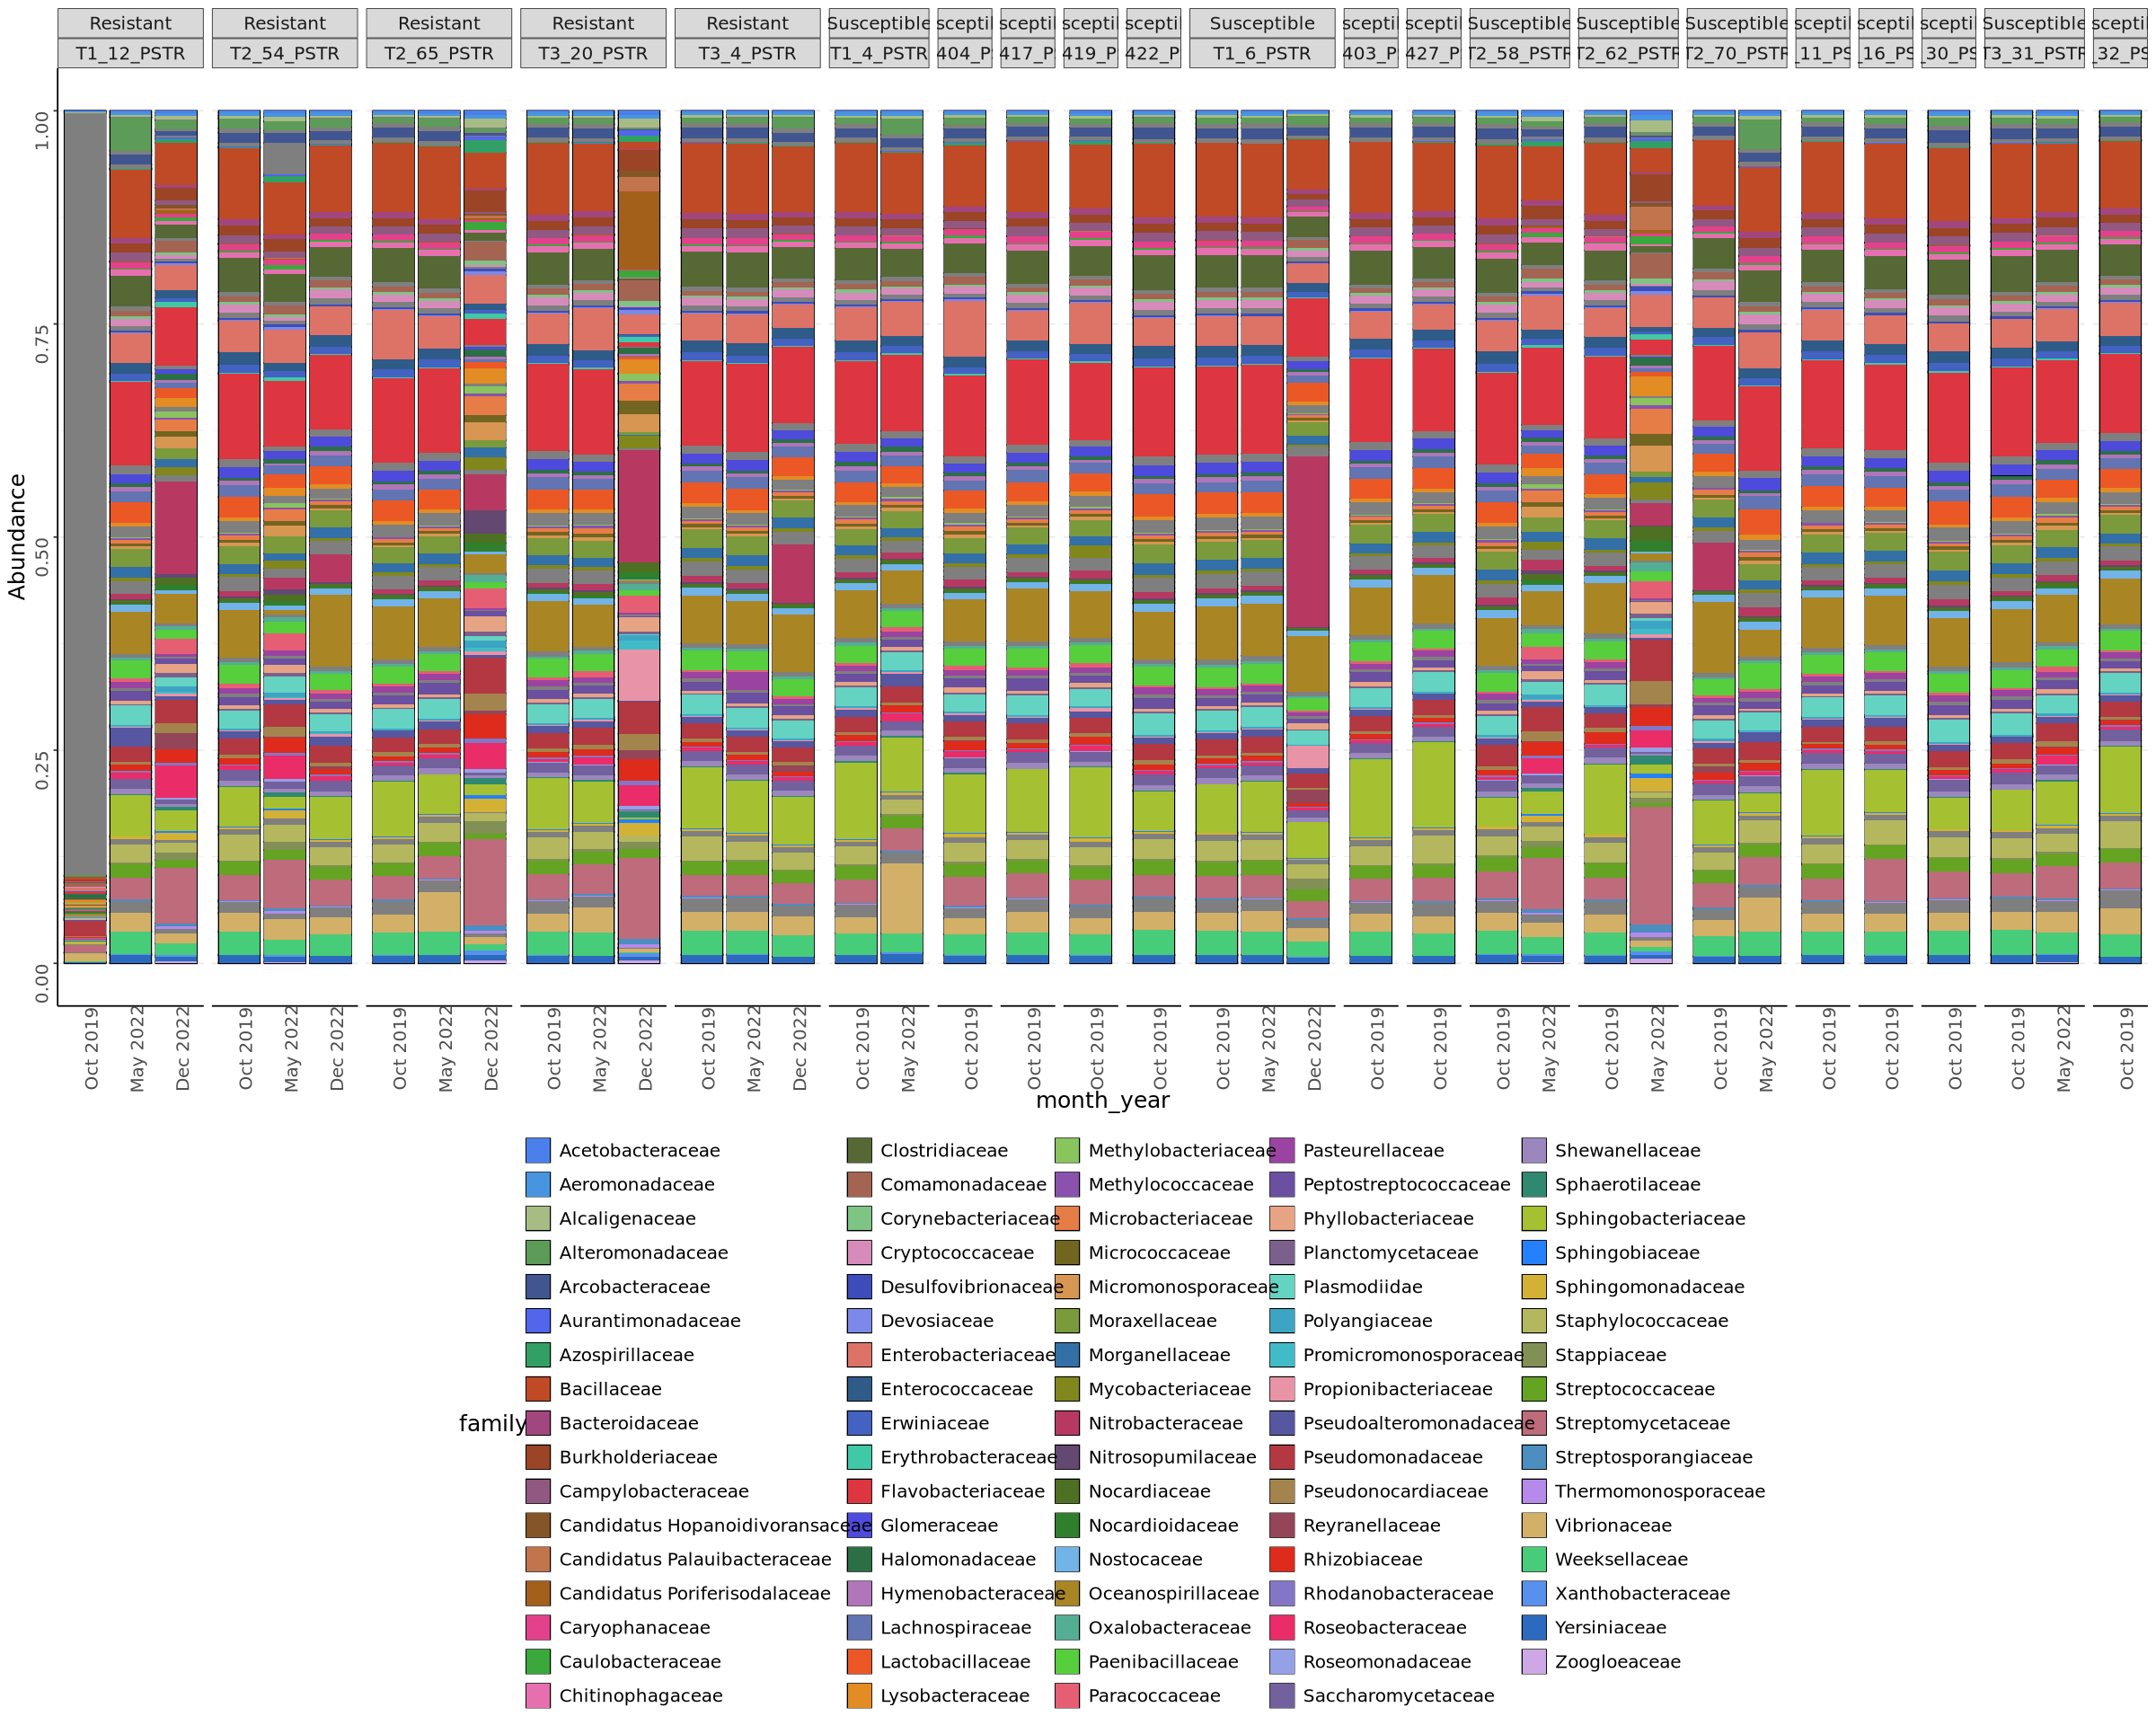

In [100]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PSTR_100_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (family)

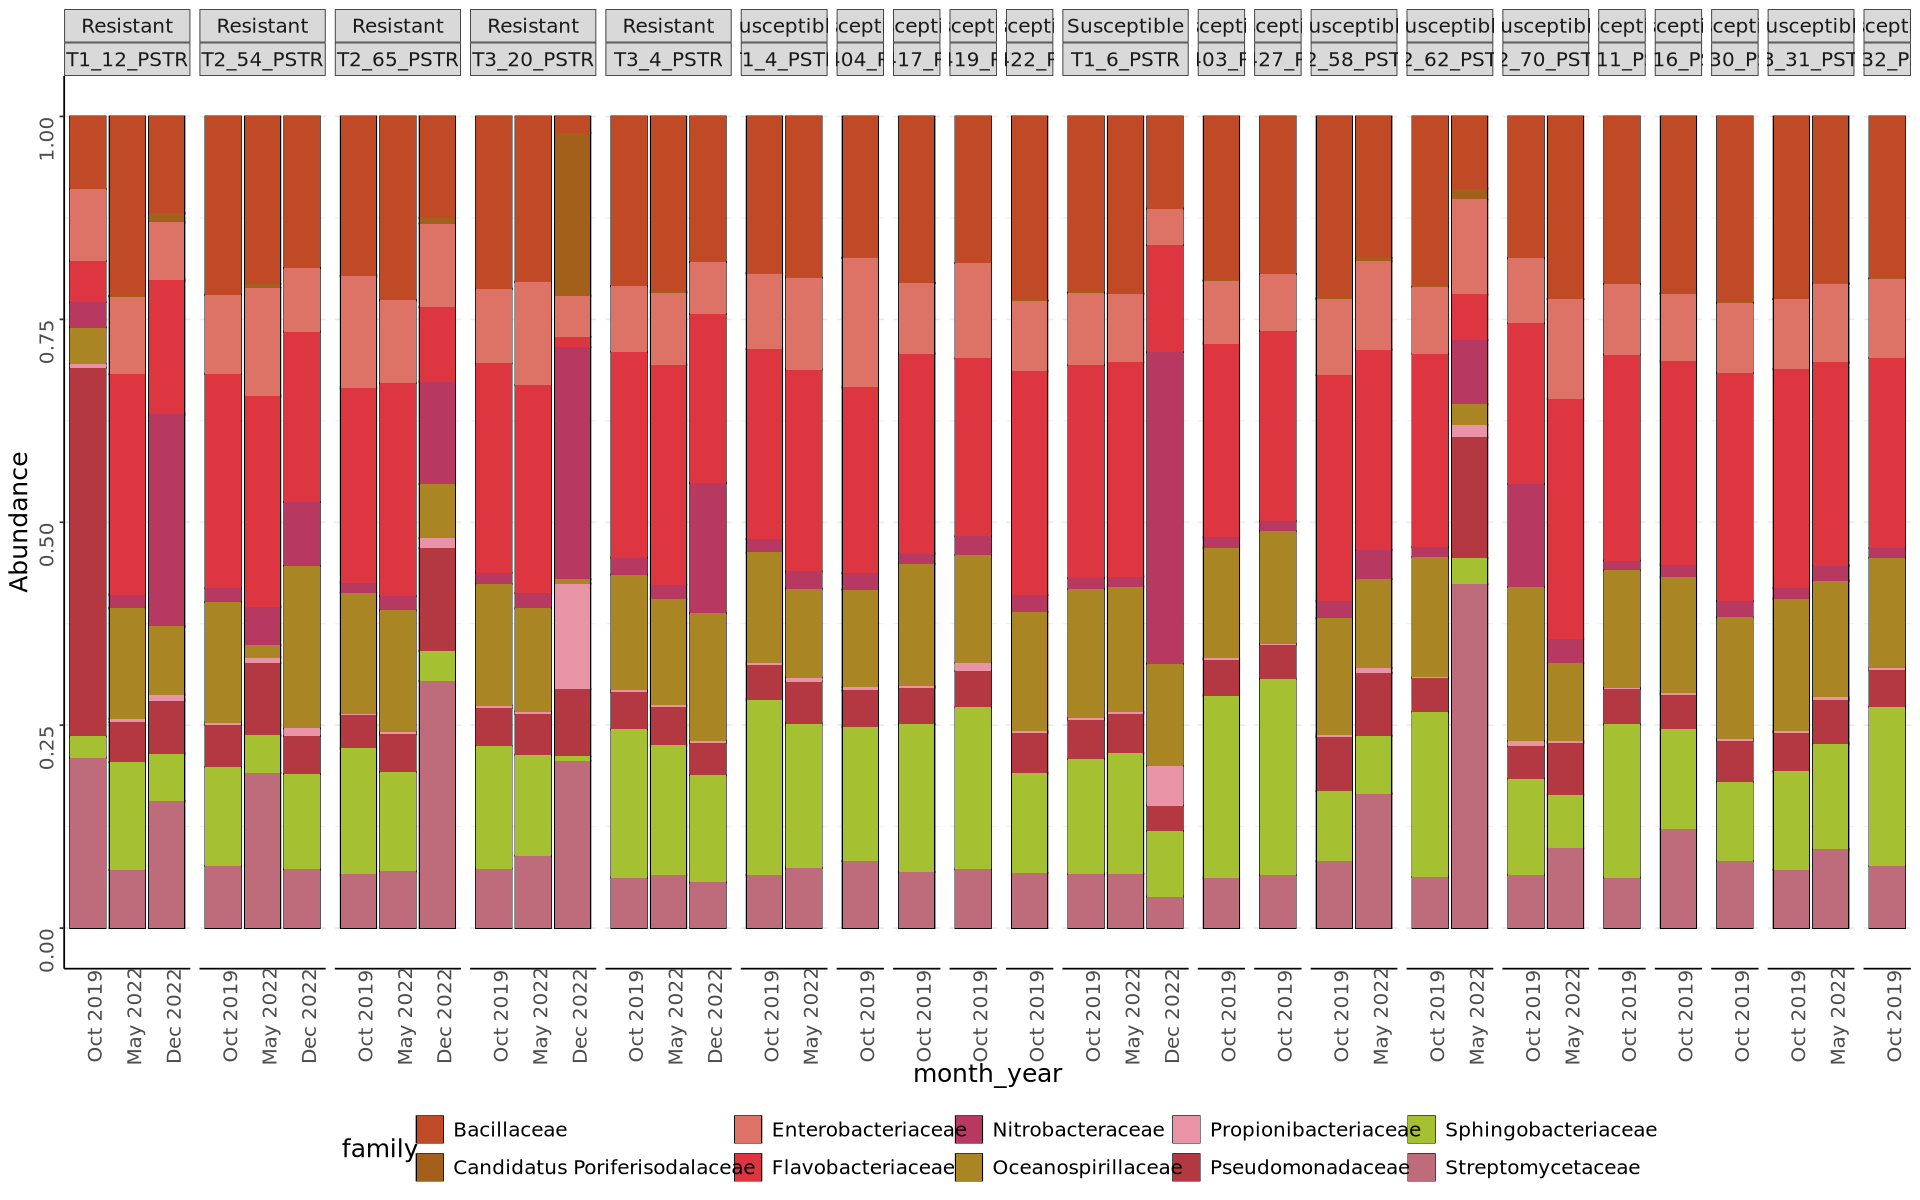

In [101]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PSTR_10_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (family)

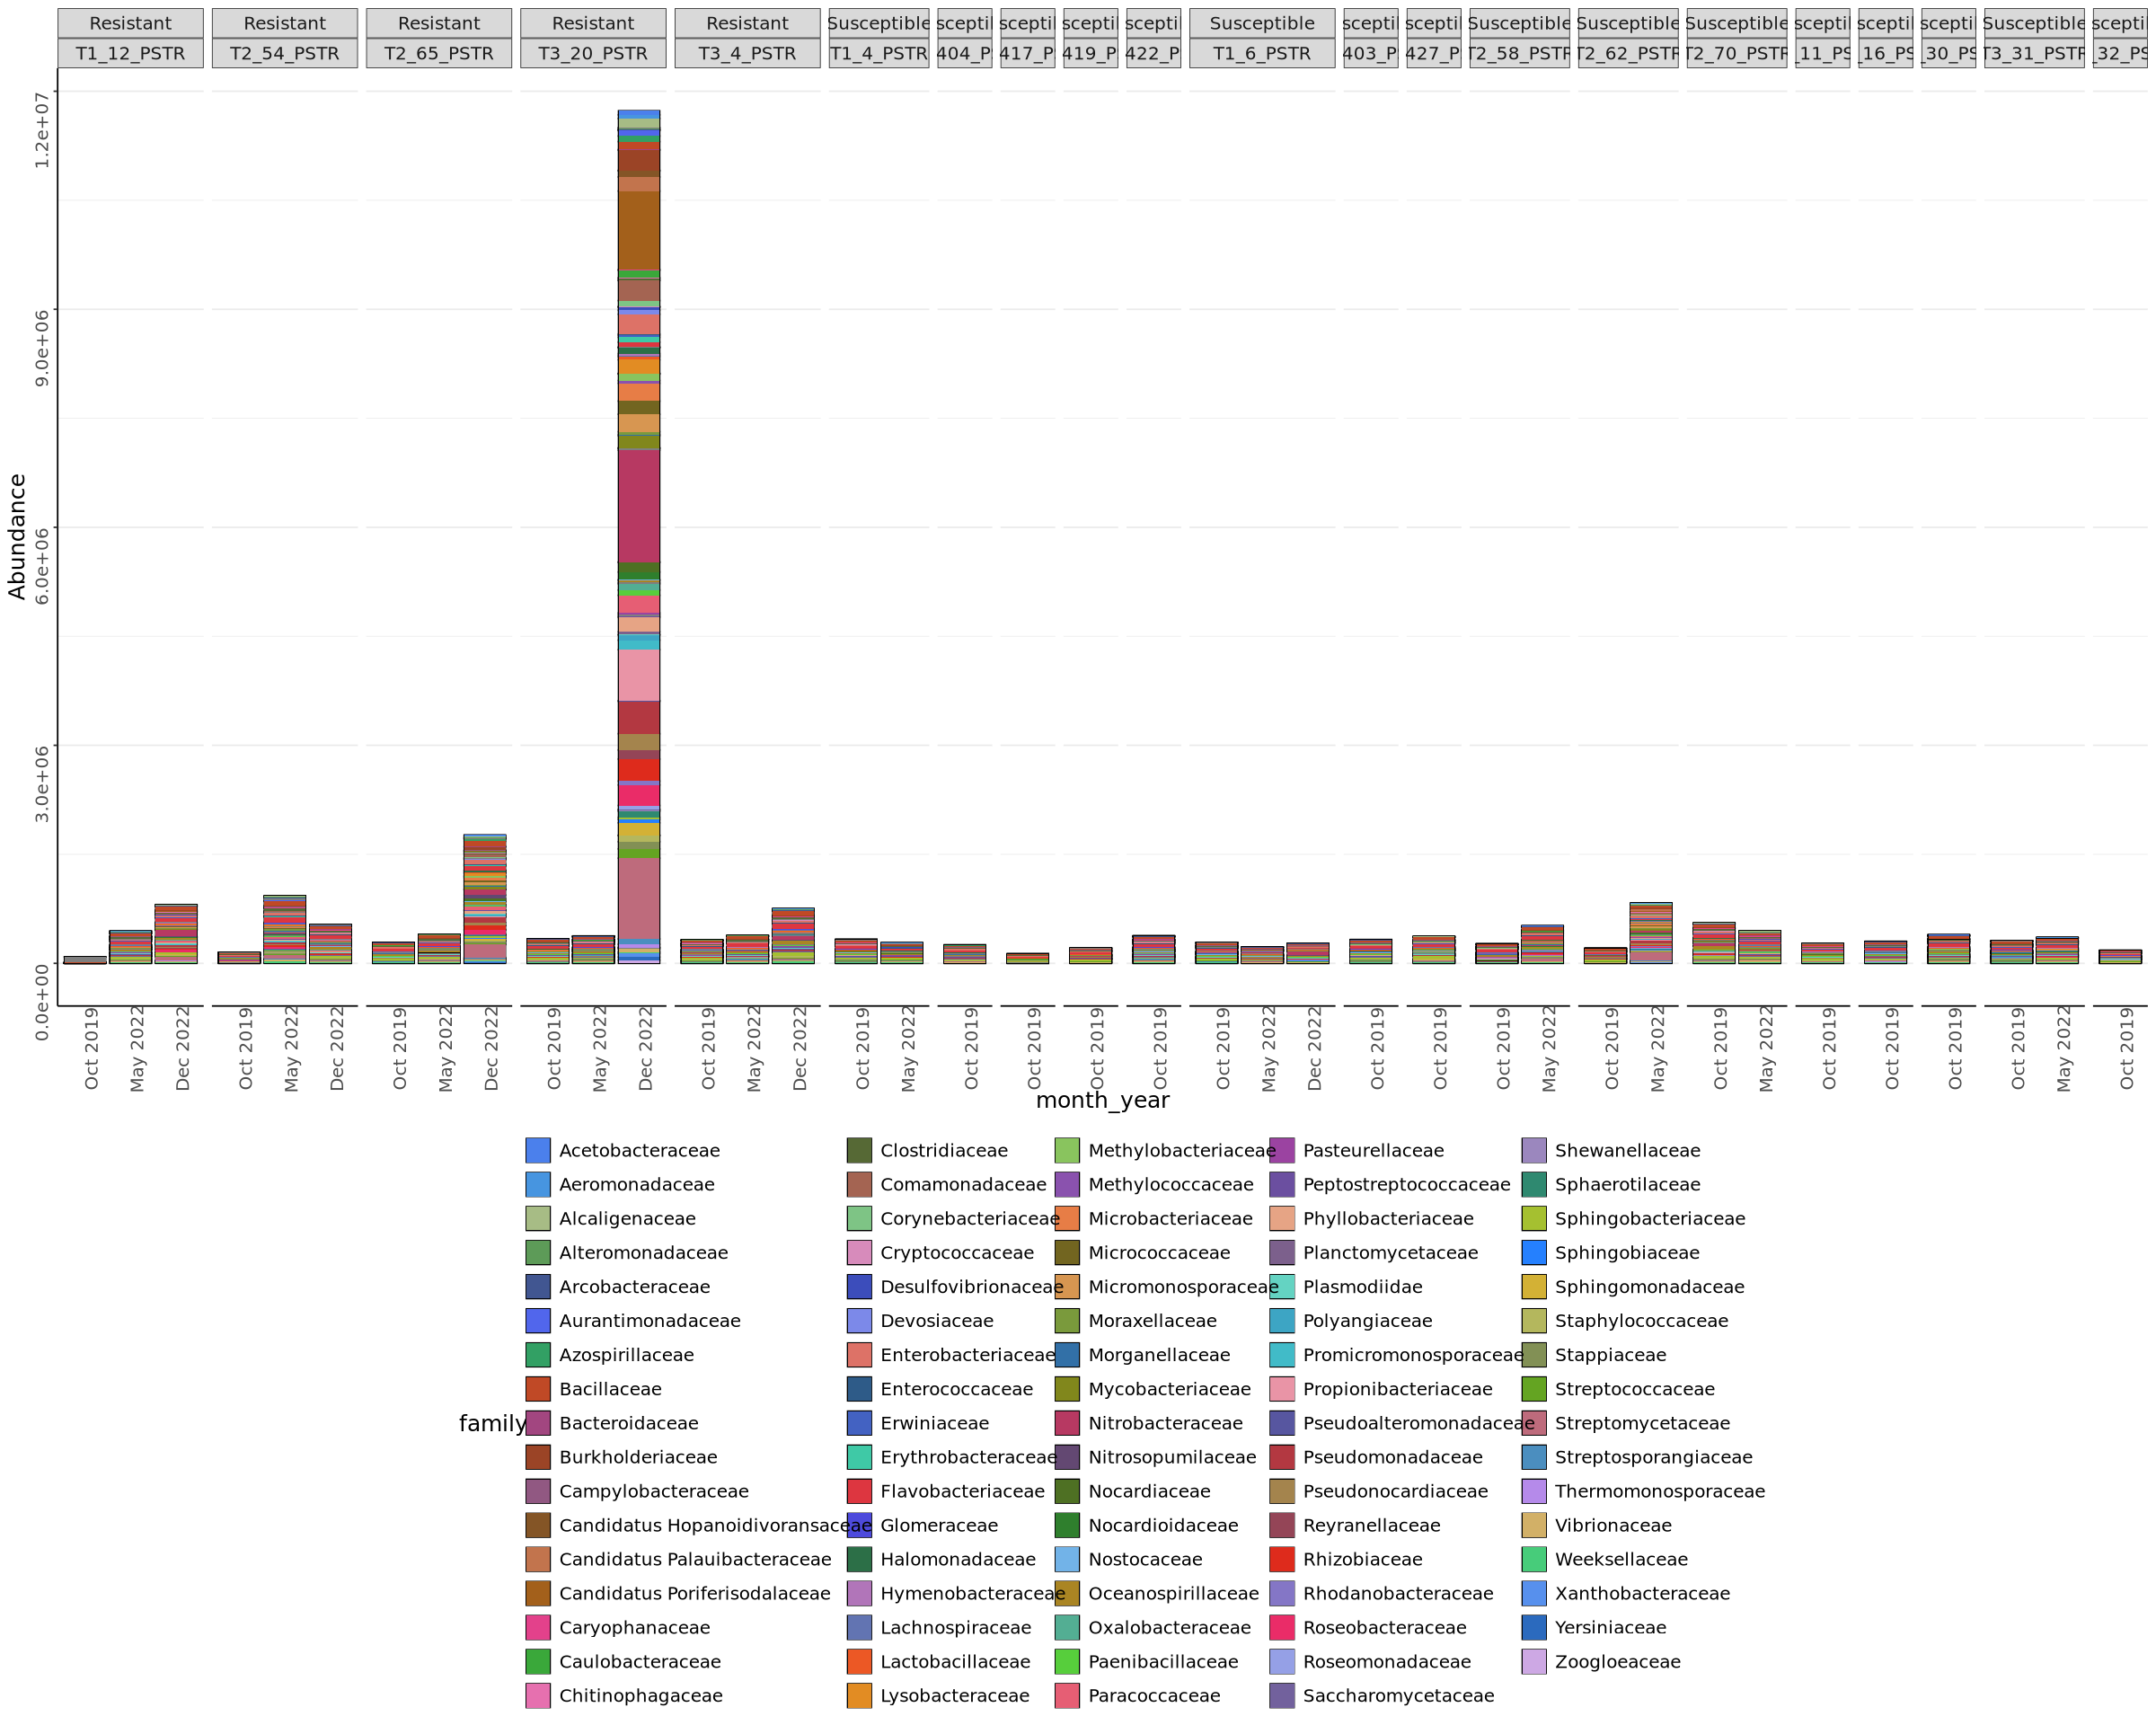

In [102]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PSTR_100,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 100 OTUs (family)

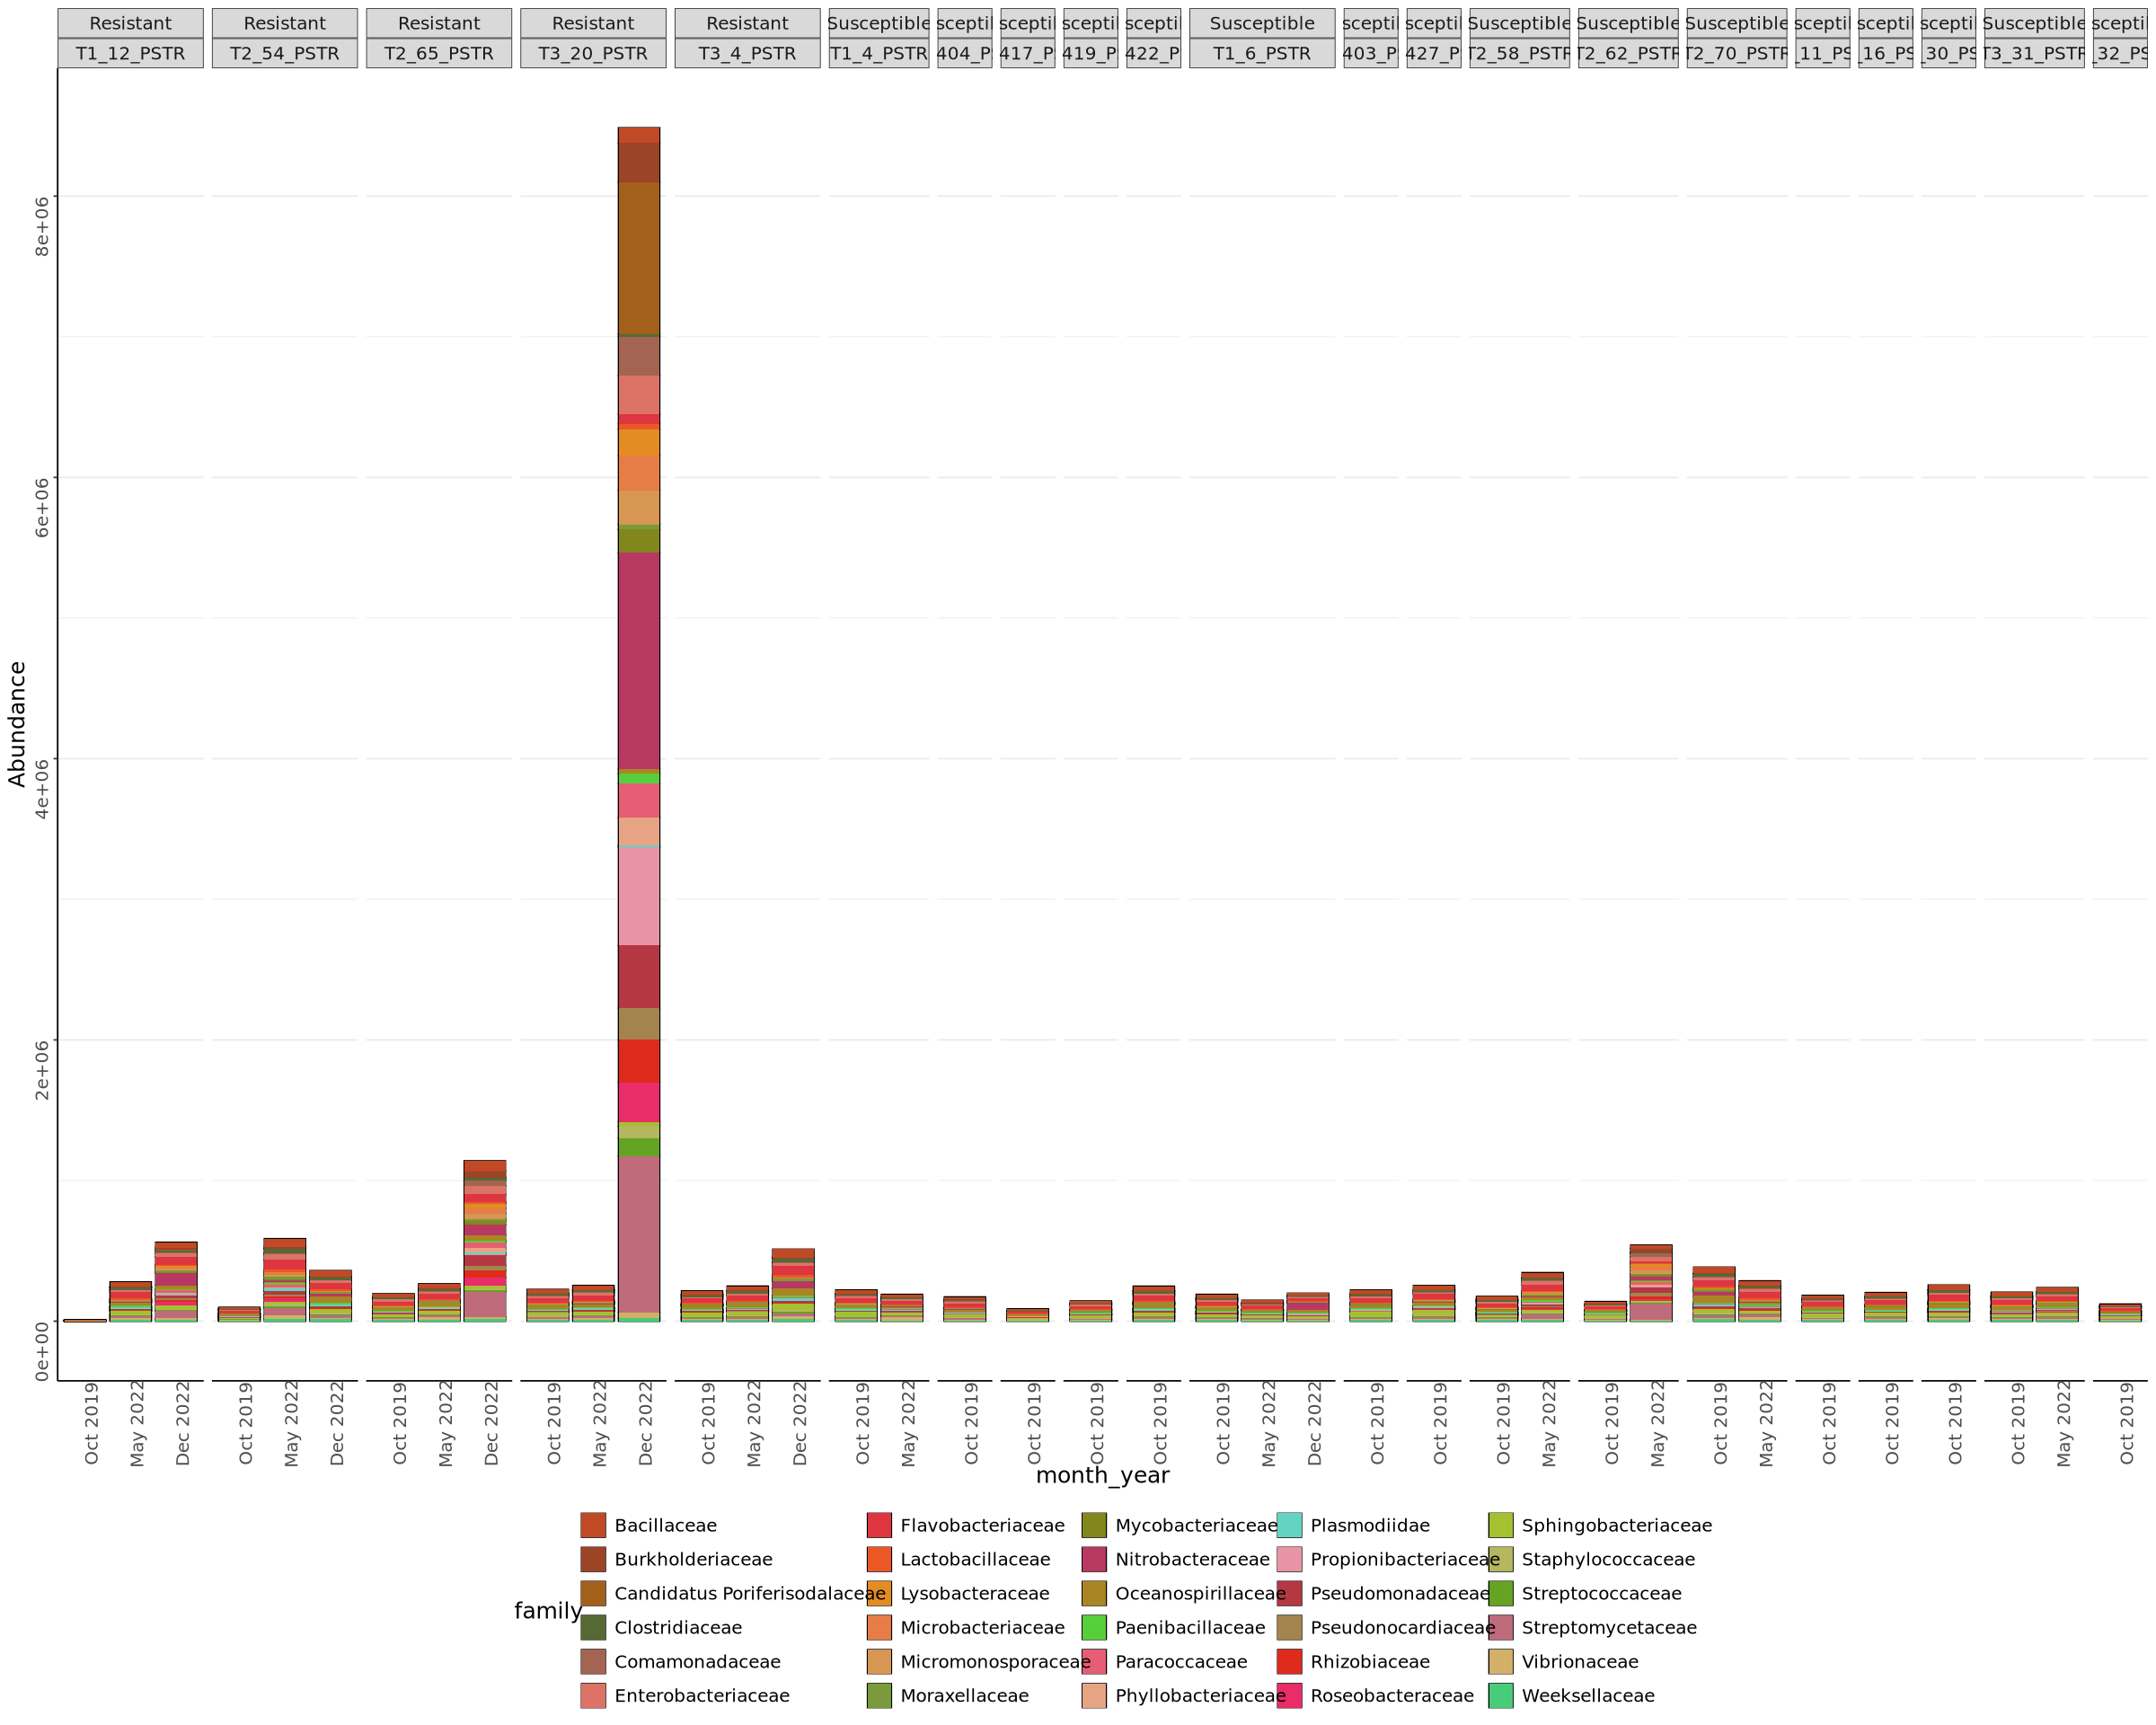

In [103]:

p<-plot_bar(PSTR_30,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 30 OTUs (family)

#### MMEA --------------------------------------------------------------------------------

In [104]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [105]:
# mmea

subset_MMEA<- subset_samples(sctld_raw, (Species == "MMEA"))

# top 100 species
MMEA_100 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:100]), subset_MMEA)
MMEA_100_norm <- transform_sample_counts(MMEA_100, function(x) x / sum(x))

MMEA_30 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:30]), subset_MMEA)
MMEA_30_norm <- transform_sample_counts(MMEA_30, function(x) x / sum(x))

# top 10 family
MMEA_10 = prune_taxa(names(sort(taxa_sums(subset_MMEA),TRUE)[1:10]), subset_MMEA)
MMEA_10_norm <- transform_sample_counts(MMEA_10, function(x) x / sum(x))

In [106]:
df_meta <- data.frame(sample_data(subset_MMEA))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_MMEA) <- sample_data(df_meta)

In [107]:
# reorder colonies
MMEA_g_S<-subset_samples(subset_MMEA, RS == "Susceptible")
df_meta<-data.frame(sample_data(MMEA_g_S))
# make order for X122022_Condition
df_meta <- df_meta %>% 
    mutate(X122022_Condition = factor(X122022_Condition, levels = c('Healthy','Diseased','Dead','Not_Visited'))) %>%
    arrange(colony_id, X122022_Condition)
# reorder colonies by condition factor levels
col_order <- df_meta %>%
  distinct(colony_id, X122022_Condition) %>%
  arrange(X122022_Condition, colony_id) %>%
  pull(colony_id)

sample_data(subset_MMEA)$colony_id <-
  factor(sample_data(subset_MMEA)$colony_id, levels = col_order)

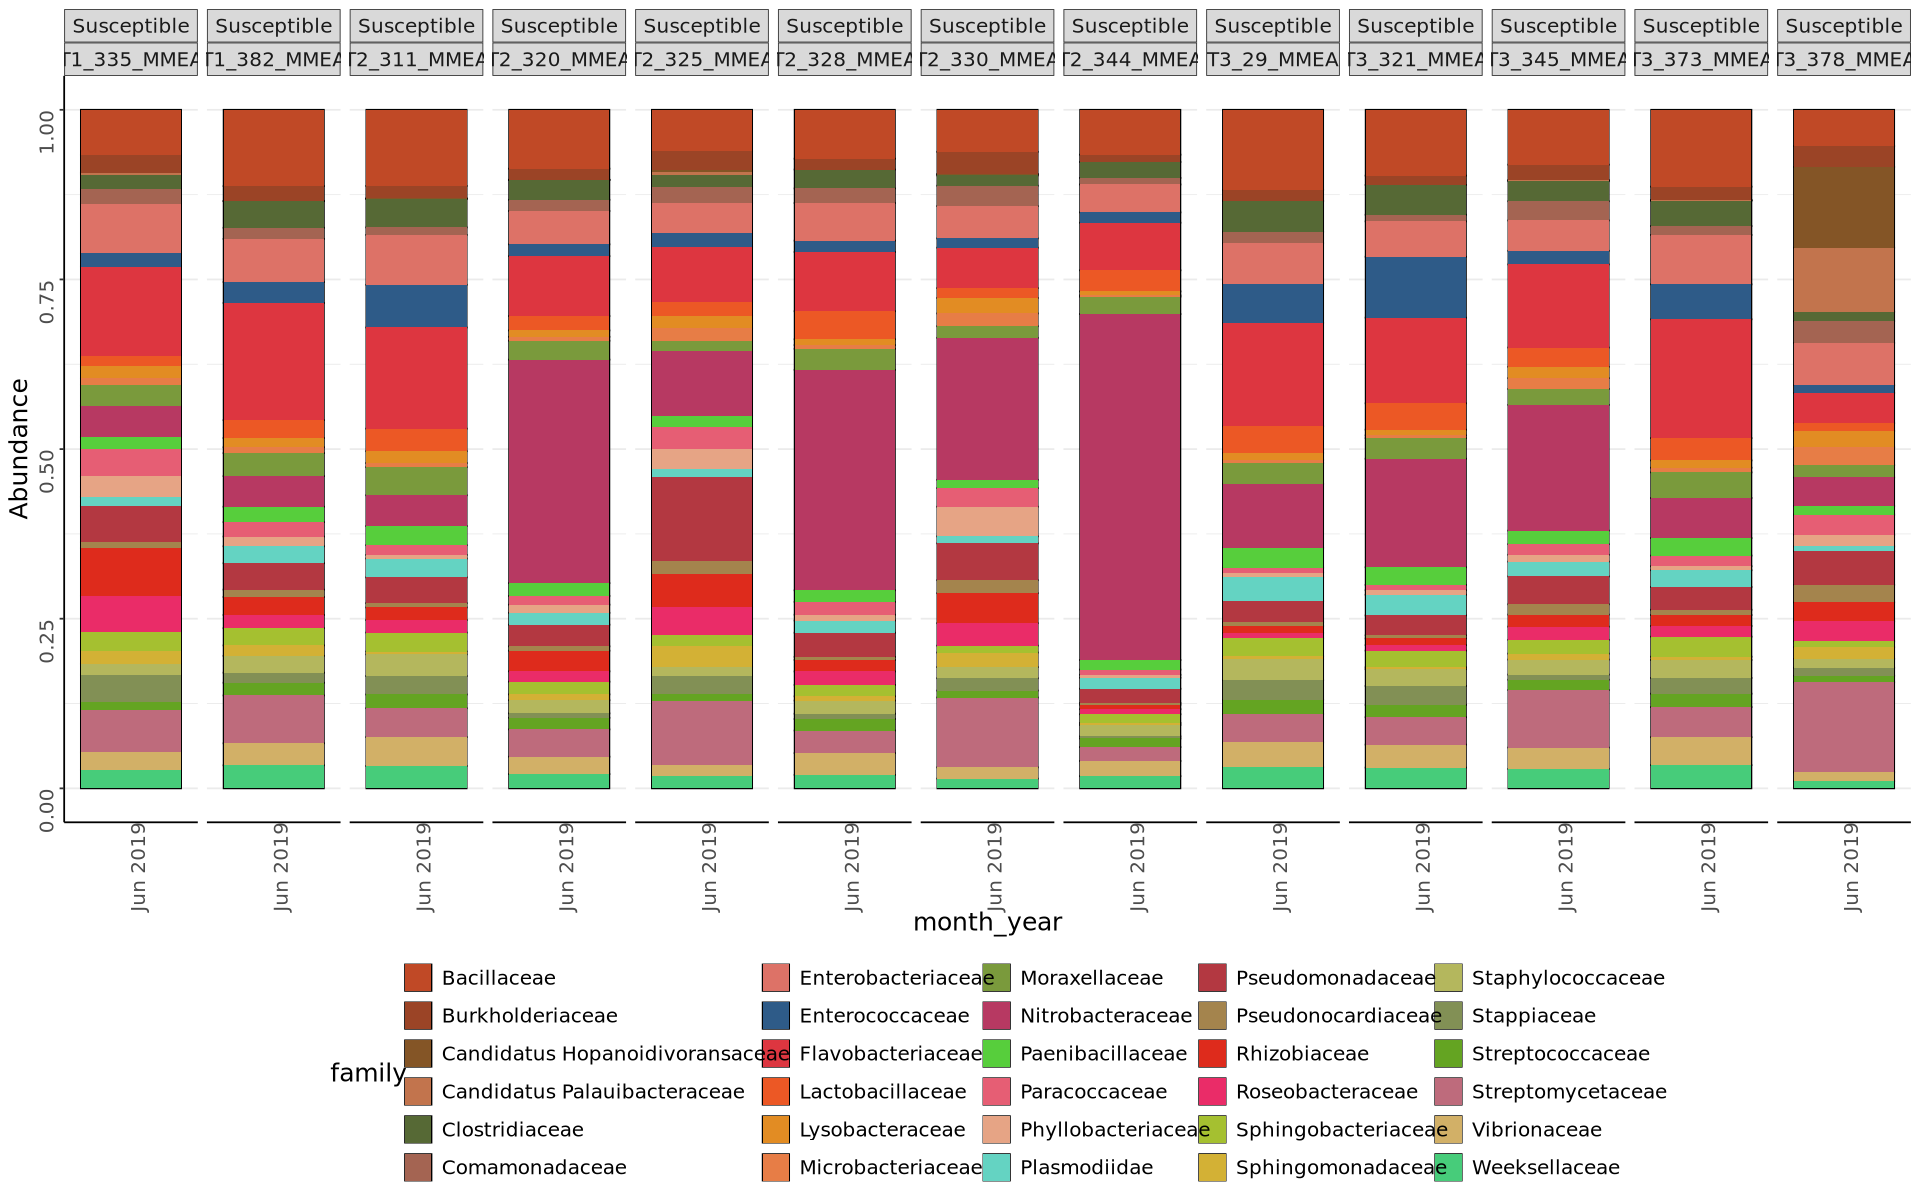

In [108]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(MMEA_30_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 family - R vs S. individuals over time 

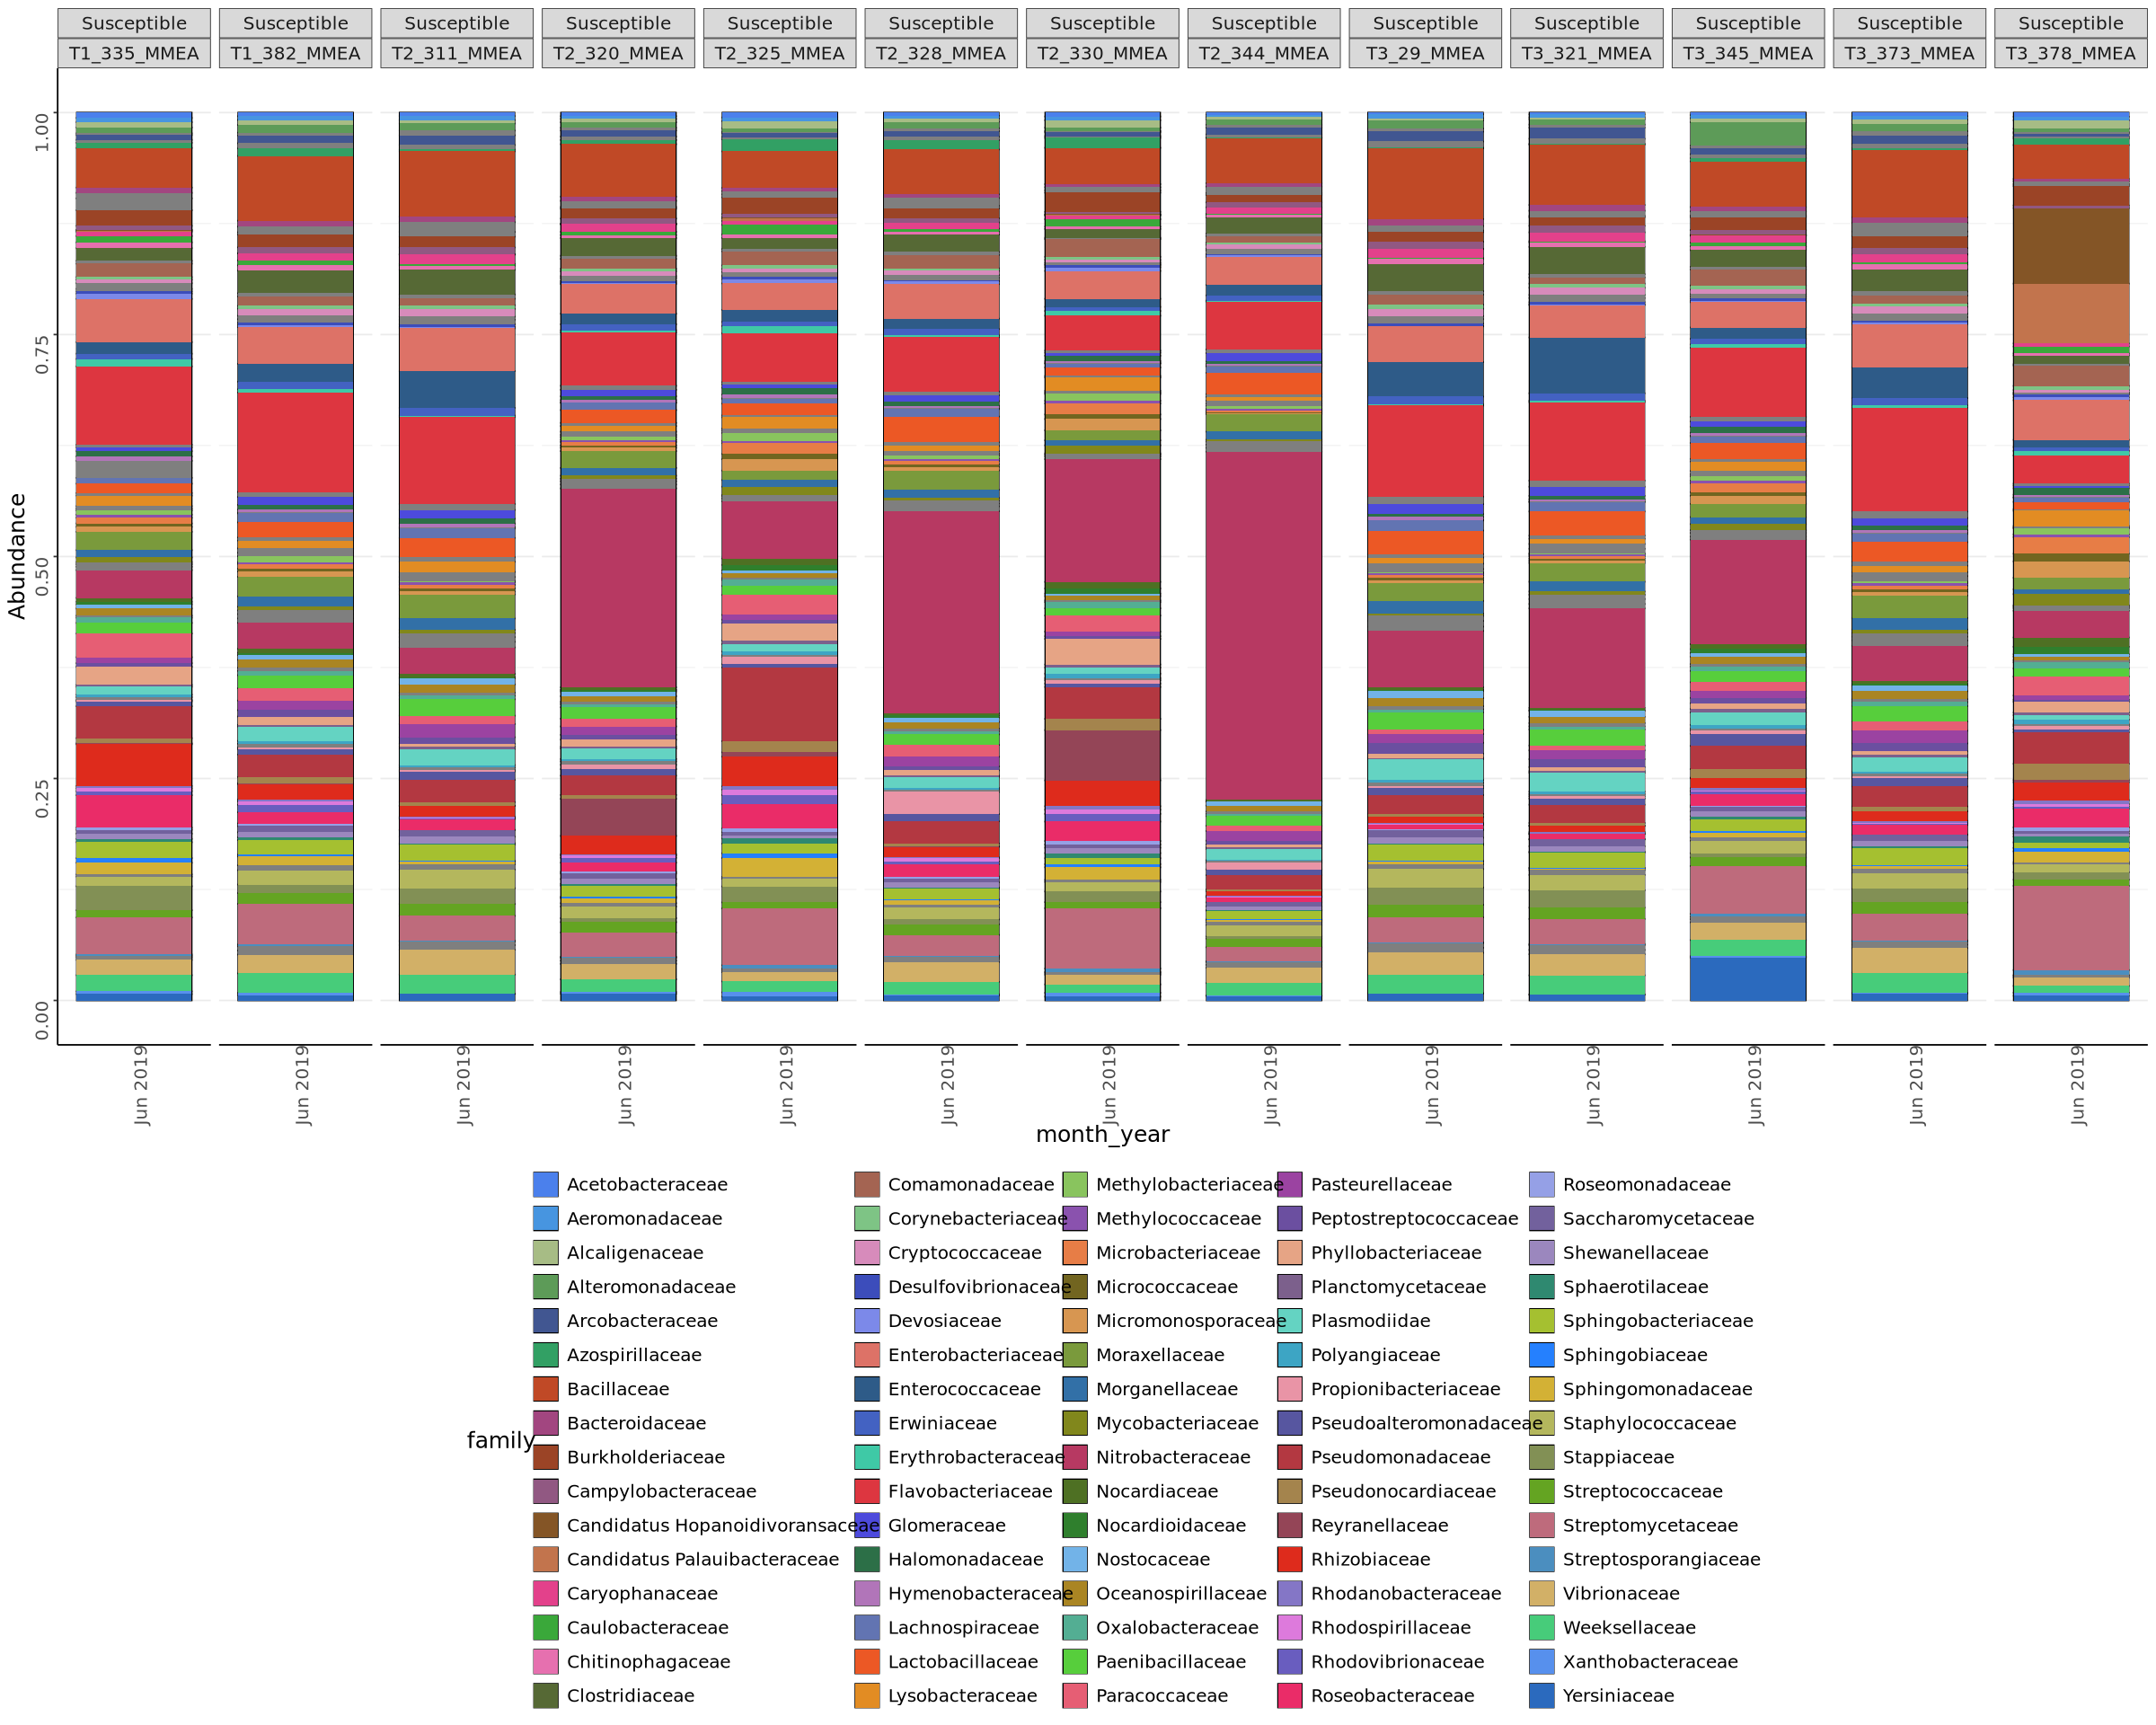

In [109]:
options(repr.plot.height = 16, repr.plot.width = 20)

p<-plot_bar(MMEA_100_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (family)

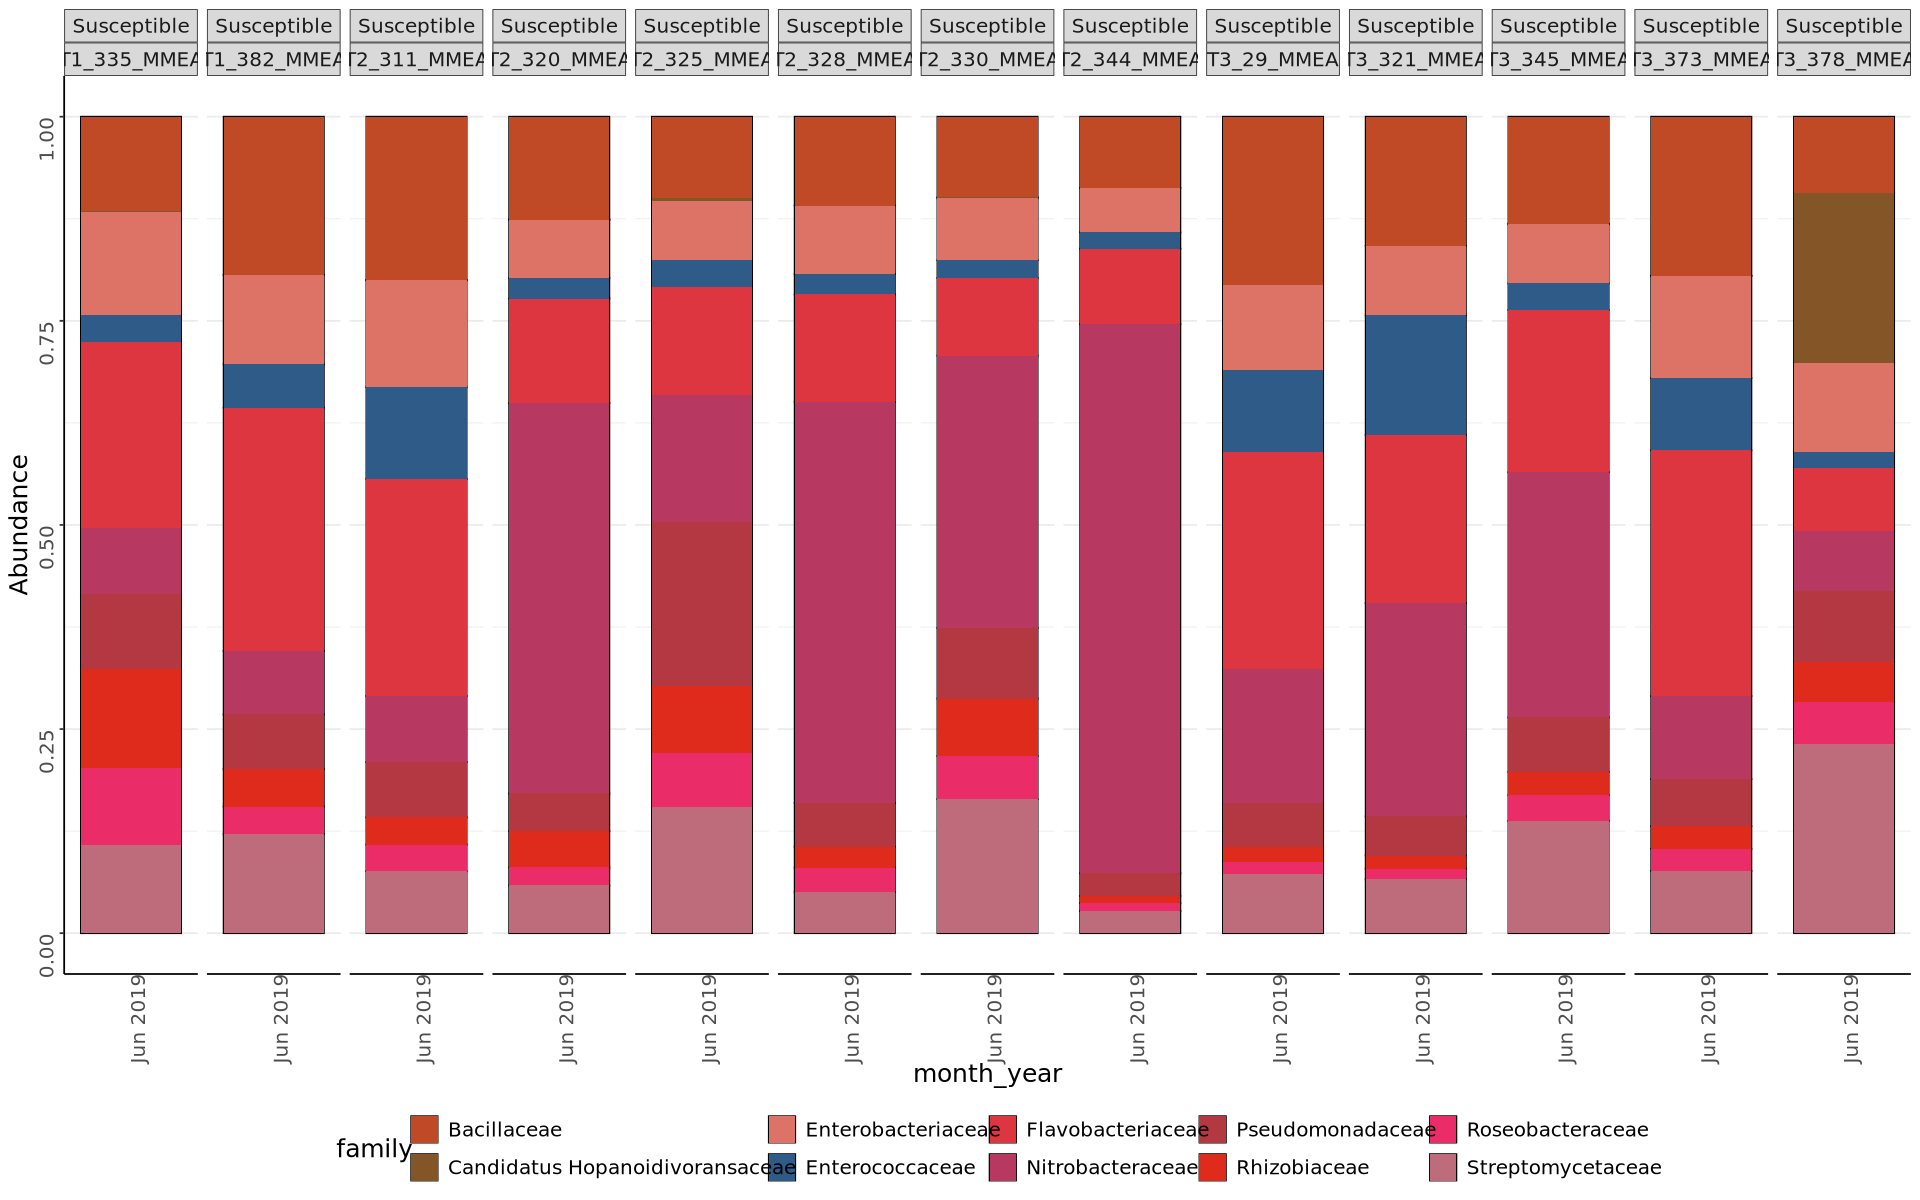

In [110]:
# top 30 species
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(MMEA_10_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (family)

#### PAST --------------------------------------------------------------------------------

In [111]:
options(repr.plot.height = 13, repr.plot.width = 18)

In [112]:
# looking just at PAST, remove disease margin

subset_PAST<- subset_samples(sctld_raw, (Species == "PAST" & Health_status != "Diseased_Margin"))
# and remove newly tagged colonies in 2022 
dec_tags<-c('12/03/22','12/05/22')
subset_PAST<- subset_samples(subset_PAST, (!(Date_InitialTag %in% dec_tags)))

# top 100 species
PAST_100 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:100]), subset_PAST)
PAST_100_norm <- transform_sample_counts(PAST_100, function(x) x / sum(x))

PAST_30 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:30]), subset_PAST)
PAST_30_norm <- transform_sample_counts(PAST_30, function(x) x / sum(x))

PAST_10 = prune_taxa(names(sort(taxa_sums(subset_PAST),TRUE)[1:10]), subset_PAST)
PAST_10_norm <- transform_sample_counts(PAST_10, function(x) x / sum(x))

In [113]:
df_meta <- data.frame(sample_data(subset_PAST))

# 2. Re-level Sample IDs based on month_year order
df_meta <- df_meta %>% 
  arrange(colony_id,month_year) %>% 
  mutate(sampleid = factor(sampleid, levels = unique(sampleid)))

# 3. Update sample_data in your phyloseq object
sample_data(subset_PAST) <- sample_data(df_meta)

In [114]:
# "resistant" colonies that don't have 2022 data 
colony %>%
    filter(colony_id == "T2_47_PAST" | colony_id == "T3_13_PAST") %>%
    select(colony_id, X122022_Condition, X092023_Condition, X012024_Condition, X042024_Condition)
# t3 13 was found again and sampled as healthy in 4/2024, looks like just missed the sample but we have healthy documented in 122022
# remove t2 47 - next sample in 6/2025 and I'm not convinced its the same colony 
# SUS T2 347 was Dead in 05/2022

colony_id,X122022_Condition,X092023_Condition,X012024_Condition,X042024_Condition
<chr>,<chr>,<chr>,<chr>,<chr>
T2_47_PAST,Not_Visited,Not_Visited,Not_Visited,Not_Visited
T3_13_PAST,Healthy,Not_Visited,CLB,Healthy


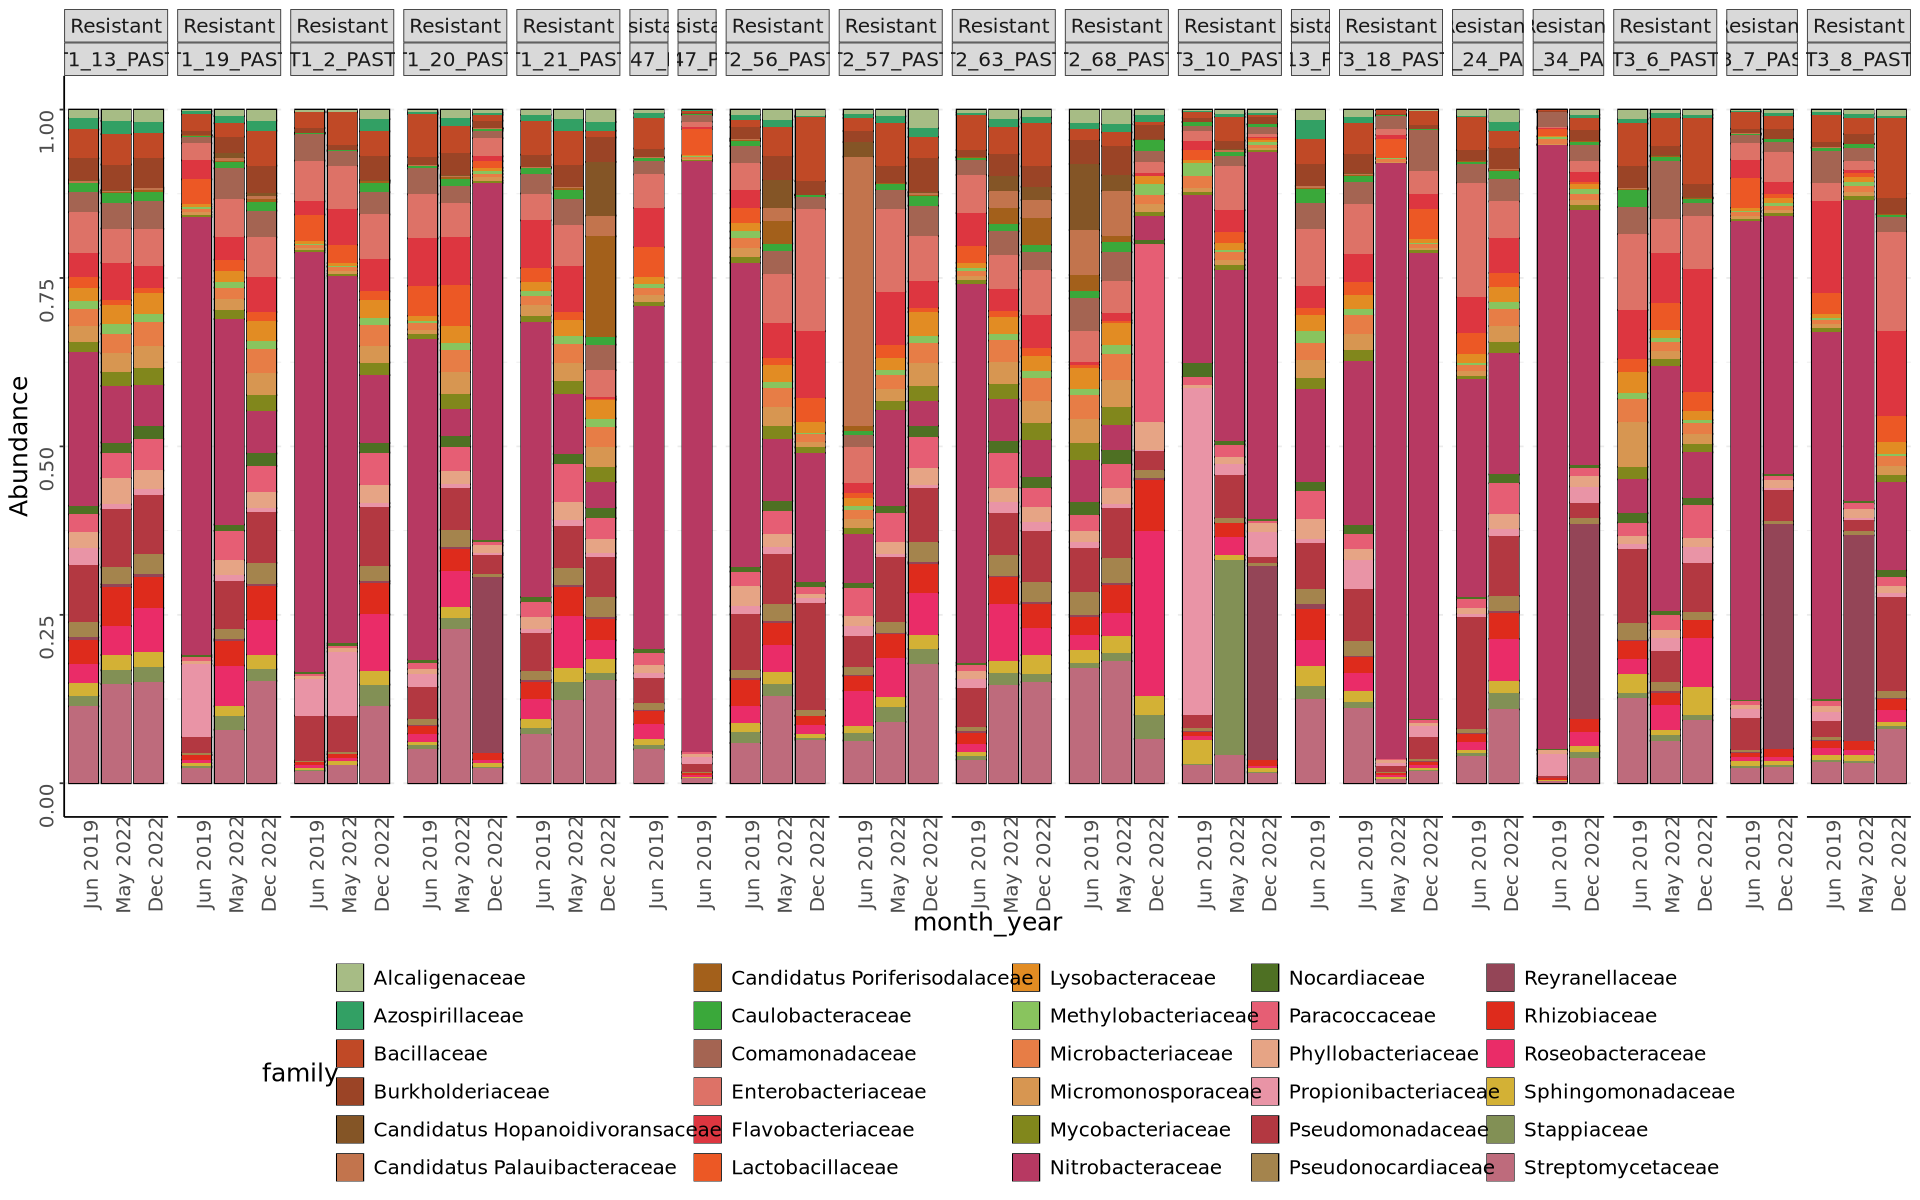

In [115]:
# want: single colony over time, facet by r vs s instead? 
# tried to use ggh4x:facet_nested but am getting weird error: could not find function "is_theme_element"
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PAST_30_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 30 family - R vs S. individuals over time 

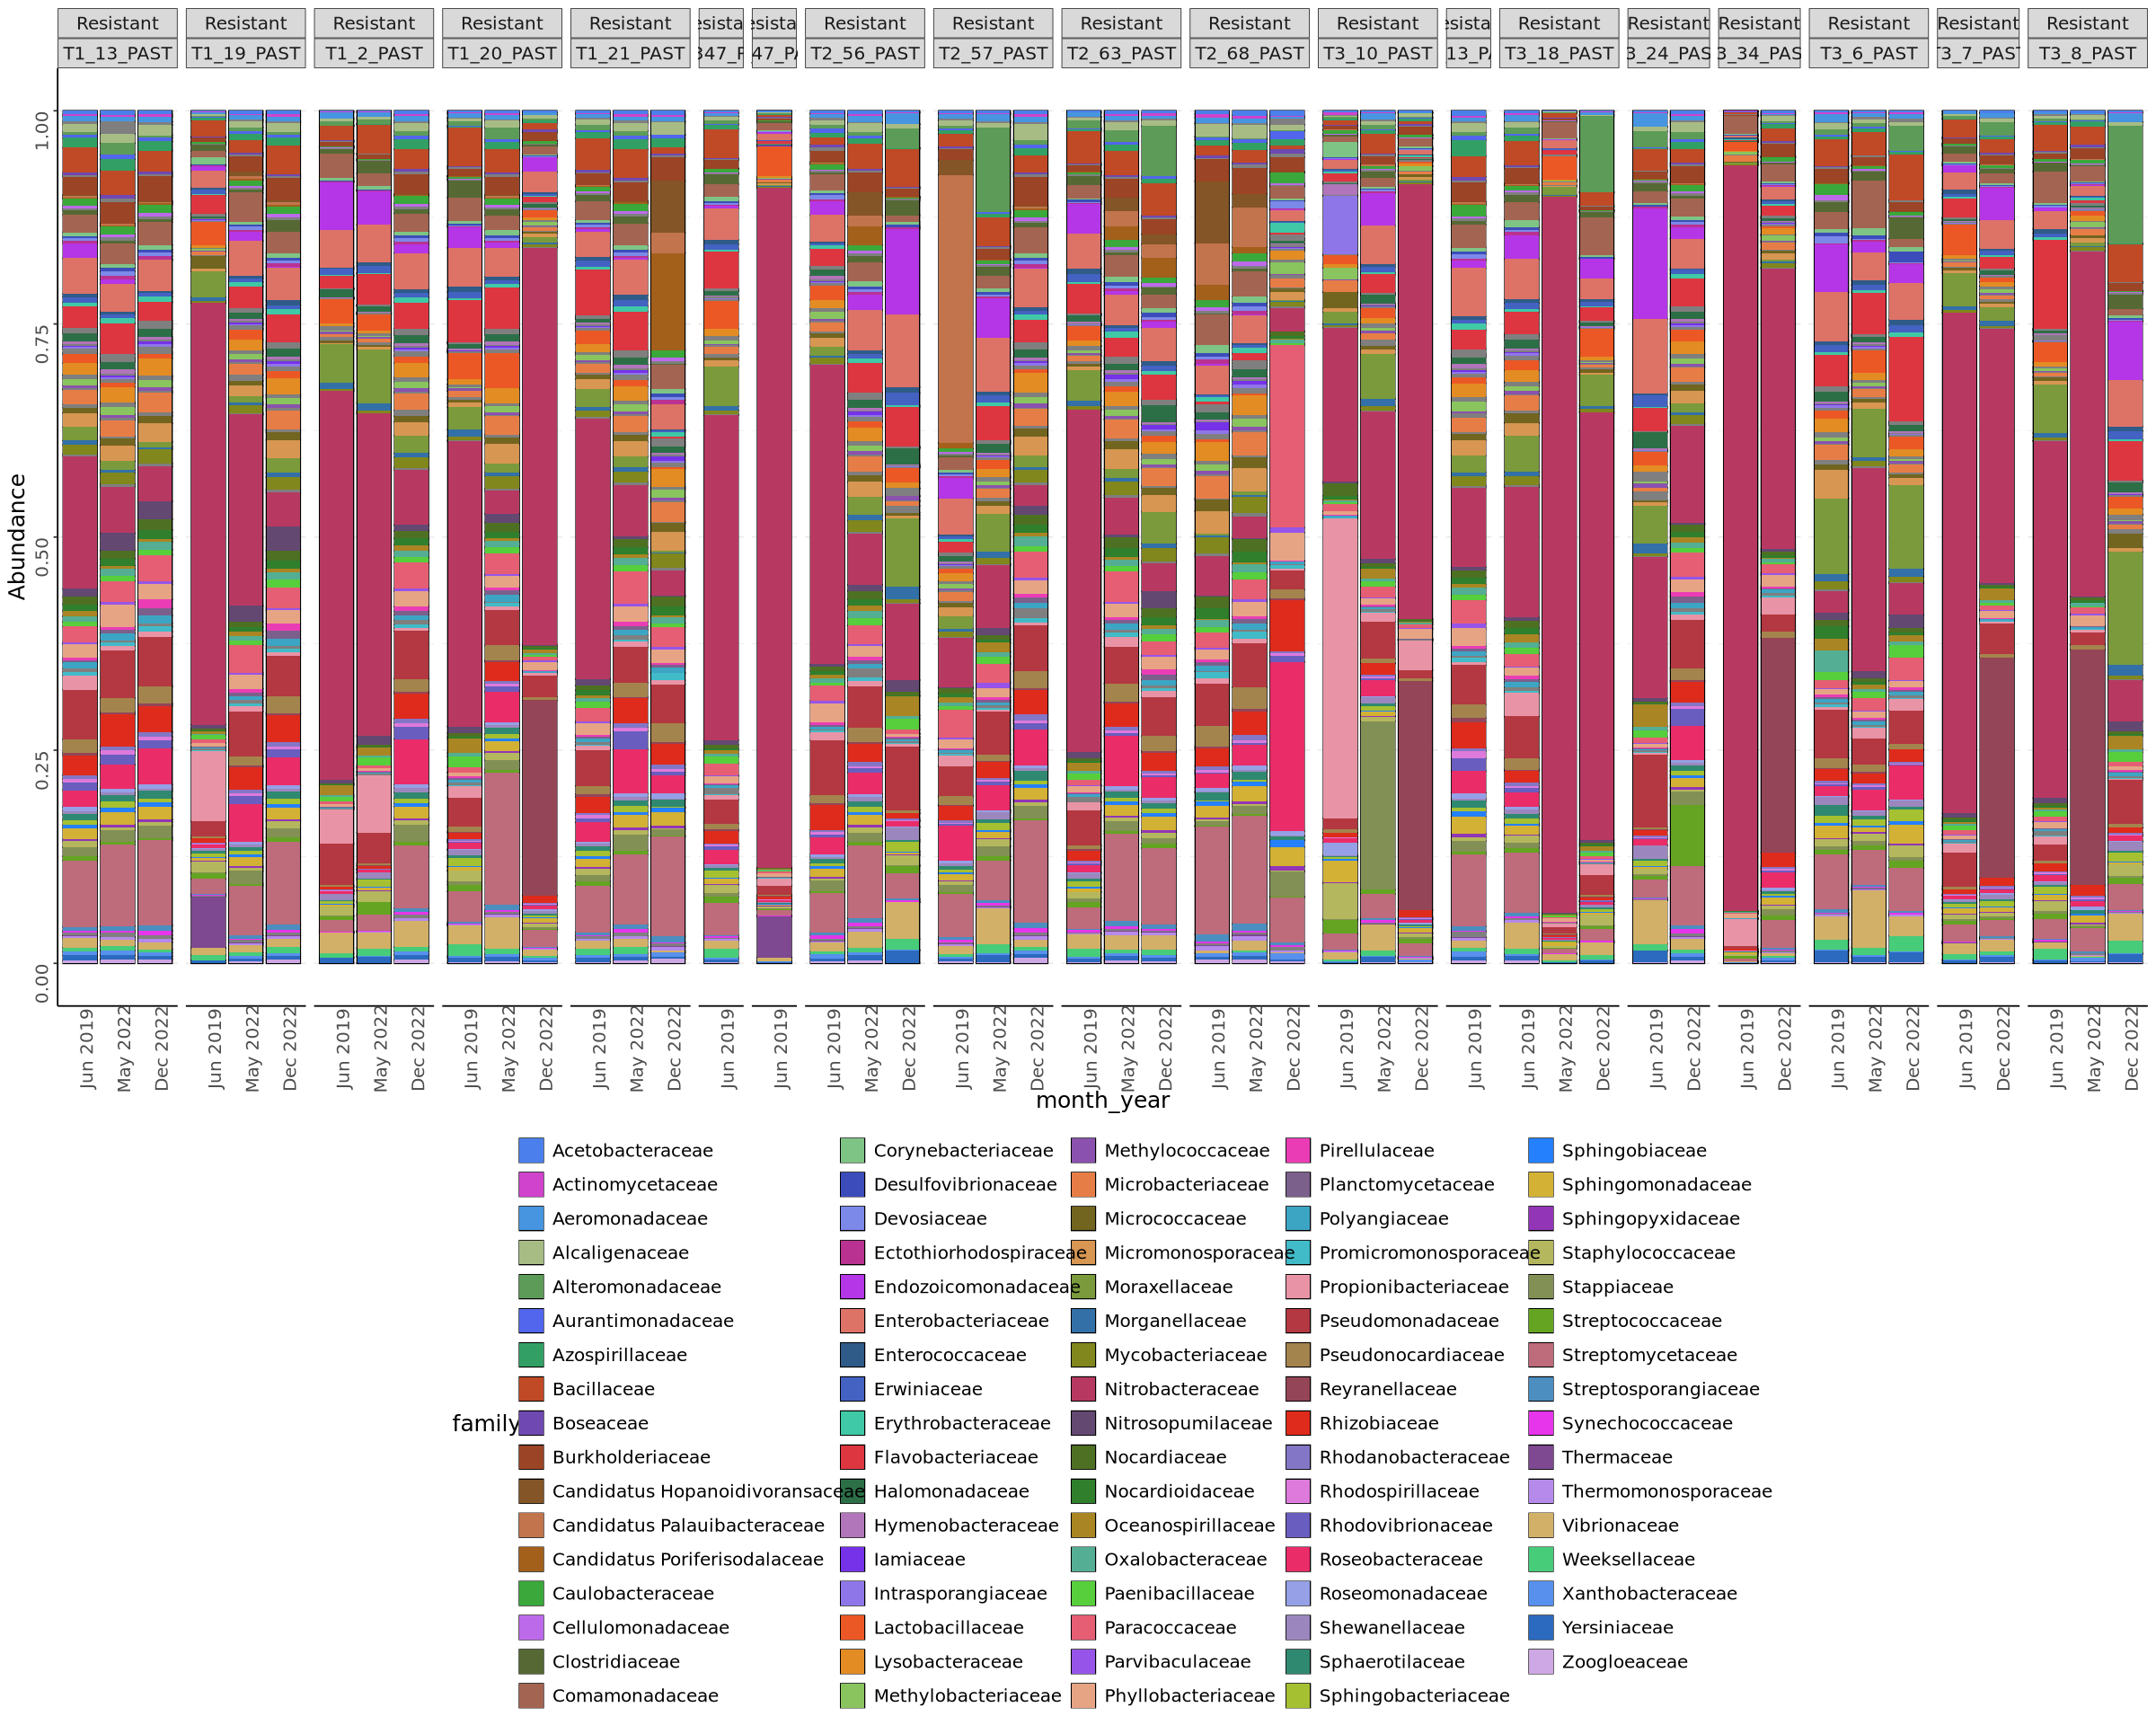

In [116]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PAST_100_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 100 OTUs (family)

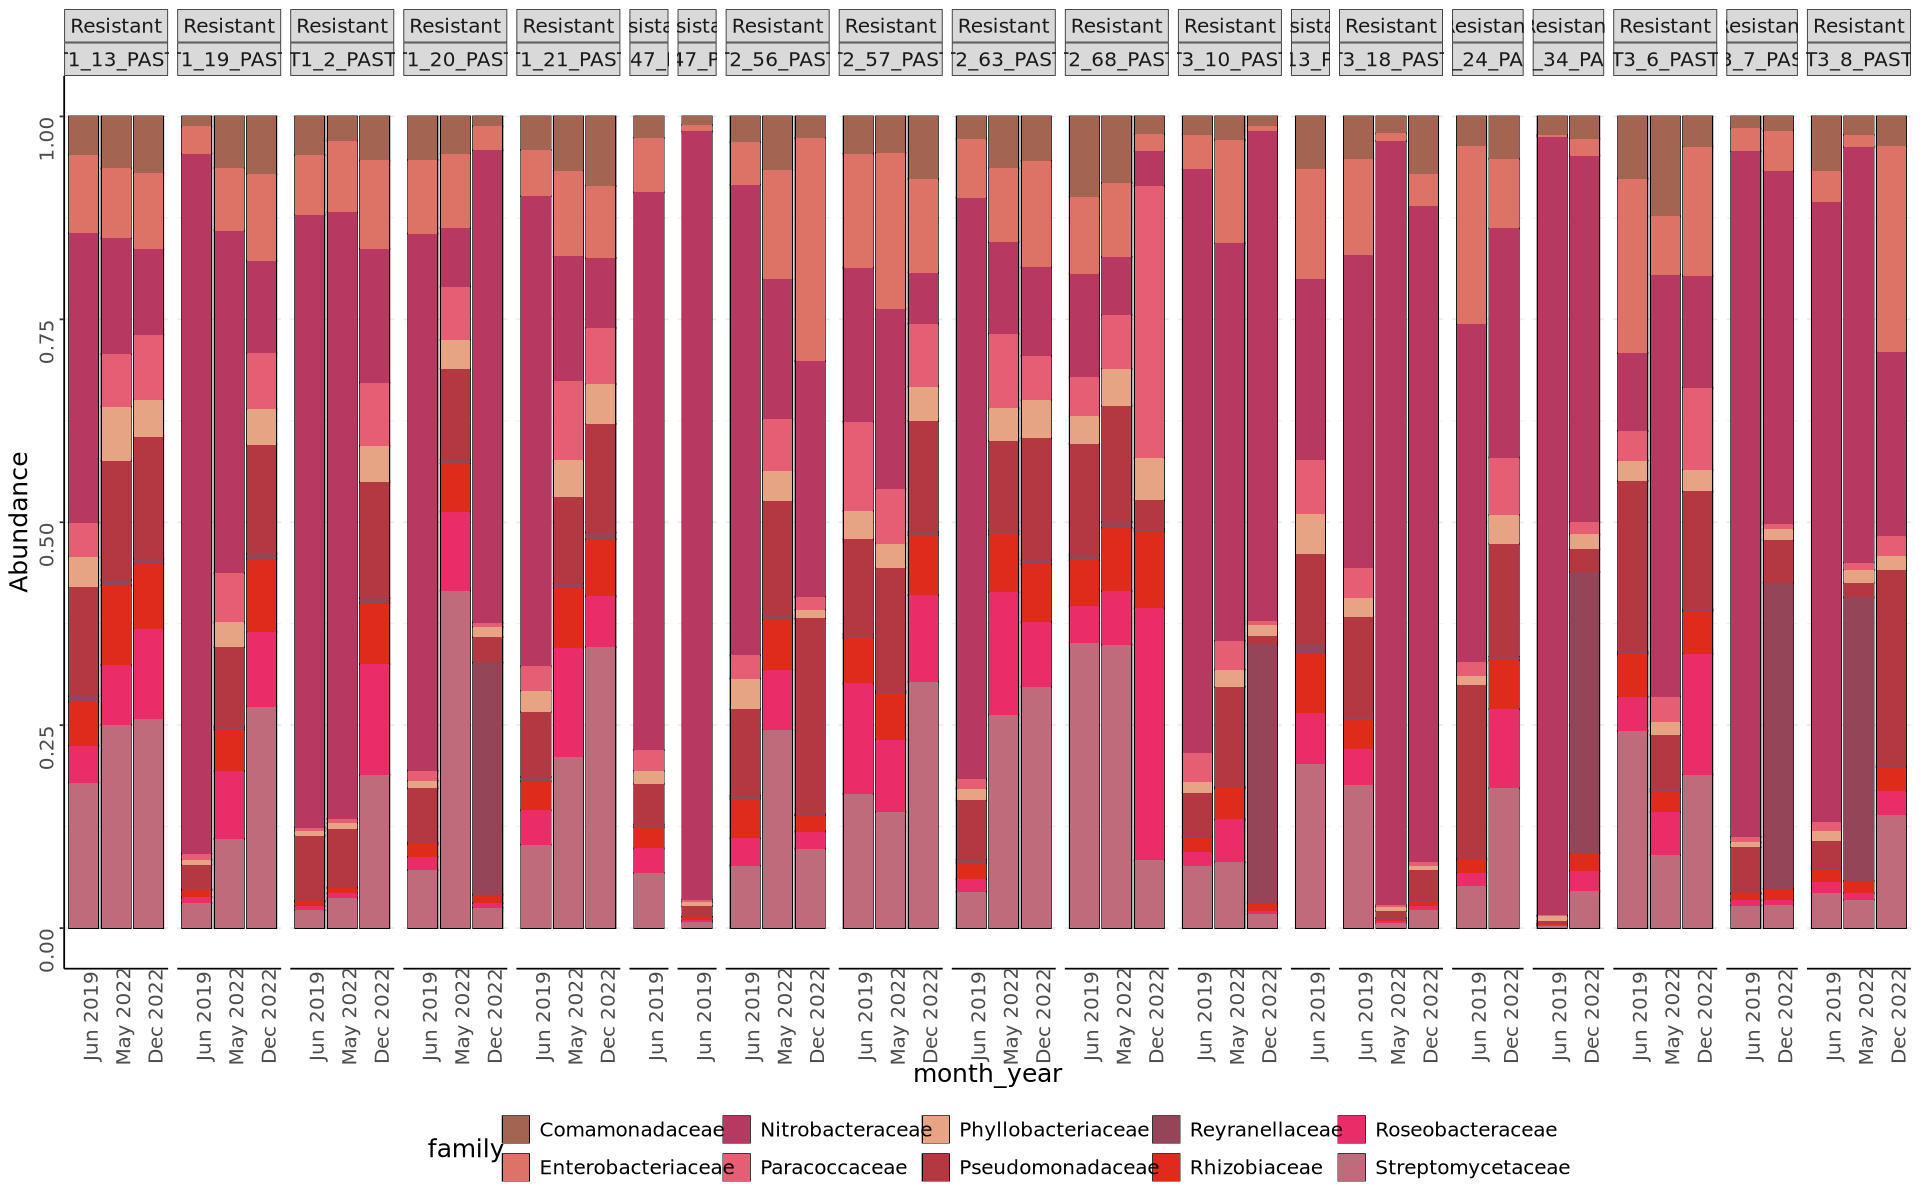

In [117]:
options(repr.plot.height = 10, repr.plot.width = 16)
p<-plot_bar(PAST_10_norm,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# top 10 OTUs (species)

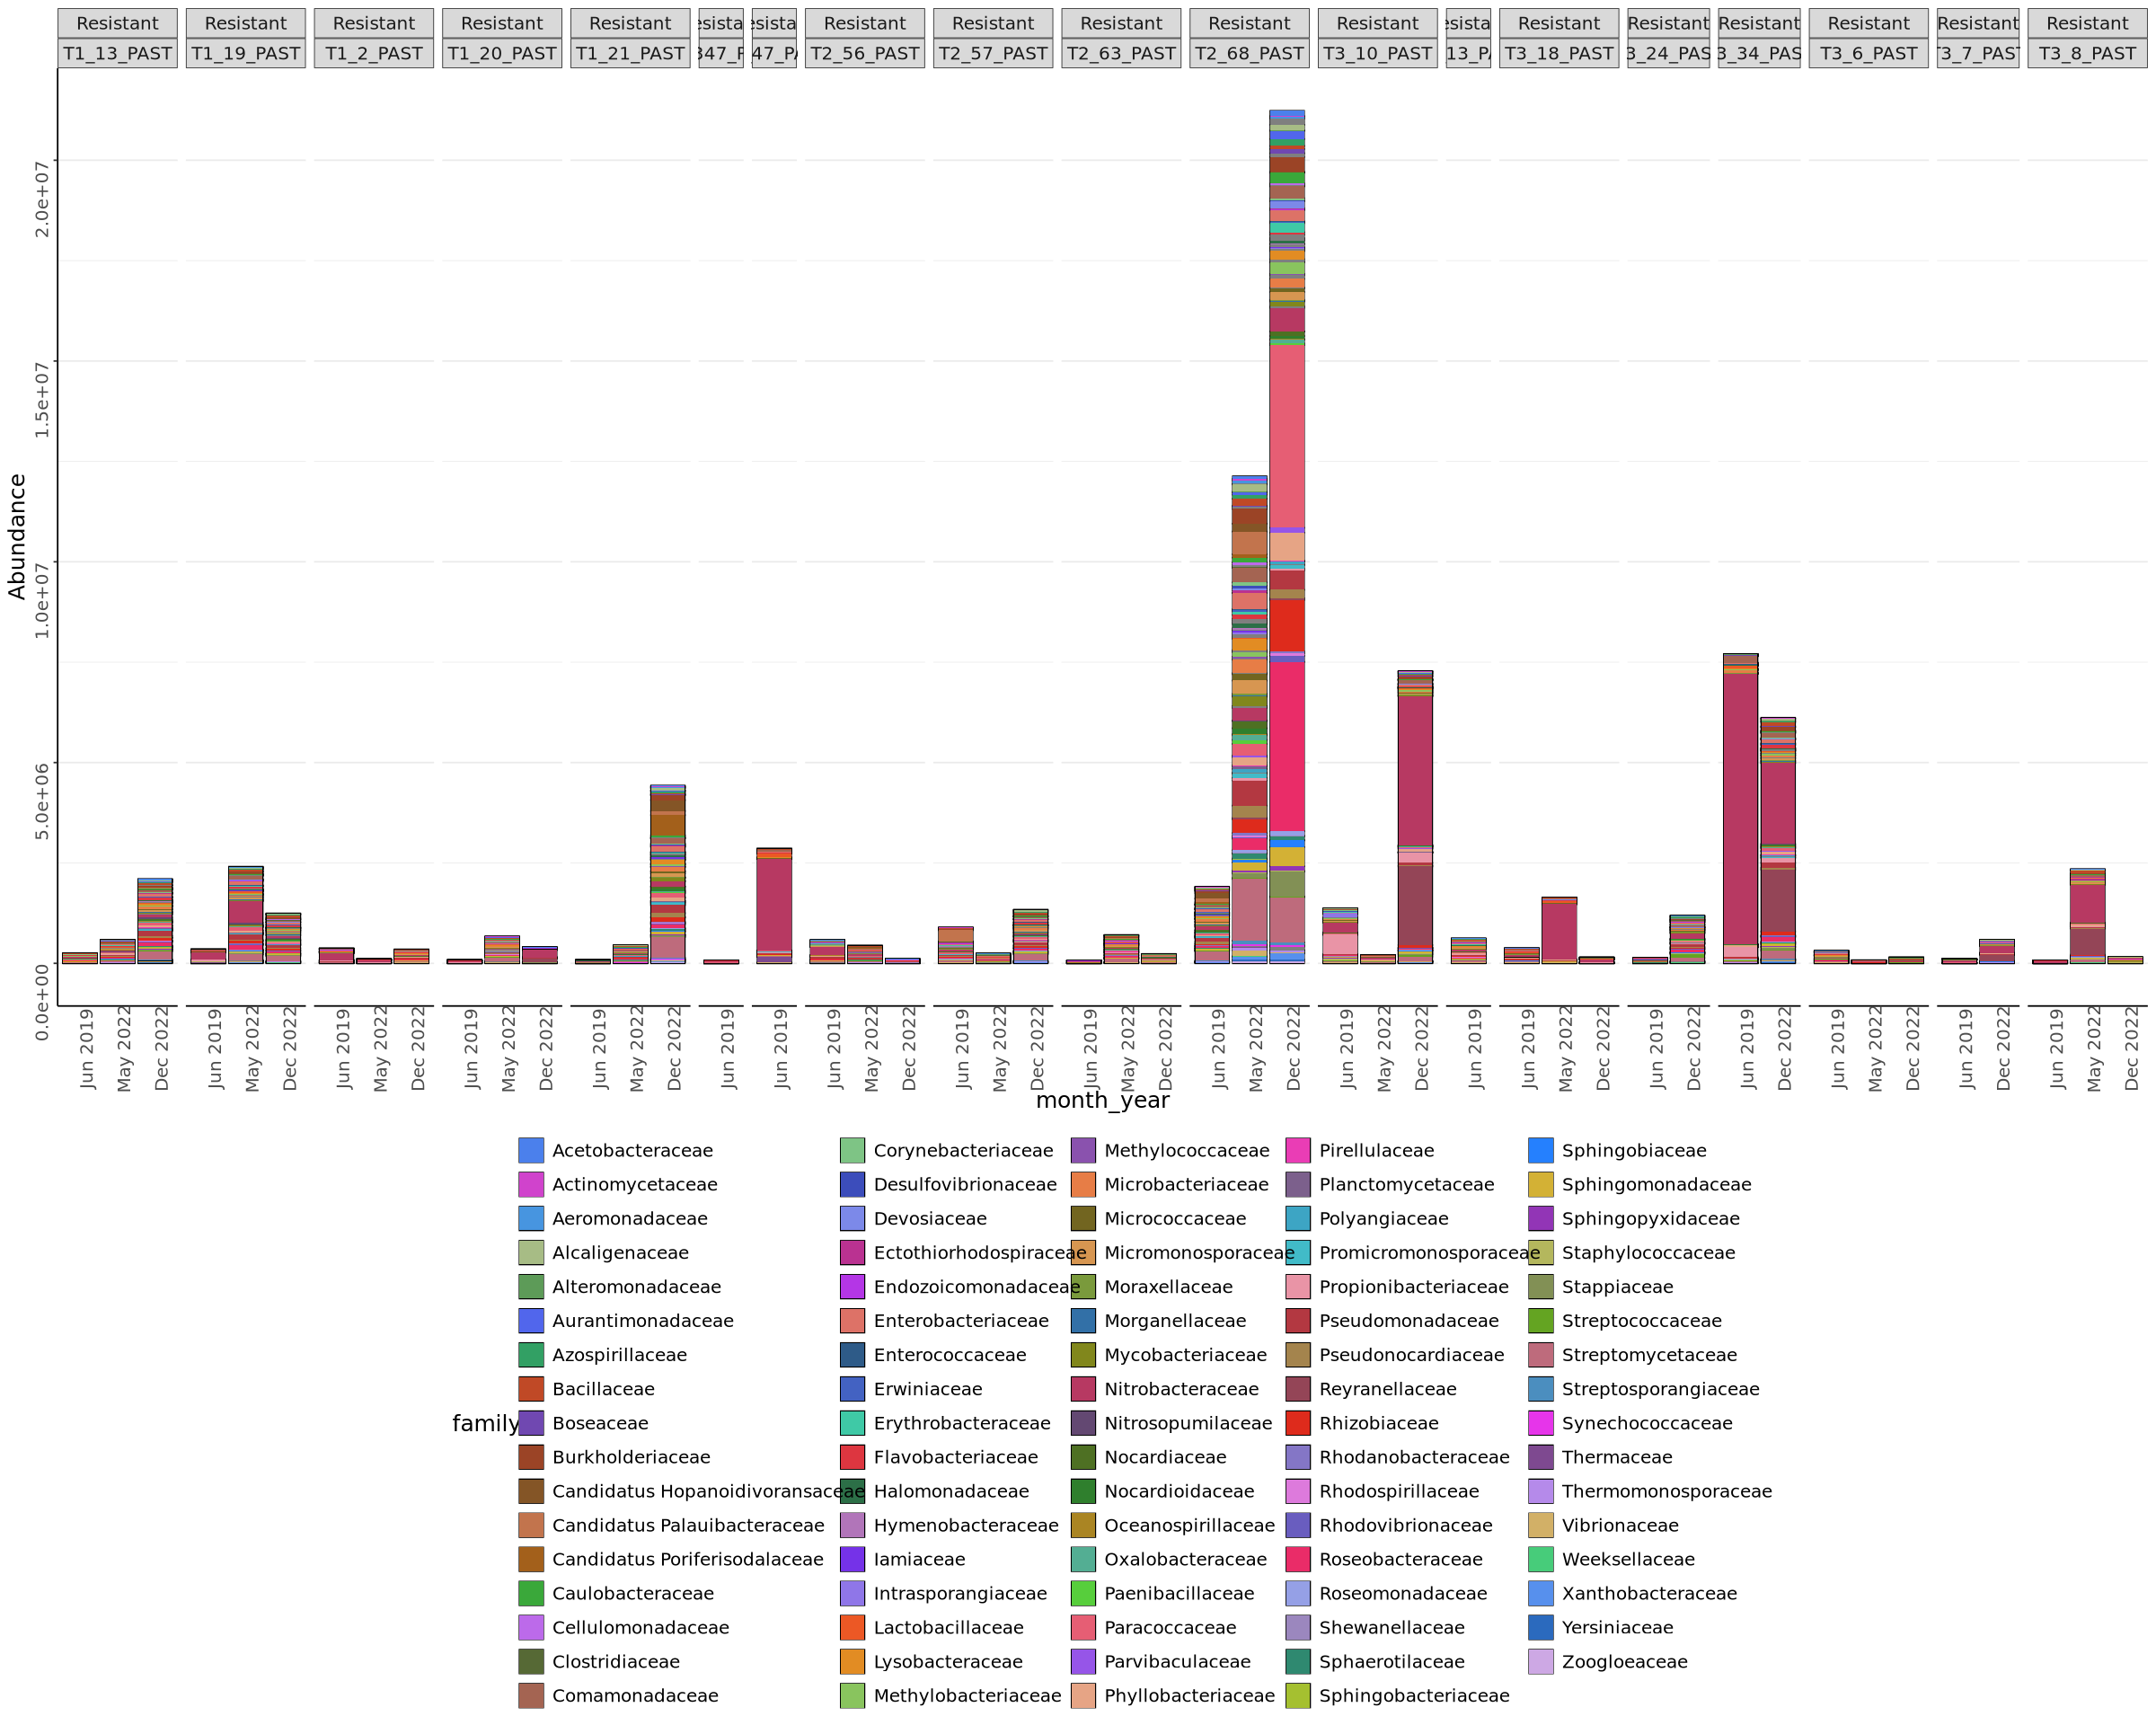

In [118]:
options(repr.plot.height = 16, repr.plot.width = 20)
p<-plot_bar(PAST_100,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 100 OTUs (family)

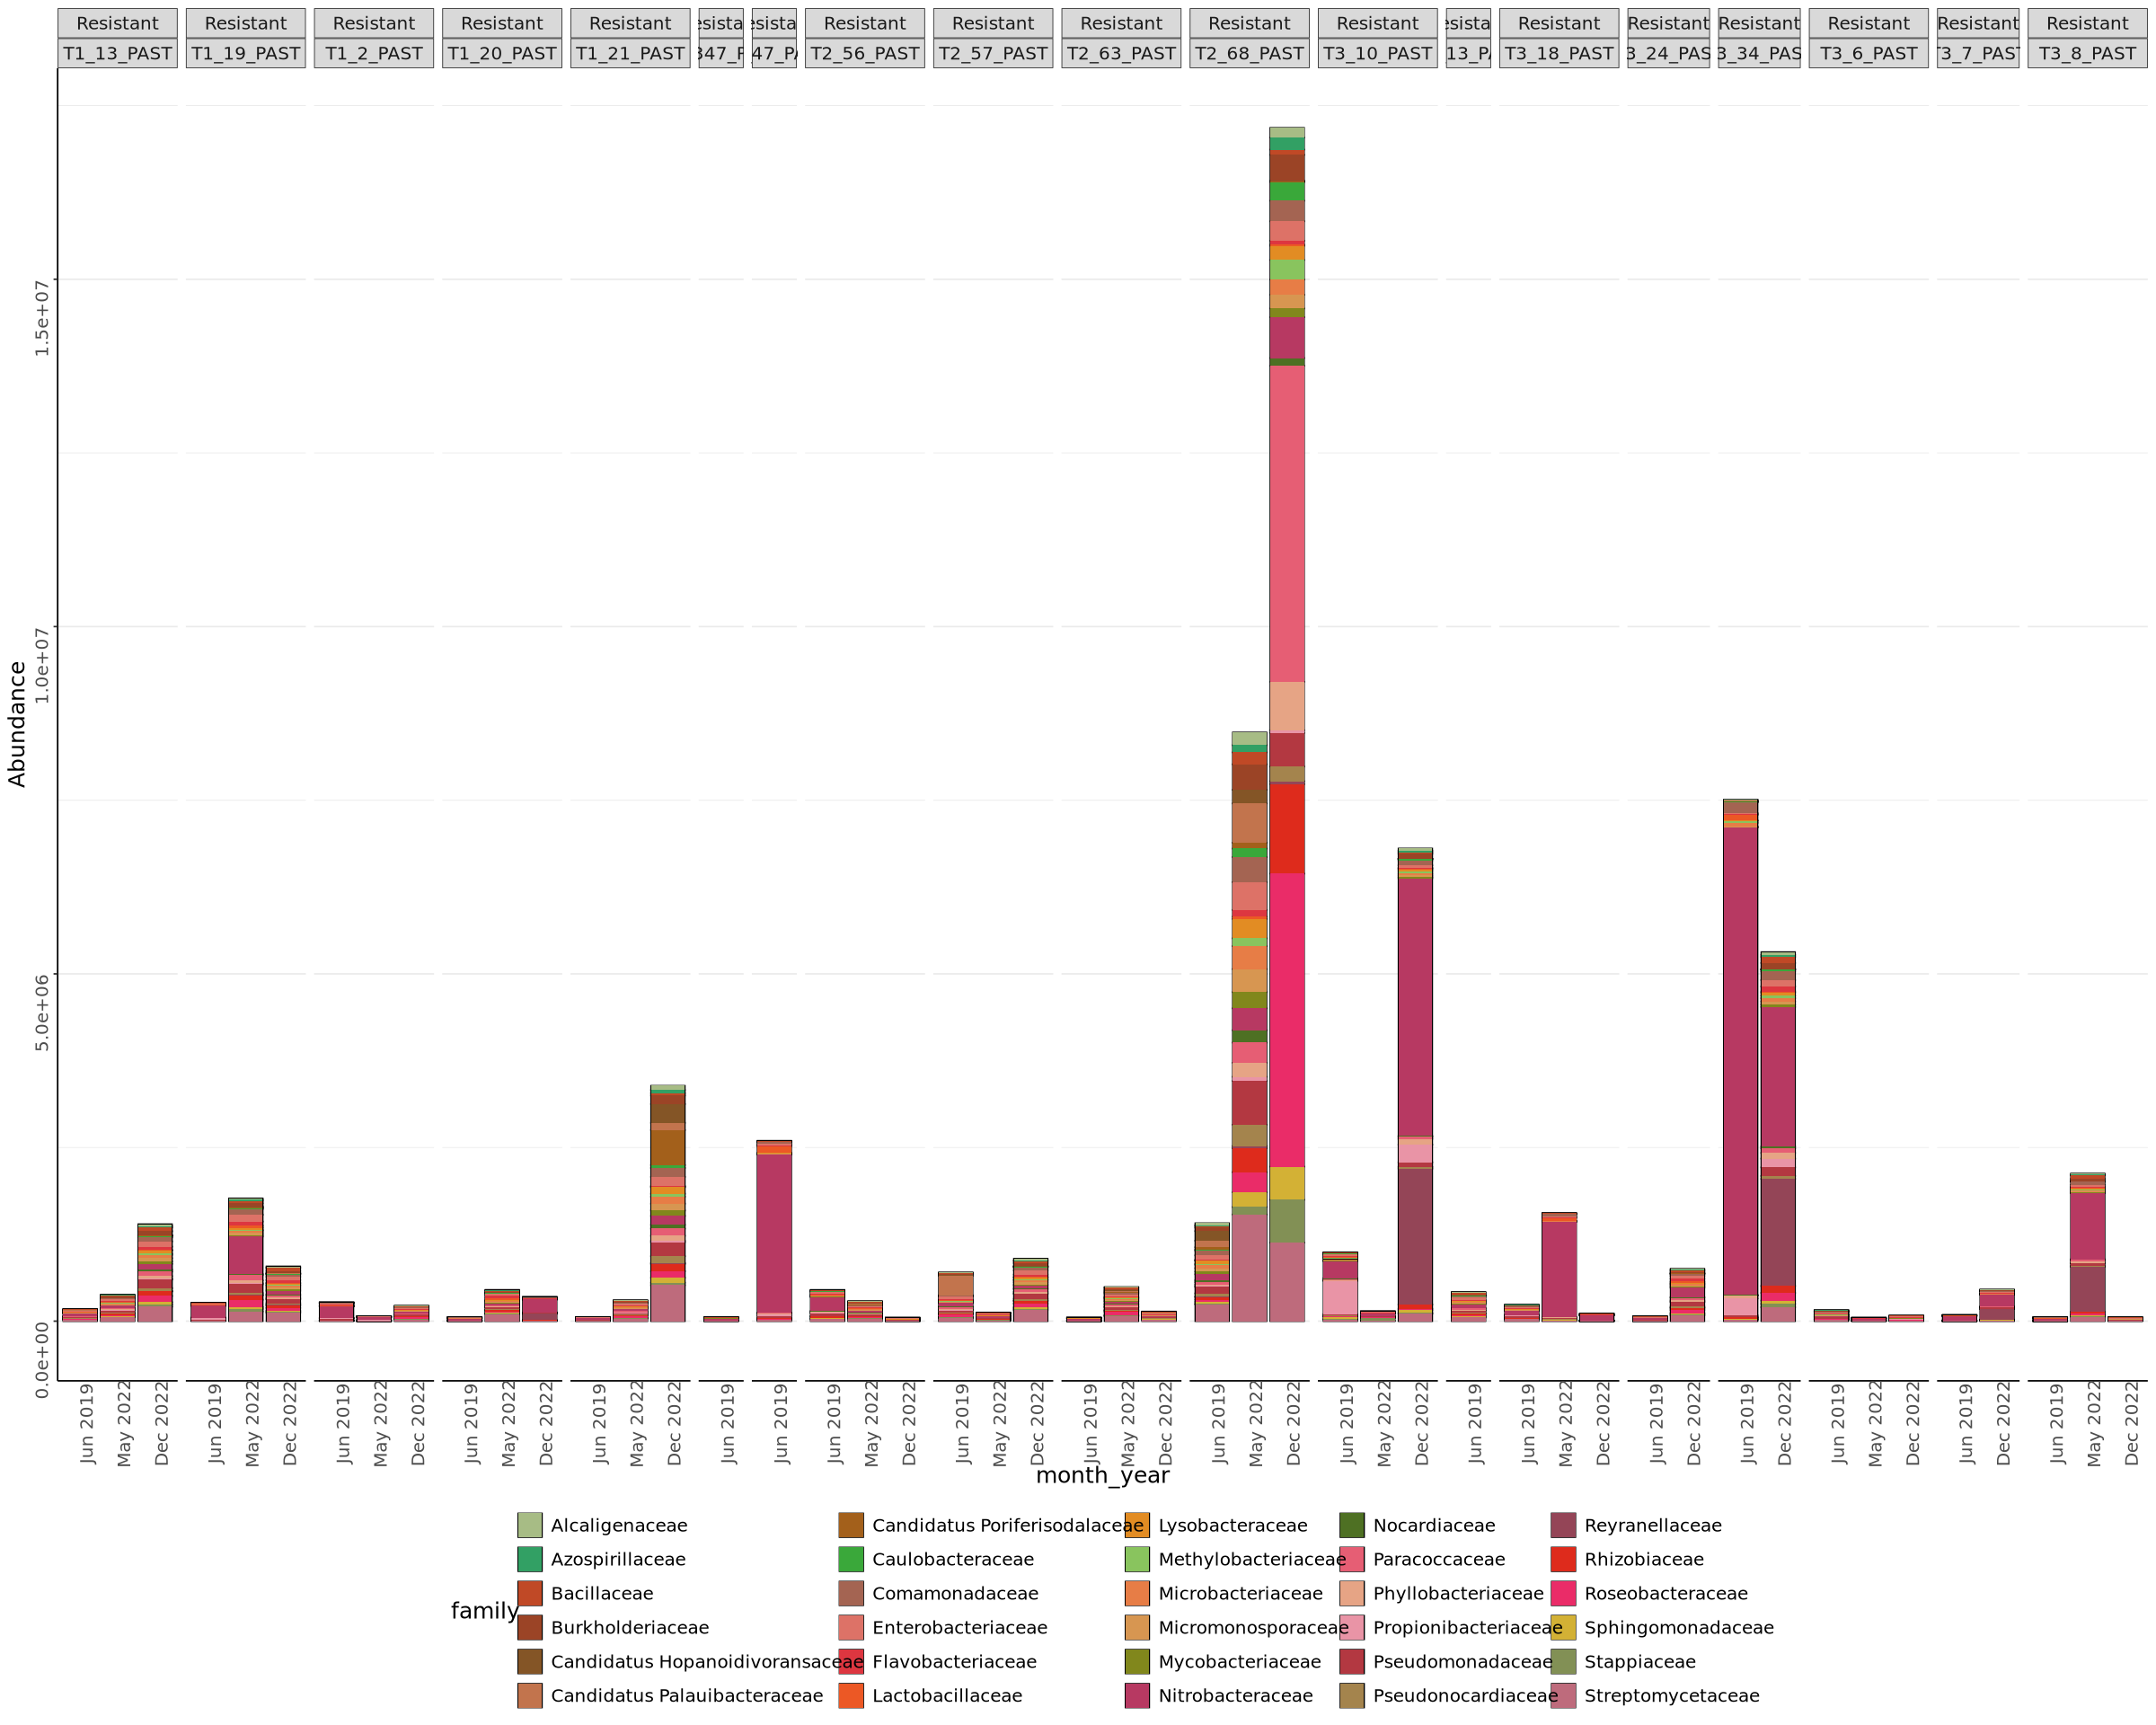

In [119]:
p<-plot_bar(PAST_30,x = "month_year",fill='family')
p+facet_grid(~RS+colony_id, scales="free_x", space = "free_x")+
    geom_bar(aes(x = month_year,fill=family), stat="identity",position="stack")+
    scale_fill_manual(values = g_colors) +
    theme_bw()+
    theme(legend.position="bottom", panel.border = element_blank(), 
              panel.grid.major.x = element_blank(), 
              panel.grid.minor.x = element_blank(),
              axis.ticks.x=element_blank(), axis.line=element_line(color="black"), axis.text=element_text(angle=90),
              text = element_text(size=15))

# abundances - top 30 OTUs (family)